In [ ]:
###Title- Cattle inflammation project
###Analysis includes The analysis includes: 1.DADA2 pipeline; 2.Decontamination using the Decontam and SourceTracker R package; 3.Evaluation of alpha and beta diversity metrics; 4. Microbial Composition


In [3]:
#Calling R in conda environment 
R.version.string

[1] "R version 4.4.2 (2024-10-31)"

In [4]:
#load required libraries
library(dada2); packageVersion("dada2")
library(phyloseq)
library(ggplot2)
library(ShortRead)  
library(dplyr)
library(stats)
library(Biostrings)

Warning message:
“package ‘dada2’ was built under R version 4.4.3”
Loading required package: Rcpp



[1] ‘1.34.0’

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, saveRDS, setdiff,
    table, tapply, union, unique, unsplit, which.max, which.min


Loading required package: BiocParallel

Loading required package: Biostrings

Loading required package: S4Vectors

Loading required package: stats4


Attaching package: ‘S4Vectors’


The following object is masked from ‘package:utils’:

    findMatches


The following objects are masked from ‘package:base’:

    expand.grid, I, unname


Loading required package: IRanges


At

In [ ]:
### 1. Raw read processing using Trimmomatic
# 1.1 Uniforming file names . 1. Extraction Controls (N-CONTROL)
for file in N-CONTROL*.fastq.gz; do
  mv "$file" "${file//N-CONTROL/control-extraction-N-CONTROL}"
done

# Renaming Mock Controls (SynMock)
for file in SynMock*.fastq.gz; do
  mv "$file" "${file//SynMock/mock-synthetic}"
done

# Renaming TE Controls
for file in TE-*.fastq.gz; do
  mv "$file" "${file//TE-/control-te-}"
done

# Renaming ZYMO Mock Controls
for file in ZYMO-*.fastq.gz; do
  mv "$file" "${file//ZYMO-/mock-synthetic-ZYMO-}"
done

In [3]:
### 2. Data filtering using DADA2 
# Path to the folder with your FASTQ files
path <- "/scratch/negishi/ldas/1_5_25/DADA2_inputs"
list.files(path)

[1] "1083-1_S95_L001_R1_paired.fastq.gz"                        
  [2] "1083-1_S95_L001_R2_paired.fastq.gz"                        
  [3] "1083-2_S96_L001_R1_paired.fastq.gz"                        
  [4] "1083-2_S96_L001_R2_paired.fastq.gz"                        
  [5] "1083-3_S97_L001_R1_paired.fastq.gz"                        
  [6] "1083-3_S97_L001_R2_paired.fastq.gz"                        
  [7] "1083-4_S98_L001_R1_paired.fastq.gz"                        
  [8] "1083-4_S98_L001_R2_paired.fastq.gz"                        
  [9] "1083-PBS_S99_L001_R1_paired.fastq.gz"                      
 [10] "1083-PBS_S99_L001_R2_paired.fastq.gz"                      
 [11] "1165D1LM_S23_L001_R1_paired.fastq.gz"                      
 [12] "1165D1LM_S23_L001_R2_paired.fastq.gz"                      
 [13] "1165D3LM_S118_L001_R1_paired.fastq.gz"                     
 [14] "1165D3LM_S118_L001_R2_paired.fastq.gz"                     
 [15] "1179-PBS_S91_L001_R1_paired.fastq.gz"                      
 [16] "1179-PBS_S91_L001_R2_paired.fastq.gz"                      
 [17] "1179D1LM_S10_L001_R1_paired.fastq.gz"                      
 [18] "1179D1LM_S10_L001_R2_paired.fastq.gz"                      
 [19] "1179D3LM_S105_L001_R1_paired.fastq.gz"                     
 [20] "1179D3LM_S105_L001_R2_paired.fastq.gz"                     
 [21] "1217-PBS_S92_L001_R1_paired.fastq.gz"                      
 [22] "1217-PBS_S92_L001_R2_paired.fastq.gz"                      
 [23] "1217D1LM_S24_L001_R1_paired.fastq.gz"                      
 [24] "1217D1LM_S24_L001_R2_paired.fastq.gz"                      
 [25] "1217D3LM_S119_L001_R1_paired.fastq.gz"                     
 [26] "1217D3LM_S119_L001_R2_paired.fastq.gz"                     
 [27] "1218D1LM_S12_L001_R1_paired.fastq.gz"                      
 [28] "1218D1LM_S12_L001_R2_paired.fastq.gz"                      
 [29] "1218D3LM_S107_L001_R1_paired.fastq.gz"                     
 [30] "1218D3LM_S107_L001_R2_paired.fastq.gz"                     
 [31] "1226D1LM_S11_L001_R1_paired.fastq.gz"                      
 [32] "1226D1LM_S11_L001_R2_paired.fastq.gz"                      
 [33] "1226D3LM_S106_L001_R1_paired.fastq.gz"                     
 [34] "1226D3LM_S106_L001_R2_paired.fastq.gz"                     
 [35] "1228D1LM_S16_L001_R1_paired.fastq.gz"                      
 [36] "1228D1LM_S16_L001_R2_paired.fastq.gz"                      
 [37] "1228D3LM_S111_L001_R1_paired.fastq.gz"                     
 [38] "1228D3LM_S111_L001_R2_paired.fastq.gz"                     
 [39] "1234D1LM_S26_L001_R1_paired.fastq.gz"                      
 [40] "1234D1LM_S26_L001_R2_paired.fastq.gz"                      
 [41] "1234D3LM_S121_L001_R1_paired.fastq.gz"                     
 [42] "1234D3LM_S121_L001_R2_paired.fastq.gz"                     
 [43] "1261D1LM_S5_L001_R1_paired.fastq.gz"                       
 [44] "1261D1LM_S5_L001_R2_paired.fastq.gz"                       
 [45] "1261D3LM_S100_L001_R1_paired.fastq.gz"                     
 [46] "1261D3LM_S100_L001_R2_paired.fastq.gz"                     
 [47] "1287D1LM_S33_L001_R1_paired.fastq.gz"                      
 [48] "1287D1LM_S33_L001_R2_paired.fastq.gz"                      
 [49] "1287D3LM_S128_L001_R1_paired.fastq.gz"                     
 [50] "1287D3LM_S128_L001_R2_paired.fastq.gz"                     
 [51] "1308D1LM_S47_L001_R1_paired.fastq.gz"                      
 [52] "1308D1LM_S47_L001_R2_paired.fastq.gz"                      
 [53] "1308D3LM_S142_L001_R1_paired.fastq.gz"                     
 [54] "1308D3LM_S142_L001_R2_paired.fastq.gz"                     
 [55] "1314D1LM_S30_L001_R1_paired.fastq.gz"                      
 [56] "1314D1LM_S30_L001_R2_paired.fastq.gz"                      
 [57] "1314D3LM_S125_L001_R1_paired.fastq.gz"                     
 [58] "1314D3LM_S125_L001_R2_paired.fastq.gz"                     
 [59] "1320D1LM_S31_L001_R1_paired.fastq.gz"                      
 [60] "1320D1LM_S31_L001_R2_paired.fastq.gz"     

In [5]:
# To load the files
output_dir <- "/scratch/negishi/ldas/1_5_25/DADA2_outputs"

# Load .rds files
dadaFs <- readRDS(file.path(output_dir, "dadaFs.rds"))
dadaRs <- readRDS(file.path(output_dir, "dadaRs.rds"))
errF <- readRDS(file.path(output_dir, "errF.rds"))
errR <- readRDS(file.path(output_dir, "errR.rds"))
filter_trim_summary <- readRDS(file.path(output_dir, "filter_trim_summary.rds"))
filtFs <- readRDS(file.path(output_dir, "filtFs.rds"))
filtRs <- readRDS(file.path(output_dir, "filtRs.rds"))
length_table <- readRDS(file.path(output_dir, "length_table.rds"))
mergers <- readRDS(file.path(output_dir, "mergers.rds"))
phyloseq <- readRDS(file.path(output_dir, "phyloseq.rds"))
phyloseq_true_samples <- readRDS(file.path(output_dir, "phyloseq_true_samples.rds"))
physeq_controls <- readRDS(file.path(output_dir, "physeq_controls.rds"))
physeq <- readRDS(file.path(output_dir, "physeq.rds"))
physeq_WO_mock <- readRDS(file.path(output_dir, "phyloseq_WO_mock.rds"))
ps.mock <- readRDS(file.path(output_dir, "ps.mock.rds"))
seqtab <- readRDS(file.path(output_dir, "seqtab.rds"))
seqtab_nochim <- readRDS(file.path(output_dir, "seqtab_nochim.rds"))
seqtab_nochim_dim <- readRDS(file.path(output_dir, "seqtab_nochim_dim.rds"))
seqtab_nochim_ratio <- readRDS(file.path(output_dir, "seqtab_nochim_ratio.rds"))
taxa_assignments <- readRDS(file.path(output_dir, "taxa_assignments.rds"))
taxa_species <- readRDS(file.path(output_dir, "taxa_species.rds"))
taxa_wo_chloroplast_mitochondria <- readRDS(file.path(output_dir, "taxa_wo_chloroplast_mitochondria.rds"))

# Load .csv file
track_reads_summary <- read.csv(file.path(output_dir, "track_reads_summary.csv"))

In [27]:
# Forward and reverse fastq filenames
fnFs <- sort(list.files(path, pattern = "_R1.paired.fastq.gz", full.names = TRUE))
fnRs <- sort(list.files(path, pattern = "_R2.paired.fastq.gz", full.names = TRUE))

In [28]:
# Extract sample names
sample.names <- sapply(strsplit(basename(fnFs), "_"), `[`, 1)

In [29]:
# Place filtered files in filtered/ subdirectory
filtFs <- file.path(path, "filtered", paste0(sample.names, "_F_filt.fastq.gz"))
filtRs <- file.path(path, "filtered", paste0(sample.names, "_R_filt.fastq.gz"))
names(filtFs) <- sample.names
names(filtRs) <- sample.names

Warning message:
“Removed 653 rows containing missing values or values outside the scale range
(`geom_tile()`).”
Warning message:
“Removed 815 rows containing missing values or values outside the scale range
(`geom_tile()`).”


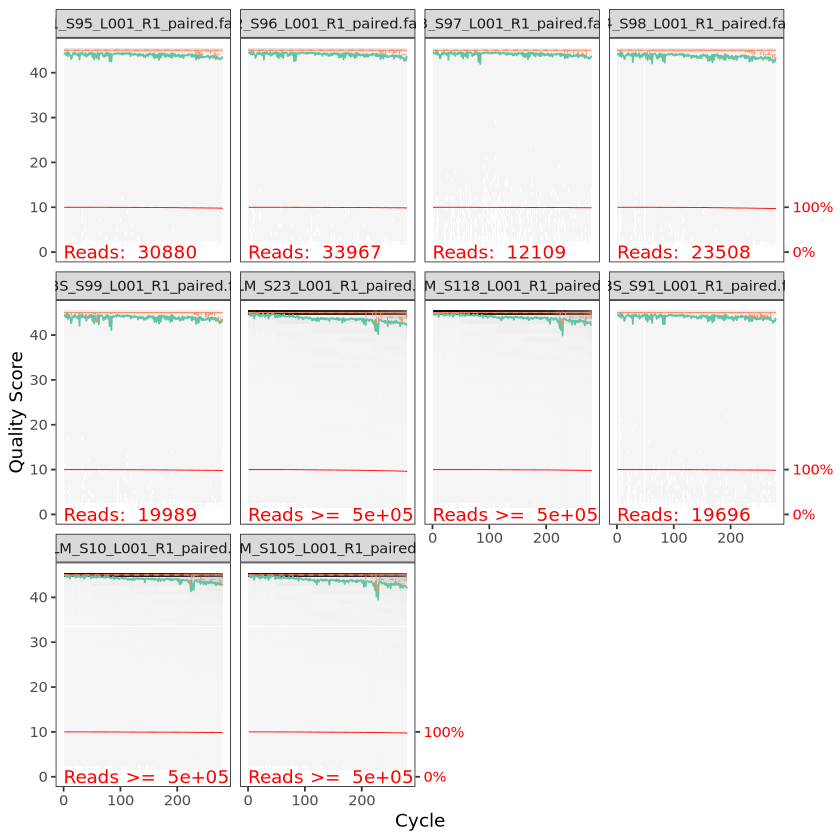

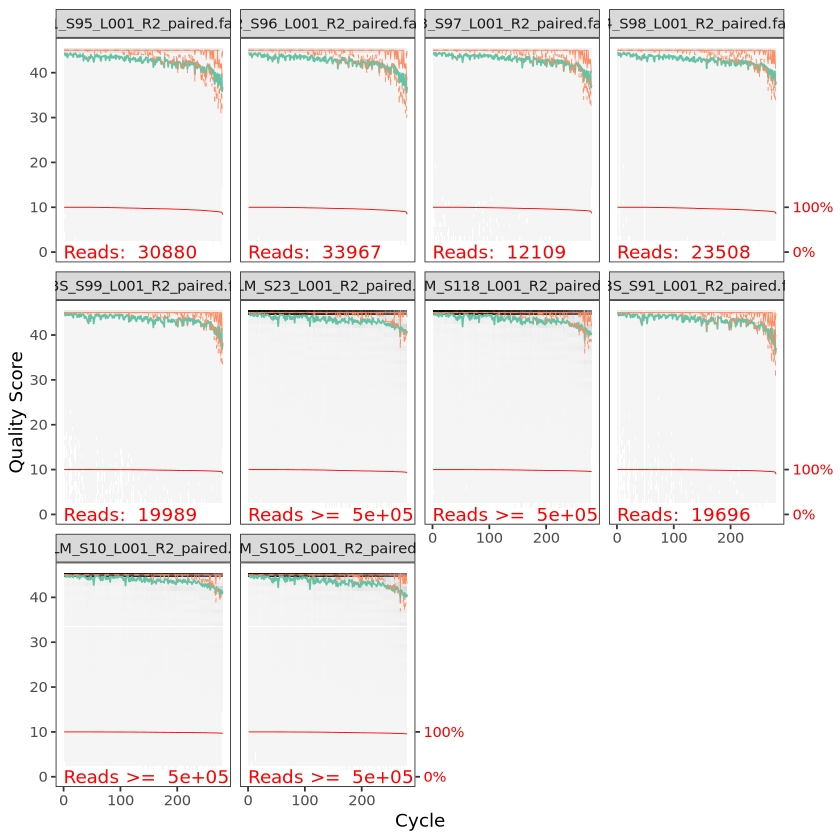

In [9]:
# Check quality of the reads
plotQualityProfile(fnFs[1:10])
plotQualityProfile(fnRs[1:10])

In [30]:
# Filter and trim the reads
out <- filterAndTrim(fnFs, filtFs, fnRs, filtRs, trimLeft=c(20,17), truncLen=c(240,220),
              maxN=0, maxEE=c(3,4), truncQ=2, rm.phix=TRUE,
              compress=TRUE, multithread=TRUE)
head(out)

,reads.in,reads.out
1083-1_S95_L001_R1_paired.fastq.gz,30880,25702
1083-2_S96_L001_R1_paired.fastq.gz,33967,28345
1083-3_S97_L001_R1_paired.fastq.gz,12109,10178
1083-4_S98_L001_R1_paired.fastq.gz,23508,19502
1083-PBS_S99_L001_R1_paired.fastq.gz,19989,17178
1165D1LM_S23_L001_R1_paired.fastq.gz,609025,513044


In [282]:
# Create output directory
output_dir <- "/scratch/negishi/ldas/1_5_25/DADA2_outputs"
if (!dir.exists(output_dir)) {
  dir.create(output_dir, recursive = TRUE)
}

In [32]:
saveRDS(out, file.path(output_dir, "filter_trim_summary.rds"))
saveRDS(filtFs, file.path(output_dir, "filtFs.rds"))
saveRDS(filtRs, file.path(output_dir, "filtRs.rds"))

In [33]:
# Learn error rates for forward and reverse reads
errF <- learnErrors(filtFs, multithread=TRUE)
errR <- learnErrors(filtRs, multithread=TRUE)

135068780 total bases in 613949 reads from 6 samples will be used for learning the error rates.
124631647 total bases in 613949 reads from 6 samples will be used for learning the error rates.


In [34]:
saveRDS(errF,   file.path(output_dir, "errF.rds"))
saveRDS(errR,   file.path(output_dir, "errR.rds"))

In [35]:
# Denoise forward reads
dadaFs <- dada(filtFs, err=errF, multithread=TRUE)

Sample 1 - 25702 reads in 3302 unique sequences.
Sample 2 - 28345 reads in 3484 unique sequences.
Sample 3 - 10178 reads in 1647 unique sequences.
Sample 4 - 19502 reads in 2594 unique sequences.
Sample 5 - 17178 reads in 2016 unique sequences.
Sample 6 - 513044 reads in 90675 unique sequences.
Sample 7 - 580336 reads in 100365 unique sequences.
Sample 8 - 17034 reads in 1816 unique sequences.
Sample 9 - 491328 reads in 75283 unique sequences.
Sample 10 - 562995 reads in 86809 unique sequences.
Sample 11 - 14495 reads in 1736 unique sequences.
Sample 12 - 491971 reads in 57200 unique sequences.
Sample 13 - 445873 reads in 63950 unique sequences.
Sample 14 - 534166 reads in 91146 unique sequences.
Sample 15 - 439425 reads in 89976 unique sequences.
Sample 16 - 485071 reads in 78707 unique sequences.
Sample 17 - 504308 reads in 93880 unique sequences.
Sample 18 - 425732 reads in 77193 unique sequences.
Sample 19 - 465407 reads in 79216 unique sequences.
Sample 20 - 515886 reads in 76341 

Warning message in rval[, 1:ncol(tt)] + tt:
“NAs produced by integer overflow”
Warning message in rval[, 1:ncol(tt)] + tt:
“NAs produced by integer overflow”
Warning message in rval[, 1:ncol(tt)] + tt:
“NAs produced by integer overflow”
Warning message in rval[, 1:ncol(tt)] + tt:
“NAs produced by integer overflow”


In [ ]:
# Denoise reverse reads
dadaRs <- dada(filtRs, err=errR, multithread=TRUE)

In [ ]:
saveRDS(dadaFs, file.path(output_dir, "dadaFs.rds"))
saveRDS(dadaRs, file.path(output_dir, "dadaRs.rds"))

In [ ]:
#Save intermediate files in output_dir
saveRDS(out, file.path(output_dir, "filter_trim_summary.rds"))
saveRDS(filtFs, file.path(output_dir, "filtFs.rds"))
saveRDS(filtRs, file.path(output_dir, "filtRs.rds"))
saveRDS(errF,   file.path(output_dir, "errF.rds"))
saveRDS(errR,   file.path(output_dir, "errR.rds"))
saveRDS(dadaFs, file.path(output_dir, "dadaFs.rds"))
saveRDS(dadaRs, file.path(output_dir, "dadaRs.rds"))

In [48]:
# Merge paired reads
mergers <- mergePairs(dadaFs, filtFs, dadaRs, filtRs, verbose=TRUE)
head(mergers[[1]])
length(mergers)
saveRDS(mergers, file.path(output_dir, "mergers.rds"))

23758 paired-reads (in 403 unique pairings) successfully merged out of 25340 (in 436 pairings) input.

26335 paired-reads (in 378 unique pairings) successfully merged out of 27893 (in 416 pairings) input.

9401 paired-reads (in 263 unique pairings) successfully merged out of 9959 (in 293 pairings) input.

18314 paired-reads (in 289 unique pairings) successfully merged out of 19269 (in 313 pairings) input.

16888 paired-reads (in 209 unique pairings) successfully merged out of 17101 (in 221 pairings) input.

437232 paired-reads (in 6454 unique pairings) successfully merged out of 498452 (in 35658 pairings) input.

491693 paired-reads (in 7479 unique pairings) successfully merged out of 564076 (in 43107 pairings) input.

16941 paired-reads (in 195 unique pairings) successfully merged out of 16990 (in 200 pairings) input.

434622 paired-reads (in 5454 unique pairings) successfully merged out of 478948 (in 28282 pairings) input.

487580 paired-reads (in 6692 unique pairings) successfully m

,sequence,abundance,forward,reverse,nmatch,nmismatch,nindel,prefer,accept
,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<lgl>
1,CAAGGACAGCTAGACTCAGGGAAAACACGGCCTCTGGAGCCCACCTGCCAGAGAATCTACGTTGGCATGAGCCAGGCTCAGCCCCTTGGAGCTCAAGCTGTGTCAGTCTGTCTCCATCCACAGTTGTCTCCTAGTGGAAGATTAAACTGGCTTATTTGAGAACAGCTGGGTATACCGGAGGTGGTCATCTCACAAGAGGAGTGTGTAAGGTTTTACCTCGATTAGAAACCCT,665,1,1,191,0,0,2,TRUE
2,TTATCCGGAATGATTGGGCGTAAAGCGTCTGTAGGTGGCTTTTCAAGTCCGCCGTCAAATCCCAGGGCTCAACCCTGGACAGGCGGTGGAAACTACCAAGCTGGAGTACGGTAGGGGCAGAGGGAATTTCCGGTGGAGCGGTGAAATGCATTGAGATCGGAAAGAACACCAACGGCGAAAGCACTCTGCTGGGCCGACACTGACACTGAGAGACGAAAGC,648,2,2,203,0,0,1,TRUE
3,CAAGGACAGCTAGACTCAGGGAAAACACGGCCTCTGGAGCCCACCTGCCAGAGAATCTACGTTGGCATGAGCCAGGCTCAGCCCCTTGGAGCTCAAGCTGTGTCAGTCTGTCTCCATCCACAGTTGTCTCCTAGTGGAAGATTAAACTGGCTTATTTGAGAACAGCTGGGTATACCGGAGGTGGTCATCTCACAAGAGGAGTGTGTAAGGTTTTACCTCGATTAGAAACCCG,521,3,1,191,0,0,2,TRUE
4,TCCACCCCAGAAGGCAAGCCTGAACCTCAATTCCCTGTCAGTGAAATAGGCGACCAATACCCTCTTTGCAGGATTGTGAAAAGTAAACATGAGGCTCGGCACAGGAGTGACTGGAAGTGAATTTGCTTCTTGGAAGCTCAAAGTAGTACATTTCCCATTATTACTGGTGCTGAGTTTTGATATGCCAAGAGCTCCAGCAAGCCAACTAGACCTGGGAGGA,473,4,3,203,0,0,1,TRUE
5,CAAGGACAGCTAGACTCAGGGAAAACACGGCCTCTGGAGCCCACCTGCCAGAGAATCTACGTTGGCATGAGCCAGGCTCAGCCCCTTGGAGCTCAAGCTGTGTCAGTCTGTCTCCATCCACAGTTGTCTCCTAGTGGAAGATTAAACTGGCTTATTTGAGAACAGCTGGGTATACCGGAGGTGGTCATCTCACAAGAGGAGTGTGTAAGGTTTTACCTCGATTAGAAACCCC,435,5,1,191,0,0,2,TRUE
6,TTGTTCGGAATTACTGGGCGTAAAGCGTGCGCAGGCGGCTTCTCAAGTCAGGGGTGAAAGCCCAGAGCTCAACTCTGGAATTGCCTTTGAGACTGAGTGGCTTGAGTACGAGAGAGGTGAGTGGAATTCCCAGTGTAGAGGTGAAATTCGTAGATATTGGGAAGAACACCGGTGGCGAAGGCGGCTCACTGGCTCGTAACTGACGCTCATGCACGACAGC,377,22,4,203,0,0,2,TRUE


[1] 169

1083-1   1083-2   1083-3   1083-4 1083-PBS 1165D1LM 
   23758    26335     9401    18314    16888   437232

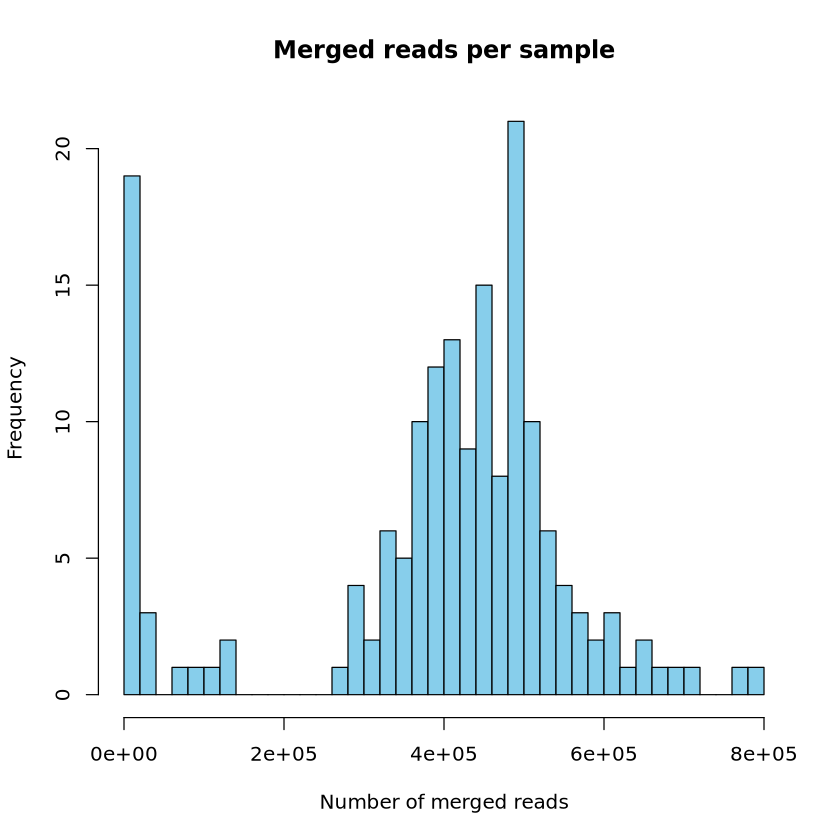

In [49]:
merged_counts <-sapply(mergers, function(x) sum(x$abundance)) #How many reads were successfully merged per sample!
head(merged_counts) #Quick table of the total merged reads per sample.

#visualize the distribution of merged reads
hist(merged_counts, main = "Merged reads per sample",
     xlab = "Number of merged reads", ylab = "Frequency",
     col = "skyblue", breaks = 30)

In [14]:
# Remove chimeras
seqtab <- makeSequenceTable(mergers)#Create a sequence table
dim(seqtab)
seqtab2 <- seqtab[,nchar(colnames(seqtab)) %in% 250:258]
sum(seqtab2)/sum(seqtab)
saveRDS(seqtab, file.path(output_dir, "seqtab.rds"))

[1]    169 152336

[1] 5.266055e-05

In [15]:
table(nchar(getSequences(seqtab)))
length_table <- table(nchar(getSequences(seqtab)))
saveRDS(length_table, file.path(output_dir, "length_table.rds"))


  220   221   222   223   224   225   226   227   228   229   230   231   232 
 3174   142  3190   390   189    70    35   131    42    28    36    36    37 
  233   234   235   236   237   238   239   240   241   242   243   244   245 
   32    34    72    35    32    31    30    14    17    25    19    18    22 
  246   247   248   249   250   251   252   253   254   255   256   257   258 
   29   116    18    24    37    33    44    43    31    35    52     9    15 
  259   260   261   262   263   264   265   266   267   268   269   270   271 
   60    23    21    77    58    81    16    24    28    19    17    21    28 
  272   273   274   275   276   277   278   279   280   281   282   283   284 
   42    14     8     9    27    52    13    39    23    12    19    15    30 
  285   286   287   288   289   290   291   292   293   294   295   296   297 
   19    21    22    52    23    16    40    39    20    20    16    81    12 
  298   299   300   301   302   303   304   305   3

In [16]:
#Remove bimeras
seqtab.nochim <- removeBimeraDenovo(seqtab, method="consensus", multithread=TRUE, verbose=TRUE)
dim(seqtab.nochim)
sum(seqtab.nochim)/sum(seqtab)
saveRDS(dim(seqtab.nochim), file.path(output_dir, "seqtab_nochim_dim.rds"))
saveRDS(sum(seqtab.nochim) / sum(seqtab), file.path(output_dir, "seqtab_nochim_ratio.rds"))

Identified 118015 bimeras out of 152336 input sequences.



[1]   169 34321

[1] 0.9335288

In [53]:
# Track read retention through the pipeline
getN <- function(x) sum(getUniques(x))
track <- cbind(out, sapply(dadaFs, getN), sapply(dadaRs, getN), sapply(mergers, getN), rowSums(seqtab.nochim))
colnames(track) <- c("input", "filtered", "denoisedF", "denoisedR", "merged", "nonchim")
rownames(track) <- sample.names
head(track)
write.table(track, "/scratch/negishi/ldas/1_5_25/DADA2_outputs/track_reads_summary.csv", row.names = TRUE, col.names = NA, sep = ",", dec = ".", qmethod = "double")

,input,filtered,denoisedF,denoisedR,merged,nonchim
1083-1,30880,25702,25383,25499,23758,23038
1083-2,33967,28345,27975,28091,26335,25693
1083-3,12109,10178,9985,10038,9401,9255
1083-4,23508,19502,19306,19366,18314,17903
1083-PBS,19989,17178,17101,17170,16888,16888
1165D1LM,609025,513044,502491,508445,437232,412160


In [17]:
# Remove samples starting with "1083"
seqtab.samples <- subset(seqtab.nochim, !grepl("^1083", rownames(seqtab.nochim)))

In [18]:
# Assign taxonomy
taxa <- assignTaxonomy(seqtab.nochim, "/scratch/negishi/ldas/1_5_25/DADA2_inputs/silva_nr99_v138.2_toGenus_trainset.fa", multithread=TRUE)
saveRDS(taxa, file.path(output_dir, "taxa_assignments.rds"))

In [19]:
taxa.print <- taxa
rownames(taxa.print) <- NULL
head(taxa.print)

Kingdom,Phylum,Class,Order,Family,Genus
Bacteria,Bacillota,Clostridia,Peptostreptococcales-Tissierellales,Peptostreptococcaceae,Romboutsia
Bacteria,Bacillota,Bacilli,Erysipelotrichales,Erysipelotrichaceae,Turicibacter
Bacteria,Actinomycetota,Actinobacteria,Bifidobacteriales,Bifidobacteriaceae,Bifidobacterium
Bacteria,Bacillota,Clostridia,Clostridiales,Clostridiaceae,Clostridium
Bacteria,Bacillota,Clostridia,Peptostreptococcales-Tissierellales,Peptostreptococcaceae,Paeniclostridium
Bacteria,Bacillota,Bacilli,Lactobacillales,Listeriaceae,Listeria


In [20]:
# Assign taxonomy_species
taxa <- addSpecies(taxa, "/scratch/negishi/ldas/1_5_25/DADA2_inputs/silva_v138.2_assignSpecies.fa")
saveRDS(taxa, file.path(output_dir, "taxa_species.rds"))

In [21]:
taxa.print <- taxa
rownames(taxa.print) <- NULL
head(taxa.print)

Kingdom,Phylum,Class,Order,Family,Genus,Species
Bacteria,Bacillota,Clostridia,Peptostreptococcales-Tissierellales,Peptostreptococcaceae,Romboutsia,NA
Bacteria,Bacillota,Bacilli,Erysipelotrichales,Erysipelotrichaceae,Turicibacter,NA
Bacteria,Actinomycetota,Actinobacteria,Bifidobacteriales,Bifidobacteriaceae,Bifidobacterium,NA
Bacteria,Bacillota,Clostridia,Clostridiales,Clostridiaceae,Clostridium,NA
Bacteria,Bacillota,Clostridia,Peptostreptococcales-Tissierellales,Peptostreptococcaceae,Paeniclostridium,NA
Bacteria,Bacillota,Bacilli,Lactobacillales,Listeriaceae,Listeria,NA


In [22]:
# Check number of chloroplast sequences
sum(taxa[, "Order"] == "Chloroplast", na.rm = TRUE)

# Check number of mitochondrial sequences
sum(taxa[, "Family"] == "Mitochondria", na.rm = TRUE)

# View the actual rows (optional)
chloroplast_taxa <- taxa[taxa[, "Order"] == "Chloroplast", , drop = FALSE]
mitochondria_taxa <- taxa[taxa[, "Family"] == "Mitochondria", , drop = FALSE]

# View if any exist
if (nrow(chloroplast_taxa) > 0) print(chloroplast_taxa)
if (nrow(mitochondria_taxa) > 0) print(mitochondria_taxa)


[1] 75

[1] 317

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [23]:
# Remove chloroplast and mitochondrial DNA
taxa_filtered <- taxa[!(taxa[, "Order"] == "Chloroplast" | taxa[, "Family"] == "Mitochondria"), ]
saveRDS(taxa_filtered, file.path(output_dir, "taxa_wo_chloroplast_mitochondria.rds"))

In [24]:
# Number of chloroplast sequences in the filtered data
sum(taxa_filtered[, "Order"] == "Chloroplast", na.rm = TRUE)

# Number of mitochondrial sequences in the filtered data
sum(taxa_filtered[, "Family"] == "Mitochondria", na.rm = TRUE)

[1] 0

[1] 0

In [25]:
###Create Phyloseq Object Without Positive Controls
# Subset OTU table to match filtered taxonomy
seqtab.filtered <- seqtab.samples[, colnames(seqtab.samples) %in% rownames(taxa_filtered)]
# Create OTU table
seq <- otu_table(seqtab.filtered, taxa_are_rows = FALSE)
# Create taxonomy table
tax <- tax_table(taxa_filtered)

In [61]:
##Preparing the metadata
# Read the metadata CSV
meta <- read.csv("/scratch/negishi/ldas/1_5_25/DADA2_inputs/Cow_FecalMicrobiome_Metadata-2.csv", 
                 stringsAsFactors = FALSE, check.names = FALSE)
# Set the rownames to the corrected sample ID
rownames(meta) <- meta$Corrected_Sample_ID
# Trim whitespace from sample ID column (in case there are any hidden spaces)
meta$Corrected_Sample_ID <- trimws(meta$Corrected_Sample_ID)
sample_names(seq) <- trimws(sample_names(seq))
#Corrections to the naming pattern
sample_names(seq) <- sub("^(1179|1217|302|6767)-PBS$", "\\1D1LM-PBS", sample_names(seq))
sample_names(seq) <- gsub("^1359D1LM$", "1354D1LM", sample_names(seq)) #1354 is the correct one
sample_names(seq) <- gsub("^1359D3LM$", "1354D3LM", sample_names(seq))
#Check identicals #It should return TRUE if correct
identical(sample_names(seq), rownames(meta))

[1] TRUE

In [123]:
sample_data(ps) <- sample_data(meta)

In [124]:
str(meta$CopyNumber)


 NULL


In [125]:
# Subset metadata to only the samples in seq (in the same order)
meta_samples <- meta[sample_names(seq), ]

# Convert to phyloseq sample_data object
meta_samples <- sample_data(meta_samples)
identical(sample_names(seq), rownames(meta_samples)) 

[1] TRUE

In [126]:
# Ensure unique taxa names
taxa_names(tax) <- make.unique(taxa_names(tax))
taxa_names(seq) <- make.unique(taxa_names(seq))

In [127]:
# Generate phyloseq object without positive control. The phyloseq object, allows the following component data classes: otu_table-class, sample_data-class, taxonomyTable-class, and phylo-class.
ps <- phyloseq(seq, tax, meta_samples)
ps

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 24011 taxa and 164 samples ]
sample_data() Sample Data:       [ 164 samples by 56 sample variables ]
tax_table()   Taxonomy Table:    [ 24011 taxa by 7 taxonomic ranks ]

In [67]:
saveRDS(ps, file = file.path(output_dir, "phyloseq.rds"))
#phyloseq.rds is the phyloseq object without positive control

In [68]:
### 14. Phyloseq Object for Positive Samples
# Phyloseq for positive samples
seqtab.positive <- seqtab.nochim[grepl("mock", rownames(seqtab.nochim), ignore.case = TRUE), ]
dim(seqtab.positive)
# Create phyloseq components
seq.positive <- otu_table(seqtab.positive, taxa_are_rows = FALSE)

[1]     7 34321

In [69]:
# Subset samples that are mocks 
mock_samples <- grep("mock", sample_names(ps), ignore.case = TRUE, value = TRUE)

# Subset phyloseq object for mock samples only
ps.mock <- prune_samples(mock_samples, ps)

# Optionally prune taxa not present in these samples
ps.mock <- prune_taxa(taxa_sums(ps.mock) > 0, ps.mock)

# Check
ps.mock

# Save mock phyloseq object
saveRDS(ps.mock, file = file.path(output_dir, "ps.mock.rds"))
#ps.mock.rds is the phyloseq object for mock/positive samples

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 1634 taxa and 7 samples ]
sample_data() Sample Data:       [ 7 samples by 56 sample variables ]
tax_table()   Taxonomy Table:    [ 1634 taxa by 7 taxonomic ranks ]

In [91]:
##14 #Optional
path.rds <- "/scratch/negishi/ldas/1_5_25/DADA2_outputs"

# Define sample names for each mock group
mockA_samples <- c("mock-synthetic-ZYMO-1", "mock-synthetic-ZYMO-2", "mock-synthetic-ZYMO-3")
mockB_samples <- c("mock-synthetic-ZYMO-4", "mock-synthetic-ZYMO-5")
mockC_samples <- c("mock-synthetic1", "mock-synthetic2")

# Group them in a named list
mock_groups <- list(
  mockA = mockA_samples,
  mockB = mockB_samples,
  mockC = mockC_samples
)

# Create phyloseq objects for each mock group
for (group_name in names(mock_groups)) {
  samples <- mock_groups[[group_name]]

  # Subset OTU table
  seqtab_subset <- seqtab.nochim[rownames(seqtab.nochim) %in% samples, ]
  seq_subset <- otu_table(seqtab_subset, taxa_are_rows = FALSE)

  # Subset taxonomy (only the ASVs present in this mock group)
  tax_subset <- tax_table(taxa)[taxa_names(seq_subset), ]

  # Subset metadata
  meta_subset <- sample_data(meta_samples)[samples, ]

  # Create phyloseq object
  ps_mock <- phyloseq(seq_subset, tax_subset, meta_subset)

  # Save the object
  saveRDS(ps_mock, file = file.path(path.rds, paste0("ps.", group_name, ".rds")))
}

In [70]:
path.figures <- "/scratch/negishi/ldas/1_5_25/DADA2_outputs"
path.rds <- "/scratch/negishi/ldas/1_5_25/DADA2_outputs"

In [219]:
###15. Check the quality of the sequencing using the positive control with the mock communities.
#Load the libraries and the paths
library(dada2)
library(ggplot2)
library(patchwork)
library(dplyr)
library(gghalves)
library(phyloseq)

library(dplyr)



path.rds
path.figures

[1] "/scratch/negishi/ldas/1_5_25/DADA2_outputs"

[1] "/scratch/negishi/ldas/1_5_25/DADA2_outputs"

In [72]:
#### 15.2 Load the positive mock sample
ps.mock <- readRDS(file.path(path.rds, "ps.mock.rds"))  # Use a clear variable name
ps.mock

# Define known mock community genera
mock <- c("Pseudomonas", "Escherichia/Shigella", "Salmonella",
          "Lactobacillus", "Enterococcus", "Staphylococcus", "Listeria",
          "Bacillus", "Saccharomyces", "Cryptococcus") 

# subset the taxa from positive phyloseq object coming from mock community
mock.melt <- psmelt(subset_taxa(ps.mock, Genus %in% mock))

# Clean up genus names
mock.melt$Genus <- as.character(mock.melt$Genus)
mock.melt$Genus <- ifelse(mock.melt$Genus == "Escherichia/Shigella", "Escherichia", mock.melt$Genus)

# Set factor levels for consistent plotting
mock.melt$Genus <- factor(mock.melt$Genus, levels = c("Listeria", "Pseudomonas", "Bacillus", 
                                                      "Escherichia", "Salmonella", "Lactobacillus", 
                                                      "Staphylococcus", "Enterococcus", 
                                                      "Saccharomyces", "Cryptococcus"))

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 1634 taxa and 7 samples ]
sample_data() Sample Data:       [ 7 samples by 56 sample variables ]
tax_table()   Taxonomy Table:    [ 1634 taxa by 7 taxonomic ranks ]

In [51]:
# Core data wrangling
library(dplyr)
library(tidyr)
library(readr)
library(stringr)

# Visualization
library(ggplot2)
library(ggpubr)
library(patchwork)
library(cowplot)
library(gghalves)
library(scales)
library(RColorBrewer)

# Microbiome analysis
library(dada2)
library(phyloseq)
library(microbiome)
library(decontam)
library(vegan)
library(pairwiseAdonis)



Attaching package: ‘tidyr’


The following object is masked from ‘package:S4Vectors’:

    expand



Attaching package: ‘cowplot’


The following object is masked from ‘package:ggpubr’:

    get_legend


The following object is masked from ‘package:patchwork’:

    align_plots



Attaching package: ‘scales’


The following object is masked from ‘package:readr’:

    col_factor



microbiome R package (microbiome.github.com)
    


 Copyright (C) 2011-2022 Leo Lahti, 
    Sudarshan Shetty et al. <microbiome.github.io>



Attaching package: ‘microbiome’


The following object is masked from ‘package:scales’:

    alpha


The following object is masked from ‘package:ShortRead’:

    coverage


The following object is masked from ‘package:GenomicAlignments’:

    coverage


The following object is masked from ‘package:SummarizedExperiment’:

    coverage


The following object is masked from ‘package:GenomicRanges’:

    coverage


The following object is masked from ‘package:Biostrings’:

In [12]:
ls("pairwiseAdonis")

ERROR: Error in as.environment(pos): no item called "pairwiseAdonis" on the search list


In [73]:
mock.melt <- mock.melt %>%
  group_by(Sample) %>%
  mutate(Relative.abundance = Abundance / sum(Abundance)) %>%
  ungroup()

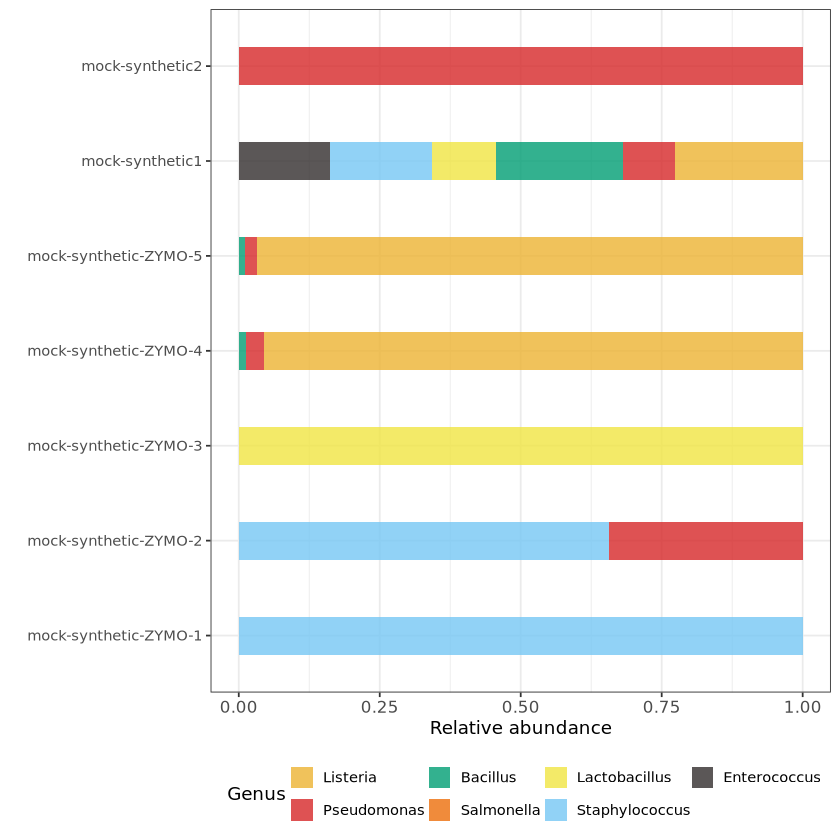

In [74]:
#### 15.3 Plot the composition of positive control against mock community

genusPalette <- c(Bacillus="#009e73", Enterococcus="#332d2d", Escherichia="#0072b2", Lactobacillus="#f0e442", Listeria="#ecb333", Pseudomonas="#d62728", Salmonella="#ec6e0b", Staphylococcus="#76c6f3", Unknown="#bababa") 

p.mock <- ggplot(data=mock.melt, aes(fill=Genus, x=Sample, y=Relative.abundance, width=.4)) +             theme_bw()+
  geom_bar(position = "stack", stat = "identity", alpha=0.8)+
  scale_fill_manual(values=genusPalette)+
  ylab("Relative abundance")+
  xlab("")+
  coord_flip()+
  theme(
    axis.text.x = element_text(size = 10),
    axis.title.y = element_text(size = 10),
    legend.position = "bottom",
    legend.key.size = unit(0.5, "cm")
  )
p.mock

Warning message:
“Removed 2 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”


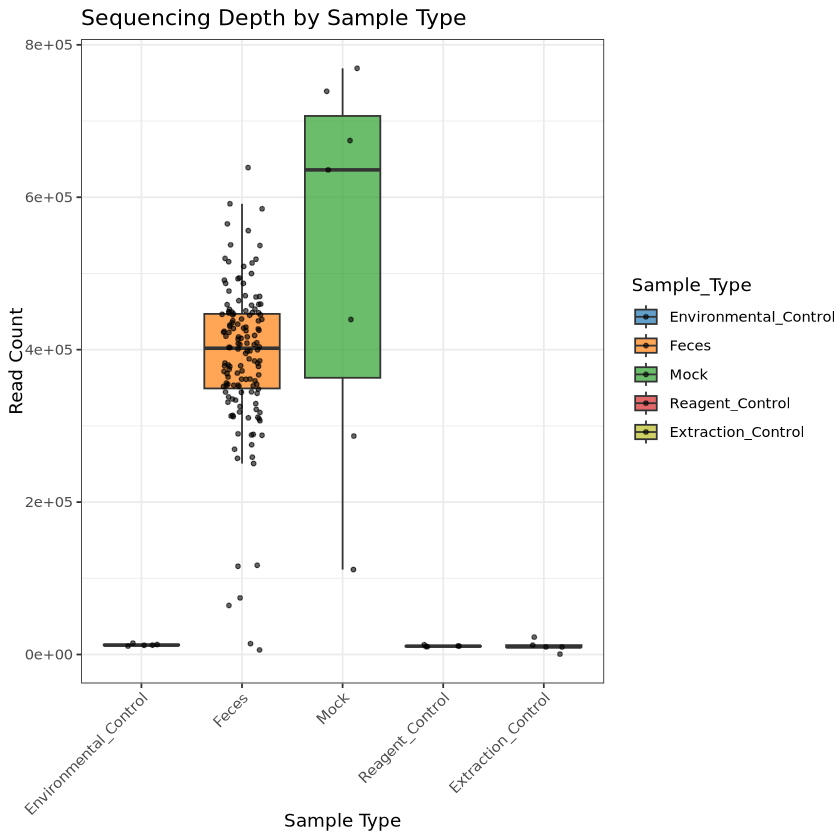

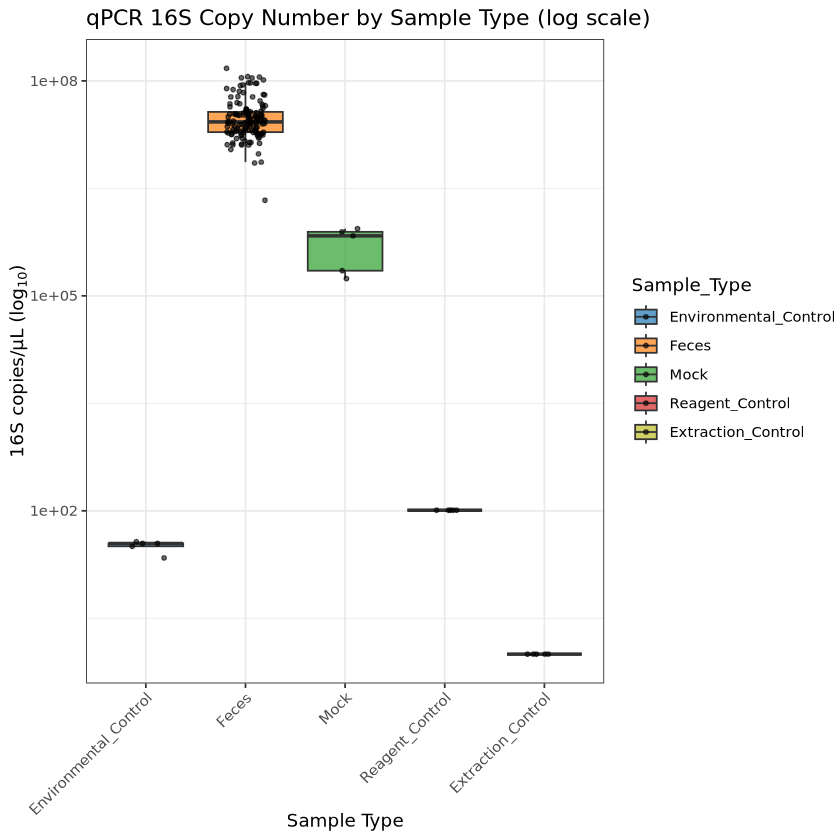

In [105]:
#### 15.4 Plot sequencing depth and 16S gene copy numbers by sample types
# Extract sample data into a data frame
sdata_df <- as(sample_data(ps), "data.frame")

# Clean any whitespace
sdata_df$Sample_Type <- trimws(sdata_df$Sample_Type)

SAMPLE_TYPES <- c("Environmental_Control", "Feces", "Mock", "Reagent_Control", "Extraction_Control")
sdata_df$Sample_Type <- factor(sdata_df$Sample_Type, levels = SAMPLE_TYPES)

# Add sequencing depth 
sdata_df$read_count <- sample_sums(ps)

# Define color palette
ColorFillManual <- c(
  "Environmental_Control" = "#1f77b4",
  "Feces" = "#ff7f0e",
  "Mock" = "#2ca02c",
  "Reagent_Control" = "#d62728",
  "Extraction_Control" = "#bcbd22"
)

theme_set(theme_bw())

# ---- Plot 1: Sequencing Depth ----
p1 <- ggplot(sdata_df, aes(x = Sample_Type, y = read_count, fill = Sample_Type)) +
  geom_boxplot(outlier.shape = NA, alpha = 0.7) +
  geom_jitter(width = 0.2, size = 1, alpha = 0.6) +
  scale_fill_manual(values = ColorFillManual) +
  labs(title = "Sequencing Depth by Sample Type", y = "Read Count", x = "Sample Type") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

# ---- Plot 2: qPCR 16S Copy Number (log10 scale) ----
# Make sure 'qpcr_16s_copies_ul' is numeric
sdata_df$qpcr_16s_copies_ul <- as.numeric(sdata_df$qpcr_16s_copies_ul)

p2 <- ggplot(sdata_df, aes(x = Sample_Type, y = qpcr_16s_copies_ul, fill = Sample_Type)) +
  geom_boxplot(outlier.shape = NA, alpha = 0.7) +
  geom_jitter(width = 0.2, size = 1, alpha = 0.6) +
  scale_fill_manual(values = ColorFillManual) +
  scale_y_log10() +
  labs(title = "qPCR 16S Copy Number by Sample Type (log scale)",
       y = expression("16S copies/μL (log"[10]*")"),
       x = "Sample Type") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

# Display both plots
p1
p2

In [112]:
# Remove commas and convert to numeric
meta$qpcr_16s_copies_ul <- as.numeric(gsub(",", "", meta$qpcr_16s_copies_ul))
sample_data(ps) <- sample_data(meta)
sdata_df <- as(sample_data(ps), "data.frame")


In [111]:
sdata_df$Sample_Type <- factor(sdata_df$Sample_Type)
table(sdata_df$Sample_Type, useNA = "ifany")  # Check if any NAs


Environmental_Control                 Feces                  Mock 
                    5                   142                     7 
      Reagent_Control    Extraction_Control 
                    5                     5 

In [99]:
# statistical analysis using glm, ANOVA and emmeans
glm.sample.CopyN <- glm(log(CopyNumber) ~ Sample_Type, data = sdata_df)
summary(glm.sample.CopyN)
car::Anova(glm.sample.CopyN)
emmeans::emmeans(glm.sample.CopyN, pairwise ~ Sample_Type)



Call:
glm(formula = log(CopyNumber) ~ Sample_Type, data = sdata_df)

Coefficients:
                              Estimate Std. Error t value Pr(>|t|)    
(Intercept)                     3.4557     0.2706  12.768  < 2e-16 ***
Sample_TypeFeces               13.7123     0.2754  49.796  < 2e-16 ***
Sample_TypeMock                 9.5585     0.3828  24.973  < 2e-16 ***
Sample_TypeReagent_Control      1.1693     0.3828   3.055  0.00265 ** 
Sample_TypeExtraction_Control  -3.4557     0.3828  -9.029 5.95e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for gaussian family taken to be 0.3662466)

    Null deviance: 2994.905  on 161  degrees of freedom
Residual deviance:   57.501  on 157  degrees of freedom
AIC: 303.94

Number of Fisher Scoring iterations: 2


,LR Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
Sample_Type,8020.292,4,0


ERROR: Error in loadNamespace(x): there is no package called ‘emmeans’


In [ ]:
####Decontam and sourcetracker

In [38]:
## Contaminant Identification with *Decontam*

#R package ‘decontam’ version 1.26.0

### 1. Load Required Libraries
library(decontam)
library(dplyr)
library(ggplot2)
library(phyloseq)
library(ggpubr)
library(pairwiseAdonis)
library(patchwork)
library(microbiome)

ERROR: Error in library(microbiome): there is no package called ‘microbiome’


In [2]:
### 2. Define Sample Types and Paths

TYPE <- c("Feces")
path.rds
path.figures

ERROR: Error: object 'path.rds' not found


In [1]:
### 3. Load Phyloseq Object

ps <- readRDS(file.path(path.rds, "phyloseq.rds"))
ps

ERROR: Error: object 'path.rds' not found


In [214]:
# Convert phyloseq sample_data to data.frame with mock included
samp_df <- as.data.frame(sample_data(ps))

# Clean whitespace in Sample_Type
samp_df$Sample_Type <- trimws(samp_df$Sample_Type)

# Initialize SampleOrControl as 'Sample'
samp_df$SampleOrControl <- "Sample"

# Set to 'Control' only for real control types
samp_df$SampleOrControl[samp_df$Sample_Type %in% c("Environmental_Control", "Extraction_Control", "Reagent_Control")] <- "Control"

# Optional: Check what's being classified
table(samp_df$SampleOrControl, samp_df$Sample_Type)

# Assign CopyNumber from qpcr_16s_copies_ul if present
if ("qpcr_16s_copies_ul" %in% colnames(samp_df)) {
  samp_df$CopyNumber <- as.numeric(as.character(samp_df$qpcr_16s_copies_ul))
} else {
  warning("qpcr_16s_copies_ul column not found in sample data")
}

# Ensure CopyNumber is numeric
if ("CopyNumber" %in% colnames(samp_df)) {
  samp_df$CopyNumber <- as.numeric(samp_df$CopyNumber)
}

# Write back to phyloseq sample_data
sample_data(ps) <- sample_data(samp_df)

# Now subset to exclude controls (Mock is retained as 'Sample')
ps.samples <- subset_samples(ps, SampleOrControl == "Sample")
ps.samples <- prune_taxa(taxa_sums(ps.samples) > 0, ps.samples)

# Optional: Confirm included Sample_Types
unique(sample_data(ps.samples)$Sample_Type)
#####ps.sample has mock included

# Filter to samples with valid, positive CopyNumber
valid_samples_all <- sample_data(ps.samples)$CopyNumber > 0 & !is.na(sample_data(ps.samples)$CopyNumber)
ps.samples.filtered <- prune_samples(valid_samples_all, ps.samples)
# View summary
ps.samples.filtered

         
          Environmental_Control Extraction_Control Feces Mock Reagent_Control
  Control                     5                  5     0    0               5
  Sample                      0                  0   142    7               0

[1] "Feces" "Mock"

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 22535 taxa and 147 samples ]
sample_data() Sample Data:       [ 147 samples by 59 sample variables ]
tax_table()   Taxonomy Table:    [ 22535 taxa by 7 taxonomic ranks ]

In [215]:
# All sample names before CopyNumber filter
before <- sample_names(ps.samples)

# After filtering
after <- sample_names(ps.samples.filtered)

# Show dropped samples
setdiff(before, after)

# Look at their CopyNumber
sample_data(ps.samples)[setdiff(before, after), "CopyNumber"]

[1] "mock-synthetic1" "mock-synthetic2"

,CopyNumber
,<dbl>
mock-synthetic1,NA
mock-synthetic2,NA


In [216]:
# Subset to include only true samples (e.g., "Feces")
ps.true_samples <- subset_samples(ps, SampleOrControl == "Sample" & Sample_Type == "Feces")
ps.true_samples <- prune_taxa(taxa_sums(ps.true_samples) > 0, ps.true_samples)
unique(sample_data(ps.true_samples)$Sample_Type)
#####ps.true_sample has only feces
# 2. True biological samples only (e.g., Feces)
# -------------------------

# Filter to valid, positive CopyNumber
valid_samples_true <- sample_data(ps.true_samples)$CopyNumber > 0 & !is.na(sample_data(ps.true_samples)$CopyNumber)
ps.true_samples.filtered <- prune_samples(valid_samples_true, ps.true_samples)

[1] "Feces"

Samples in ps.true_samples.filtered: 142 


In [222]:
# 1. Update sample data (assuming ps is your initial phyloseq object)
samp_df <- as.data.frame(sample_data(ps))
samp_df$Sample_Type <- trimws(samp_df$Sample_Type)
samp_df$SampleOrControl <- "Sample"
samp_df$SampleOrControl[samp_df$Sample_Type %in% c("Environmental_Control", "Extraction_Control", "Reagent_Control")] <- "Control"

if ("qpcr_16s_copies_ul" %in% colnames(samp_df)) {
  samp_df$CopyNumber <- as.numeric(gsub(",", "", as.character(samp_df$qpcr_16s_copies_ul)))
} else {
  warning("qpcr_16s_copies_ul column not found in sample data")
}

# Make sure CopyNumber is numeric
if ("CopyNumber" %in% colnames(samp_df)) {
  samp_df$CopyNumber <- as.numeric(samp_df$CopyNumber)
}

sample_data(ps) <- sample_data(samp_df)

# 2a. Subset to all samples including Mock (SampleOrControl == "Sample")
ps.samples <- subset_samples(ps, SampleOrControl == "Sample")
ps.samples <- prune_taxa(taxa_sums(ps.samples) > 0, ps.samples)

# 2b. Further filter for samples with valid positive CopyNumber
valid_samples <- sample_data(ps.samples)$CopyNumber > 0 & !is.na(sample_data(ps.samples)$CopyNumber)
ps.samples.filtered <- prune_samples(valid_samples, ps.samples)

# 3a. Subset to only 'Feces' samples (true biological samples)
ps.true_samples <- subset_samples(ps.samples.filtered, Sample_Type == "Feces")
ps.true_samples <- prune_taxa(taxa_sums(ps.true_samples) > 0, ps.true_samples)

# 4. Save the phyloseq objects to RDS files

saveRDS(ps.samples.filtered, file.path(output_dir, "ps_samples_including_mock.rds"))
saveRDS(ps.true_samples, file.path(output_dir, "ps_true_feces_samples.rds"))

# Optional: print summaries
cat("Samples including Mock:\n")
print(ps.samples.filtered)
#####ps_samples_including_mock.rds is for ps.samples.filtered (feces+mock)

cat("\nTrue Feces samples only:\n")
print(ps.true_samples)
####ps_true_feces_samples.rds is for ps.true_samples (only the feces)

Samples including Mock:
phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 22535 taxa and 147 samples ]
sample_data() Sample Data:       [ 147 samples by 59 sample variables ]
tax_table()   Taxonomy Table:    [ 22535 taxa by 7 taxonomic ranks ]

True Feces samples only:
phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 21086 taxa and 142 samples ]
sample_data() Sample Data:       [ 142 samples by 59 sample variables ]
tax_table()   Taxonomy Table:    [ 21086 taxa by 7 taxonomic ranks ]


In [223]:
### Run decontam using the frequency method
# Run decontam on samples including Mock
contamdf.freq.samples <- isContaminant(ps.samples.filtered,
                                      method = "frequency",
                                      conc = "CopyNumber",
                                      threshold = 0.5)

cat("Contaminants detected in samples including Mock:\n")
print(table(contamdf.freq.samples$contaminant))


# Run decontam on true feces samples only
contamdf.freq.true <- isContaminant(ps.true_samples,
                                   method = "frequency",
                                   conc = "CopyNumber",
                                   threshold = 0.5)

cat("\nContaminants detected in true feces samples:\n")
print(table(contamdf.freq.true$contaminant))


Contaminants detected in samples including Mock:

FALSE  TRUE 
20377  2158 

Contaminants detected in true feces samples:

FALSE  TRUE 
19166  1920 


In [224]:
# Identify contaminant feature indices
contam_feature_indices <- which(contamdf.freq$contaminant == TRUE)

# View the first few contaminant indices
head(contam_feature_indices)

[1]   6   7  97 120 125 154

In [225]:

# Select contaminant taxa names from the contaminant dataframe
contam_seq_freq <- rownames(contamdf.freq[contamdf.freq$contaminant == TRUE, ])

# Filter contaminants with prevalence > 1 and add a categorical Prevalence column
contamdf.freqMod <- contamdf.freq %>%
  filter(prev > 1) %>%
  mutate(
    Prevalence = case_when(
      prev == 2 ~ "2",
      prev > 2 & prev <= 5 ~ "3-5",
      prev >= 6 & prev <= 10 ~ "6-10",
      prev > 10 ~ "11+"
    )
  )

# Set factor levels for the Prevalence column
contamdf.freqMod$Prevalence <- factor(
  contamdf.freqMod$Prevalence,
  levels = c("2", "3-5", "6-10", "11+")
)


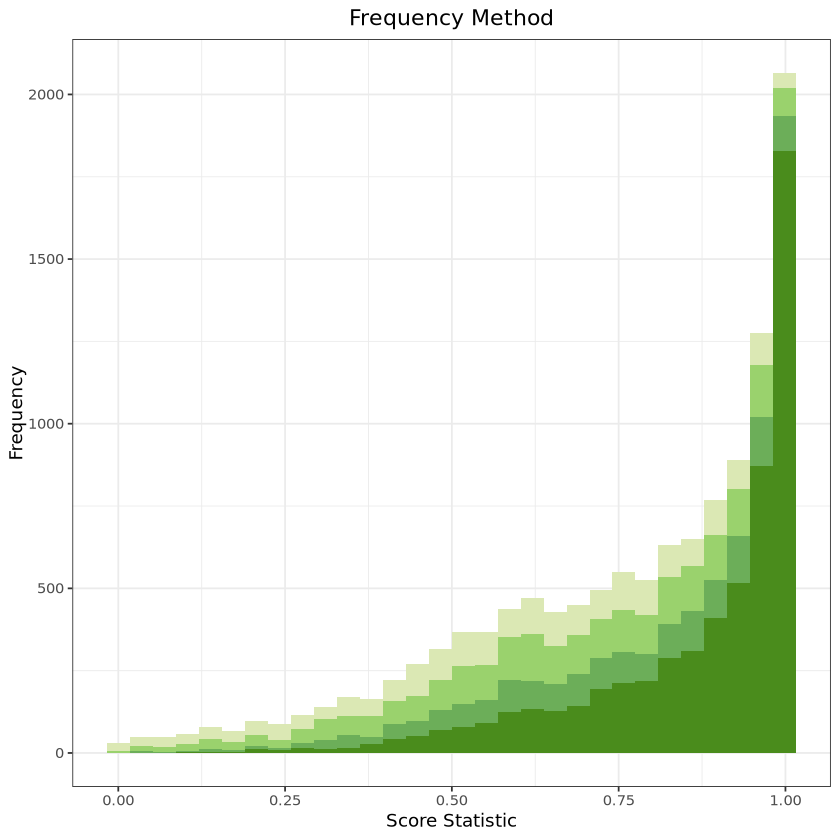

In [226]:
#Plot score statistics output from ‘frequency’ method
library(ggplot2)

# Set the theme
theme_set(theme_bw())

# Define manual fill scale for Prevalence categories (Area Green Tableau palette)
scaleColorFillManualFrequency <- scale_fill_manual(values = c(
  "2" = "#dbe8b4",
  "3-5" = "#9ad26d",
  "6-10" = "#6cae59",
  "11+" = "#4a8c1c"
))

# Create histogram plot of p-value score statistics colored by Prevalence category
freqScorePlot <- ggplot(contamdf.freqMod, aes(x = p, fill = Prevalence)) +
  geom_histogram(bins = 30) +
  scaleColorFillManualFrequency +
  ggtitle("Frequency Method") +
  xlab("Score Statistic") +
  ylab("Frequency") +
  theme(
    plot.title = element_text(hjust = 0.5),
    legend.position = "none"
  )

# Print the plot
print(freqScorePlot)


In [230]:
# Prevalence method
#For Sample + Mock + Controls
ps.sample_mock_ctrl <- subset_samples(ps, SampleOrControl %in% c("Sample", "Control"))
ps.sample_mock_ctrl <- prune_taxa(taxa_sums(ps.sample_mock_ctrl) > 0, ps.sample_mock_ctrl)

# Add is.neg for controls
samp_df <- as.data.frame(sample_data(ps.sample_mock_ctrl))
samp_df$is.neg <- samp_df$SampleOrControl == "Control"
sample_data(ps.sample_mock_ctrl) <- sample_data(samp_df)

# Run prevalence method
contamdf.prev.sample_mock <- isContaminant(ps.sample_mock_ctrl, method = "prevalence", neg = "is.neg", threshold = 0.5)

# Table
table(contamdf.prev.sample_mock$contaminant)



FALSE  TRUE 
23164   490 

In [231]:
## Prevalence for true sample
# For Sample +Control
ps.true_samples_ctrl <- subset_samples(ps, Sample_Type %in% "Feces" | SampleOrControl == "Control")
ps.true_samples_ctrl <- prune_taxa(taxa_sums(ps.true_samples_ctrl) > 0, ps.true_samples_ctrl)

# Add is.neg for controls
samp_df <- as.data.frame(sample_data(ps.true_samples_ctrl))
samp_df$is.neg <- samp_df$SampleOrControl == "Control"
sample_data(ps.true_samples_ctrl) <- sample_data(samp_df)

# Run prevalence method
contamdf.prev.true_samples <- isContaminant(ps.true_samples_ctrl, method = "prevalence", neg = "is.neg", threshold = 0.5)

# Table
table(contamdf.prev.true_samples$contaminant)



FALSE  TRUE 
21770   466 

In [236]:
# Display the number of sequence features classified as contaminants
# FALSE: Number of sequence features not classified as contaminants
# TRUE: Number of sequence features classified as contaminants
# Get contaminant feature indices
contam_feature_indices_prev_sample_mock <- which(contamdf.prev.sample_mock$contaminant == TRUE)

# View first few
head(contam_feature_indices_prev_sample_mock)
# Get contaminant feature indices
contam_feature_indices_prev_true_samples <- which(contamdf.prev.true_samples$contaminant == TRUE)

# View first few
head(contam_feature_indices_prev_true_samples)


[1]  827 1669 2131 2755 2846 3091

[1] 1568 2006 2605 2691 2926 3195

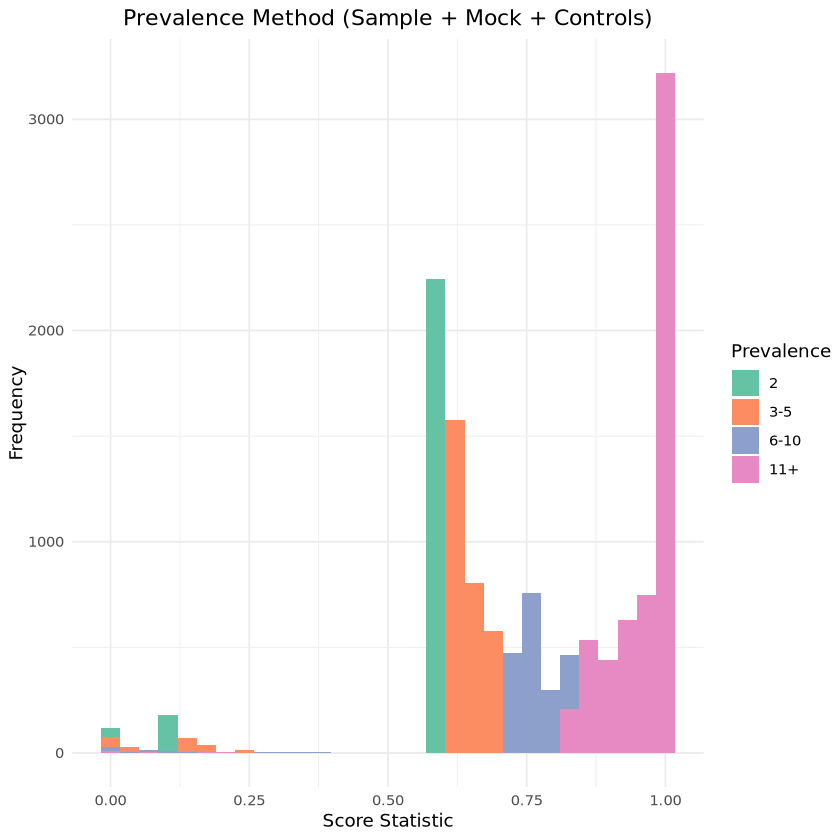

In [237]:
### Plot prevalnce for mock+sample
# Filter and categorize prevalence values 
contamdf.prev.sample_mock_mod <- contamdf.prev.sample_mock %>%
  filter(prev > 1) %>%
  mutate(Prevalence = case_when(
    prev == 2 ~ "2",
    prev > 2 & prev <= 5 ~ "3-5",
    prev >= 6 & prev <= 10 ~ "6-10",
    prev > 10 ~ "11+"
  ))

# Set factor levels
contamdf.prev.sample_mock_mod$Prevalence <- factor(
  contamdf.prev.sample_mock_mod$Prevalence,
  levels = c("2", "3-5", "6-10", "11+")
)

# Plot
prev_plot_sample_mock <- ggplot(contamdf.prev.sample_mock_mod, aes(x = p, fill = Prevalence)) +
  geom_histogram(bins = 30) +
  scale_fill_manual(values = c("#66c2a5", "#fc8d62", "#8da0cb", "#e78ac3")) +
  ggtitle("Prevalence Method (Sample + Mock + Controls)") +
  xlab("Score Statistic") +
  ylab("Frequency") +
  theme_minimal() +
  theme(plot.title = element_text(hjust = 0.5),
        legend.position = "right")

# Show plot
prev_plot_sample_mock


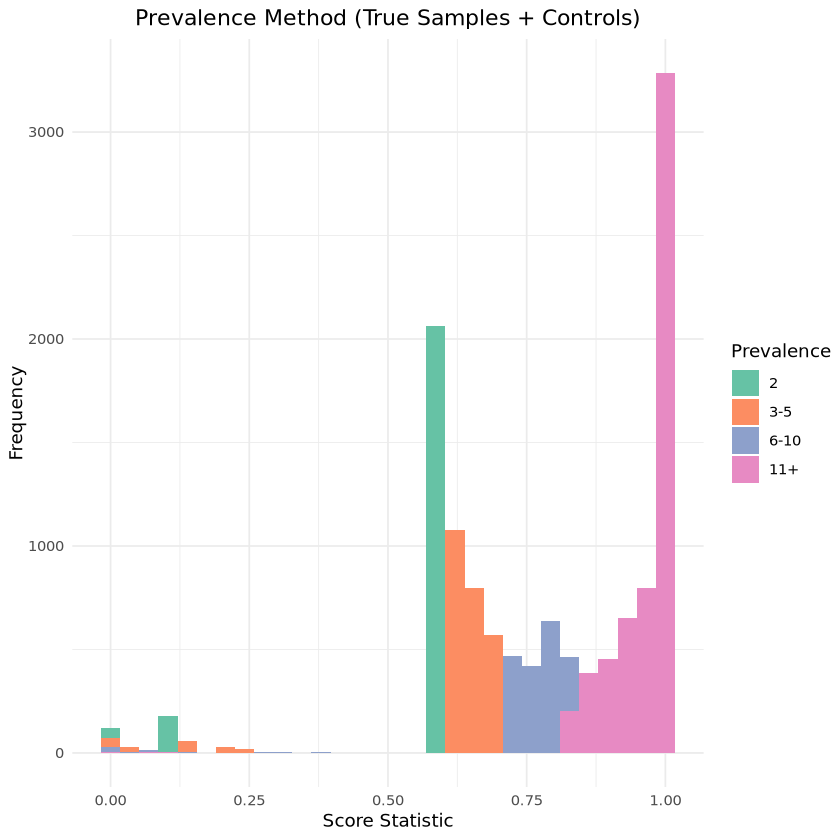

In [238]:
# Filter and categorize prevalence values
contamdf.prev.true_samples_mod <- contamdf.prev.true_samples %>%
  filter(prev > 1) %>%
  mutate(Prevalence = case_when(
    prev == 2 ~ "2",
    prev > 2 & prev <= 5 ~ "3-5",
    prev >= 6 & prev <= 10 ~ "6-10",
    prev > 10 ~ "11+"
  ))

# Set factor levels
contamdf.prev.true_samples_mod$Prevalence <- factor(
  contamdf.prev.true_samples_mod$Prevalence,
  levels = c("2", "3-5", "6-10", "11+")
)

# Plot
prev_plot_true_samples <- ggplot(contamdf.prev.true_samples_mod, aes(x = p, fill = Prevalence)) +
  geom_histogram(bins = 30) +
  scale_fill_manual(values = c("#66c2a5", "#fc8d62", "#8da0cb", "#e78ac3")) +
  ggtitle("Prevalence Method (True Samples + Controls)") +
  xlab("Score Statistic") +
  ylab("Frequency") +
  theme_minimal() +
  theme(plot.title = element_text(hjust = 0.5),
        legend.position = "right")

# Show plot
prev_plot_true_samples


In [241]:
### Sample + Mock + Controls:
contam_seq_prev_sample_mock <- rownames(
  contamdf.prev.sample_mock[contamdf.prev.sample_mock$contaminant == TRUE, ]
)
#### Sample
contam_seq_prev_true_samples <- rownames(
  contamdf.prev.true_samples[contamdf.prev.true_samples$contaminant == TRUE, ]
)

In [242]:
# Remove contaminants
ps.cleaned <- prune_taxa(!(taxa_names(ps) %in% contam_seq_prev_true_samples), ps)

In [243]:
# Remove contaminants from Sample + Mock
ps.sample_mock_cleaned <- prune_taxa(
  !(taxa_names(ps.sample_mock_ctrl) %in% contam_seq_prev_sample_mock),
  ps.sample_mock_ctrl
)

# Save cleaned object
saveRDS(ps.sample_mock_cleaned, file.path(output_dir, "ps.sample_mock_cleaned.rds"))

In [244]:
# Remove contaminants from True Feces
ps.true_sample_cleaned <- prune_taxa(
  !(taxa_names(ps.true_samples_ctrl) %in% contam_seq_prev_true_samples),
  ps.true_samples_ctrl
)

# Save cleaned object
saveRDS(ps.true_sample_cleaned, file.path(output_dir, "ps.true_sample_cleaned.rds"))


In [245]:
ntaxa(ps.sample_mock_cleaned)
ntaxa(ps.true_sample_cleaned)

[1] 23164

[1] 21770

In [251]:
### Sample + Mock + Control
# Create presence-absence version of full phyloseq object
ps.pa.sample_mock_ctrl <- transform_sample_counts(ps, function(abund) 1 * (abund > 0))

# Subset to negative controls (e.g., extraction, reagent, etc.)
ps.pa.neg.sample_mock_ctrl <- prune_samples(sample_data(ps.pa.sample_mock_ctrl)$SampleOrControl == "Control", ps.pa.sample_mock_ctrl)

# Subset to true samples (includes both real samples and mock)
ps.pa.pos.sample_mock_ctrl <- prune_samples(sample_data(ps.pa.sample_mock_ctrl)$SampleOrControl %in% c("Sample", "Mock"), ps.pa.sample_mock_ctrl)


In [252]:
### Sample + Mock
# Subset original phyloseq object first
ps.sample_ctrl <- subset_samples(ps, Sample_Type %in% "Feces" | SampleOrControl == "Control")
ps.sample_ctrl <- prune_taxa(taxa_sums(ps.sample_ctrl) > 0, ps.sample_ctrl)

# Create presence-absence object
ps.pa.sample_ctrl <- transform_sample_counts(ps.sample_ctrl, function(abund) 1 * (abund > 0))

# Subset to negative controls
ps.pa.neg.sample_ctrl <- prune_samples(sample_data(ps.pa.sample_ctrl)$SampleOrControl == "Control", ps.pa.sample_ctrl)

# Subset to true samples only (excluding control and mock)
ps.pa.pos.sample_ctrl <- prune_samples(sample_data(ps.pa.sample_ctrl)$Sample_Type == "Feces", ps.pa.sample_ctrl)


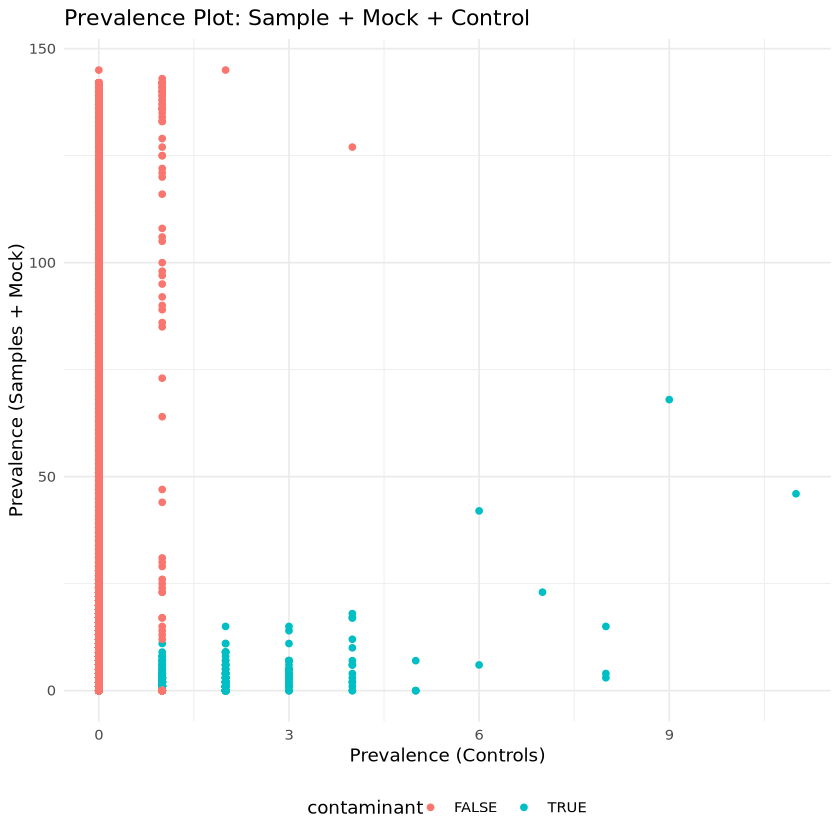

In [258]:
# Get all taxa
all_taxa <- taxa_names(ps.pa.sample_mock_ctrl)

# Prevalence in positive and negative samples
pa.pos <- taxa_sums(prune_taxa(all_taxa, ps.pa.pos.sample_mock_ctrl))
pa.neg <- taxa_sums(prune_taxa(all_taxa, ps.pa.neg.sample_mock_ctrl))

# Ensure contaminant vector matches all taxa
contam_status <- contamdf.prev.sample_mock$contaminant
names(contam_status) <- rownames(contamdf.prev.sample_mock)

# Align contaminant status to all taxa
contam_status_aligned <- contam_status[all_taxa]
# Replace any NA with FALSE (assume non-contaminant if not detected)
contam_status_aligned[is.na(contam_status_aligned)] <- FALSE

# Create data frame
df.pa.sample_mock <- data.frame(
  pa.pos = pa.pos,
  pa.neg = pa.neg,
  contaminant = contam_status_aligned
)

# Check dimensions
stopifnot(nrow(df.pa.sample_mock) == length(all_taxa))

# Plot
pa.plot.sample_mock <- ggplot(df.pa.sample_mock, aes(x = pa.neg, y = pa.pos, color = contaminant)) +
  geom_point() +
  theme_minimal() +
  theme(legend.position = "bottom") +
  xlab("Prevalence (Controls)") +
  ylab("Prevalence (Samples + Mock)") +
  ggtitle("Prevalence Plot: Sample + Mock + Control")

# Show plot
pa.plot.sample_mock


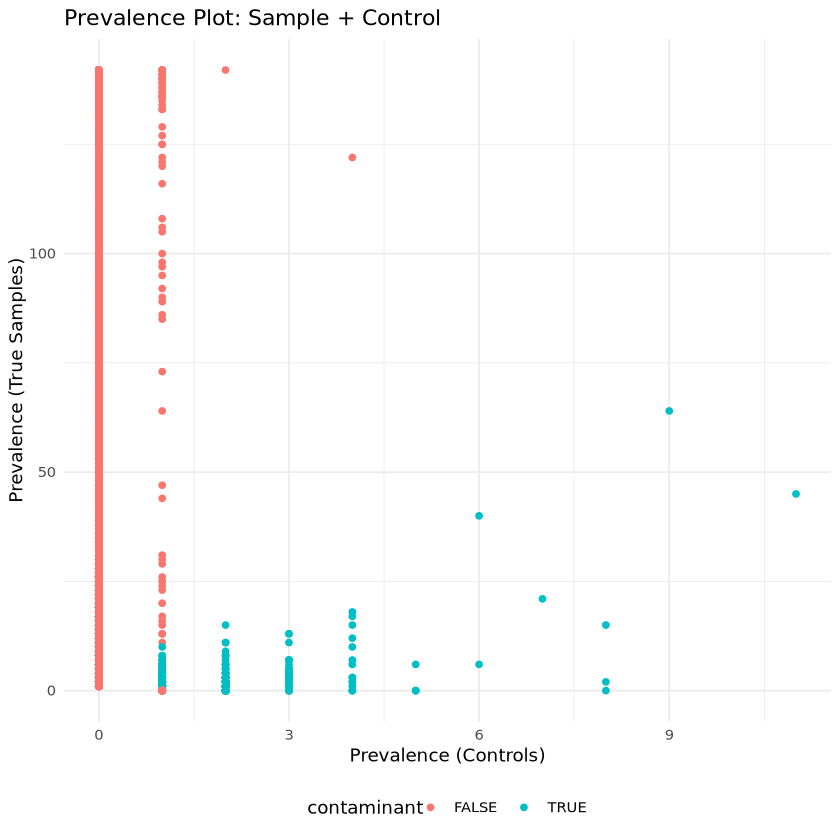

In [255]:
# Subset presence/absence objects
ps.pa.neg.sample_ctrl <- prune_samples(sample_data(ps.pa.sample_ctrl)$SampleOrControl == "Control", ps.pa.sample_ctrl)
ps.pa.pos.sample_ctrl <- prune_samples(sample_data(ps.pa.sample_ctrl)$SampleOrControl != "Control", ps.pa.sample_ctrl)

# Make data frame for prevalence
df.pa.sample_only <- data.frame(
  pa.pos = taxa_sums(ps.pa.pos.sample_ctrl),
  pa.neg = taxa_sums(ps.pa.neg.sample_ctrl),
  contaminant = contamdf.prev.true_samples$contaminant
)

# Plot
pa.plot.sample_only <- ggplot(df.pa.sample_only, aes(x = pa.neg, y = pa.pos, color = contaminant)) +
  geom_point() +
  theme_minimal() +
  theme(legend.position = "bottom") +
  xlab("Prevalence (Controls)") +
  ylab("Prevalence (True Samples)") +
  ggtitle("Prevalence Plot: Sample + Control")

pa.plot.sample_only


In [259]:
### Extraction_Control
# Remove extraction control samples
ps.no.extraction <- subset_samples(ps, Sample_Type != "Extraction_Control")

# Prune taxa that now have zero counts
ps.no.extraction <- prune_taxa(taxa_sums(ps.no.extraction) > 0, ps.no.extraction)

# View the result
ps.no.extraction

# Label negative control samples (e.g., other control types still present)
sample_data(ps.no.extraction)$is.neg <- sample_data(ps.no.extraction)$SampleOrControl == "Control"

# Run 'prevalence' method to detect contaminants based on remaining controls
contamdf.prev.extraction_control <- isContaminant(
  ps.no.extraction,
  method = "prevalence",
  neg = "is.neg",
  threshold = 0.5
)

# Count how many taxa were flagged as contaminants
table(contamdf.prev.extraction_control$contaminant)

# FALSE: Number of sequence features not classified as contaminants
# TRUE: Number of sequence features classified as contaminants

# Identify contaminant feature indices
contam_feature_indices_prev_extraction_control <- which(contamdf.prev.extraction_control$contaminant == TRUE)

# Preview the indices
head(contam_feature_indices_prev_extraction_control)


phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 23365 taxa and 159 samples ]
sample_data() Sample Data:       [ 159 samples by 59 sample variables ]
tax_table()   Taxonomy Table:    [ 23365 taxa by 7 taxonomic ranks ]


FALSE  TRUE 
22990   375 

[1] 2131 2755 2846 3091 3382 3581

In [260]:
# for sample + mock
#Extract contaminant taxa names
contam_taxa <- rownames(contamdf.prev.extraction_control)[contamdf.prev.extraction_control$contaminant == TRUE]

# Subset to Sample + Mock only
ps.sample_mock <- subset_samples(ps.no.extraction, SampleOrControl %in% c("Sample", "Mock"))

# Remove contaminants
ps.sample_mock.clean <- prune_taxa(!(taxa_names(ps.sample_mock) %in% contam_taxa), ps.sample_mock)


In [261]:
### for sample only
ps.sample_only <- subset_samples(ps.no.extraction, SampleOrControl == "Sample")
ps.sample_only.clean <- prune_taxa(!(taxa_names(ps.sample_only) %in% contam_taxa), ps.sample_only)


In [262]:
# Assuming you already have ps.no.extraction where 'Extraction_Control' samples are removed

# Make sure 'is.neg' column exists in your sample_data indicating controls
sample_data(ps.no.extraction)$is.neg <- sample_data(ps.no.extraction)$SampleOrControl == "Control"

# Run the prevalence method to detect contaminants
contamdf.prev <- isContaminant(
  ps.no.extraction,       # phyloseq object
  method = "prevalence",  # method
  neg = "is.neg",         # column in sample_data indicating controls
  threshold = 0.5         # threshold for calling contaminants
)

# View the number of contaminants found
table(contamdf.prev$contaminant)



FALSE  TRUE 
22990   375 

In [263]:
# Get taxa names flagged as contaminants
contam_taxa_prev_extraction_control <- taxa_names(ps.no.extraction)[contam_feature_indices_prev_extraction_control]

# Preview first few taxa names
head(contam_taxa_prev_extraction_control)


[1] "GTGGTCGGGACGATTATTGGGCCTAAAGCATCCGTAGCCGGTTCTACAAGTCTTCCGTTAAATCCACCTGCTTAACAGATGGGCTGCGGAGGATACTATGGAGCTAGGAGGCGGGAGAGGCAAGCGGTACTTAGTGGGTAGGGGTAAAATCCGTTGATCCATTGAAGACCACCAGTGGCGAAGGCGGCTTGCCAGAACGCACTCGACGGTGAGGGATGAAAG"                                                                                                                                                                       
[2] "TTATCCGGAATTATTGGGCGTAAAGGGTGCGTAGGCTGTTAAATAAGTTTATGGTCTAAGTGCAATGCTCAACATTGTGATGCTATAAAAACTGTTTAGCTAGAGTAAGATAGAGGCAAGTGGAATTCCATGTGTAGTGGTAAAATGCGTAAATATATGGAGGAACACCAGTAGCGAAGGCGGCTTGCTGGGTCTTTACTGACGCTGAGGCACGAAAGCG"                                                                                                                                                                         
[3] "AAAGCCTGACGGAGCAACGCCGCGTGAGTGATGAAGGTCTTCGGATCGTAAAACTCTGTTATTAGGGAAGAACAAATGTGTAAGTAACTATGCACGTCTTGACGGTACCTAATCAGAAAGCCACGGCTAACTACGTGCCAGCAGCCGCGGTAATACGTAGGTGGCAAGCGTTATCCGGAATTATTGGGCGTAAAGCGCGCGTAGGCGGTTTTTTAAGTCTGATGTGAAAGCCCACGGCTCAACCGTGGAGGGTCATTGGAAACTGGAAAACTTGAGTGCAGAAGAGGAAAGTGGAATTCCATGTGTAGCGGTGAAATGCGCAGAGATATGGAGGAACACCAGTGGCGAAGGCGACTTTCTGGTCTGTAACTGACGCTGATGTGCGAAAG"
[4] "AAAGCCTGACGGAGCAACGCCGCGTGAGTGATGAAGGTCTTCGGATCGTAAAACTCTGTTATTAGGGAAGAACAAACGTGTAAGTAACTGTGCACGTCTTGACGGTACCTAATCAGAAAGCCACGGCTAACTACGTGCCAGCAGCCGCGGTAATACGTAGGTGGCAAGCGTTATCCGGAATTATTGGGCGTAAAGCGCGCGTAGGCGGTTTTTTAAGTCTGATGTGAAAGCCCACGGCTCAACCGTGGAGGGTCATTGGAAACTGGAAAACTTGAGTGCAGAAGAGGAAAGTGGAATTCCATGTGTAGCGGTGAAATGCGCAGAGATATGGAGGAACACCAGTGGCGAAGGCGACTTTCTGGTCTGTAACTGACGCTGATGTGCGAAAG"
[5] "GCGTTGCTCGGAATCACTGGGCGTAAAGGGTGCGTAGGCGGGTCTTTAAGTCAGGGGTGAAATCCTGGAGCTCAACTCCAGAACTGCCTTTGATACTGAAGATCTTGAGTTCGGGAGAGGTGAGTGGAACTGCGAGTGTAGAGGTGAAATTCGTAGATATTCGCAAGAACACCAGTGGCGAAGGCGGCTCACTGGCCCGATACTGACGCTGAGGCACGAAAG"                                                                                                                                                                       
[6] "CAACCCTGATCCAGCCATGCCGCGTGAGTGATGAAGGCCCTAGGGTTGTAAAGCTCTTTTGTGCGGGAAGATAATGACGGTACCGCAAGAATAAGCCCCGGCTAACTTCGTGCCAGCAGCCGCGGTAATACGAAGGGGGCTAGCGTTGCTCGGAATCACTGGGCGTAAAGGGTGCGTAGGCGGGTCTTTAAGTCAGGGGTGAAATCCTGGAGCTCAACTCCAGAACTGCCTTTGATACTGAAGATCTTGAGTCCGGGAGAGGTGAGTGGAACTGCGAGTGTAGAGGTGAAATTCGTAGATATTCGCAAGAACACCAGTGGCGAAGGCGGCTCACTGGCCCGGTACTGACGCTGAGGCACGAAAG"

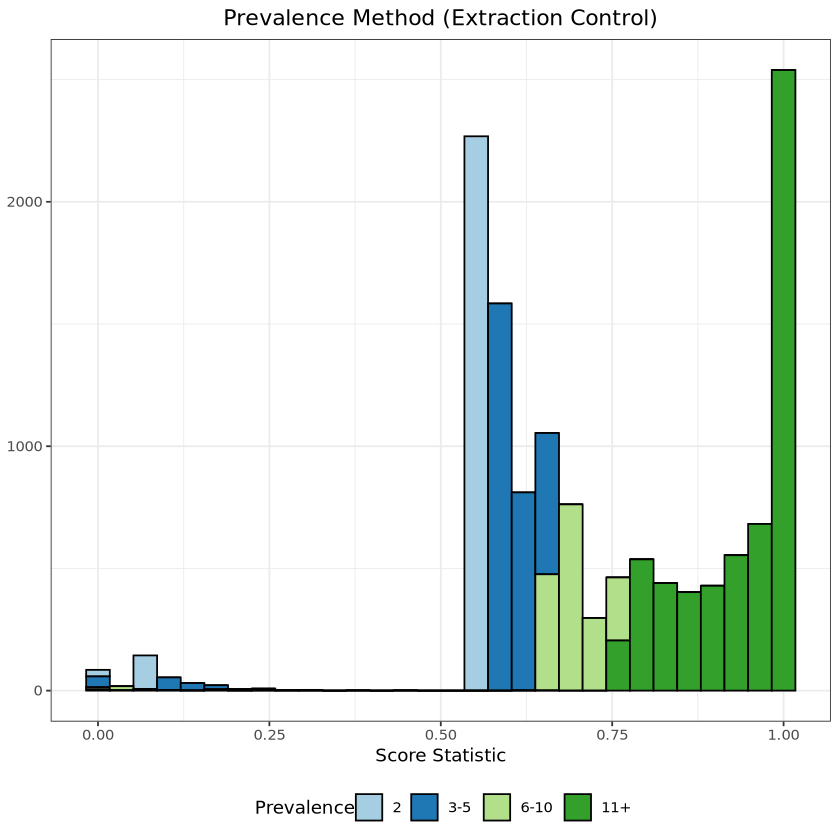

In [264]:
library(dplyr)
library(ggplot2)

# Filter to keep only taxa with prevalence > 1 and categorize prevalence into bins
contamdf.prev.extraction_controlMod <- contamdf.prev.extraction_control %>%
  filter(prev > 1) %>%
  mutate(
    Prevalence = case_when(
      prev == 2 ~ "2",
      prev > 2 & prev <= 5 ~ "3-5",
      prev >= 6 & prev <= 10 ~ "6-10",
      prev > 10 ~ "11+"
    )
  )

# Make sure the prevalence factor has the right order
contamdf.prev.extraction_controlMod$Prevalence <- factor(
  contamdf.prev.extraction_controlMod$Prevalence,
  levels = c("2", "3-5", "6-10", "11+")
)

# Define a fill color palette (modify or reuse your own palette)
scaleColorFillManualFrequency <- scale_fill_manual(
  values = c("2" = "#a6cee3", "3-5" = "#1f78b4", "6-10" = "#b2df8a", "11+" = "#33a02c")
)

# Plot histogram of the score statistic 'p' colored by prevalence category
prev.extractionScorePlot <- ggplot(contamdf.prev.extraction_controlMod, aes(x = p, fill = Prevalence)) +
  geom_histogram(bins = 30, color = "black") +
  scaleColorFillManualFrequency +
  ggtitle("Prevalence Method (Extraction Control)") +
  xlab("Score Statistic") +
  ylab("Frequency") +
  theme(
    plot.title = element_text(hjust = 0.5),
    legend.position = "bottom",
    axis.title.y = element_blank()
  )

# Show plot
prev.extractionScorePlot


In [265]:
# Select seq name of contaminants identified by prevalence method using Extraction_Control as control
contam_seq_prev_extraction_control <- rownames(contamdf.prev.extraction_control[contamdf.prev.extraction_control$contaminant == TRUE, ])

In [266]:
### Reagent_Control
# Remove reagent control samples
ps.no.reagent <- subset_samples(ps, Sample_Type != "Reagent_Control")

# Prune taxa that now have zero counts
ps.no.reagent <- prune_taxa(taxa_sums(ps.no.reagent) > 0, ps.no.reagent)

# View the result
ps.no.reagent

# Label negative control samples (e.g., other control types still present)
sample_data(ps.no.reagent)$is.neg <- sample_data(ps.no.reagent)$SampleOrControl == "Control"

# Run 'prevalence' method to detect contaminants based on remaining controls
contamdf.prev.reagent_control <- isContaminant(
  ps.no.reagent,
  method = "prevalence",
  neg = "is.neg",
  threshold = 0.5
)

# Count how many taxa were flagged as contaminants
table(contamdf.prev.reagent_control$contaminant)

# Identify contaminant feature indices
contam_feature_indices_prev_reagent_control <- which(contamdf.prev.reagent_control$contaminant == TRUE)

# Preview the indices
head(contam_feature_indices_prev_reagent_control)


phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 23290 taxa and 159 samples ]
sample_data() Sample Data:       [ 159 samples by 59 sample variables ]
tax_table()   Taxonomy Table:    [ 23290 taxa by 7 taxonomic ranks ]


FALSE  TRUE 
22936   354 

[1]  827 1669 2131 2846 3047 3091

In [268]:
# Get indices of features flagged as contaminants from extraction control prevalence results
contam_feature_indices_prev_extraction_control <- which(contamdf.prev.extraction_control$contaminant == TRUE)

# Preview the first few contaminant feature indices
head(contam_feature_indices_prev_extraction_control)


[1] 2131 2755 2846 3091 3382 3581

In [267]:
# Extract contaminant taxa names identified from reagent control prevalence method
contam_taxa_reagent <- rownames(contamdf.prev.reagent_control)[contamdf.prev.reagent_control$contaminant == TRUE]

# Subset to Sample + Mock only (using ps.no.reagent as backbone)
ps.sample_mock_reagent <- subset_samples(ps.no.reagent, SampleOrControl %in% c("Sample", "Mock"))

# Remove contaminants identified in reagent control
ps.sample_mock_reagent.clean <- prune_taxa(!(taxa_names(ps.sample_mock_reagent) %in% contam_taxa_reagent), ps.sample_mock_reagent)


In [269]:
# Subset to Sample only (using ps.no.reagent as backbone)
ps.sample_only_reagent <- subset_samples(ps.no.reagent, SampleOrControl == "Sample")

# Remove contaminants identified from reagent control
ps.sample_only_reagent.clean <- prune_taxa(!(taxa_names(ps.sample_only_reagent) %in% contam_taxa_reagent), ps.sample_only_reagent)


In [270]:
# Assuming you have ps.no.reagent where 'Reagent_Control' samples are removed

# Make sure 'is.neg' column exists in your sample_data indicating controls
sample_data(ps.no.reagent)$is.neg <- sample_data(ps.no.reagent)$SampleOrControl == "Control"

# Run the prevalence method to detect contaminants using reagent controls
contamdf.prev.reagent <- isContaminant(
  ps.no.reagent,          # phyloseq object without reagent controls
  method = "prevalence",  # method
  neg = "is.neg",         # column indicating controls
  threshold = 0.5         # threshold for calling contaminants
)

# View the number of contaminants found
table(contamdf.prev.reagent$contaminant)



FALSE  TRUE 
22936   354 

In [271]:
# Get taxa names flagged as contaminants for reagent control
contam_taxa_prev_reagent_control <- taxa_names(ps.no.reagent)[contam_feature_indices_prev_reagent_control]

# Preview first few taxa names
head(contam_taxa_prev_reagent_control)


[1] "AAACCCTGATGCAGCGACGCCGCGTGAAGGAAGAAGTATCTCGGTATGTAAACTTCTATCAGCAGGGAAGAAAATGACGGTACCTGACTAAGAAGCCCCGGCTAACTACGTGCCAGCAGCCGCGGTAATACGTAGGGGGCAAGCGTTATCCGGATTTACTGGGTGTAAAGGGAGCGTAGACGGATGGACAAGTCTGATGTGAAAGGCTGGGGCTCAACCCCGGGACTGCATTGGAAACTGCCCGTCTTGAGTGCCGGAGAGGTAAGCGGAATTCCTAGTGTAGCGGTGAAATGCGTAGATATTAGGAGGAACACCAGTGGCGAAGGCGGCTTACTGGACGGTAACTGACGTTGAGGCTCGAAAG"                         
[2] "GCGTTATCCGGAATTATTGGGCGTAAAGGGTGCGTAGGCTGTTAAATAAGTTTATGGTCTAAGTGCAATGCTCAACATTGTGATGCTATAAAAACTGTTTAGCTAGAGTAAGATAGAGGCAAGTGGAATTCCATGTGTAGTGGTAAAATGCGTAAATATATGGAGGAACACCAGTAGCGAAGGCGGCTTGCTGGGTCTTTACTGACGCTGAGGCACGAAAG"                                                                                                                                                                        
[3] "GTGGTCGGGACGATTATTGGGCCTAAAGCATCCGTAGCCGGTTCTACAAGTCTTCCGTTAAATCCACCTGCTTAACAGATGGGCTGCGGAGGATACTATGGAGCTAGGAGGCGGGAGAGGCAAGCGGTACTTAGTGGGTAGGGGTAAAATCCGTTGATCCATTGAAGACCACCAGTGGCGAAGGCGGCTTGCCAGAACGCACTCGACGGTGAGGGATGAAAG"                                                                                                                                                                       
[4] "AAAGCCTGACGGAGCAACGCCGCGTGAGTGATGAAGGTCTTCGGATCGTAAAACTCTGTTATTAGGGAAGAACAAATGTGTAAGTAACTATGCACGTCTTGACGGTACCTAATCAGAAAGCCACGGCTAACTACGTGCCAGCAGCCGCGGTAATACGTAGGTGGCAAGCGTTATCCGGAATTATTGGGCGTAAAGCGCGCGTAGGCGGTTTTTTAAGTCTGATGTGAAAGCCCACGGCTCAACCGTGGAGGGTCATTGGAAACTGGAAAACTTGAGTGCAGAAGAGGAAAGTGGAATTCCATGTGTAGCGGTGAAATGCGCAGAGATATGGAGGAACACCAGTGGCGAAGGCGACTTTCTGGTCTGTAACTGACGCTGATGTGCGAAAG"
[5] "AAACCCTGACCCAGCAACGCCGCGTGAAGGAAGAAGGCTTTCGGGTTGTAAACTTCTTTTAGCAGGGACGAAGAACGTGACGGTACCTGCAGAAAAAGCAACGGCTAACTACGTGCCAGCAGCCGCGGTAATACGTAGGTTGCAAGCGTTGTCCGGATTTACTGGGTGTAAAGGGCGTGTAGGCGGAGATGCAAGTCAGGAGTGAAATCCCGGGGCTCAACCCCGGAACTGCTTTTGAAACTGTATCCCTTGAGTGTCGGAGAGGCAAGCGGAATTCCTAGTGTAGCGGTGAAATGCGTAGATATTAGGAGGAACACCAGTGGCGAAGGCGGCTTGCTGGACGATAACTGACGCTGAGGCGCGAAAG"                      
[6] "AAAGCCTGACGGAGCAACGCCGCGTGAGTGATGAAGGTCTTCGGATCGTAAAACTCTGTTATTAGGGAAGAACAAACGTGTAAGTAACTGTGCACGTCTTGACGGTACCTAATCAGAAAGCCACGGCTAACTACGTGCCAGCAGCCGCGGTAATACGTAGGTGGCAAGCGTTATCCGGAATTATTGGGCGTAAAGCGCGCGTAGGCGGTTTTTTAAGTCTGATGTGAAAGCCCACGGCTCAACCGTGGAGGGTCATTGGAAACTGGAAAACTTGAGTGCAGAAGAGGAAAGTGGAATTCCATGTGTAGCGGTGAAATGCGCAGAGATATGGAGGAACACCAGTGGCGAAGGCGACTTTCTGGTCTGTAACTGACGCTGATGTGCGAAAG"

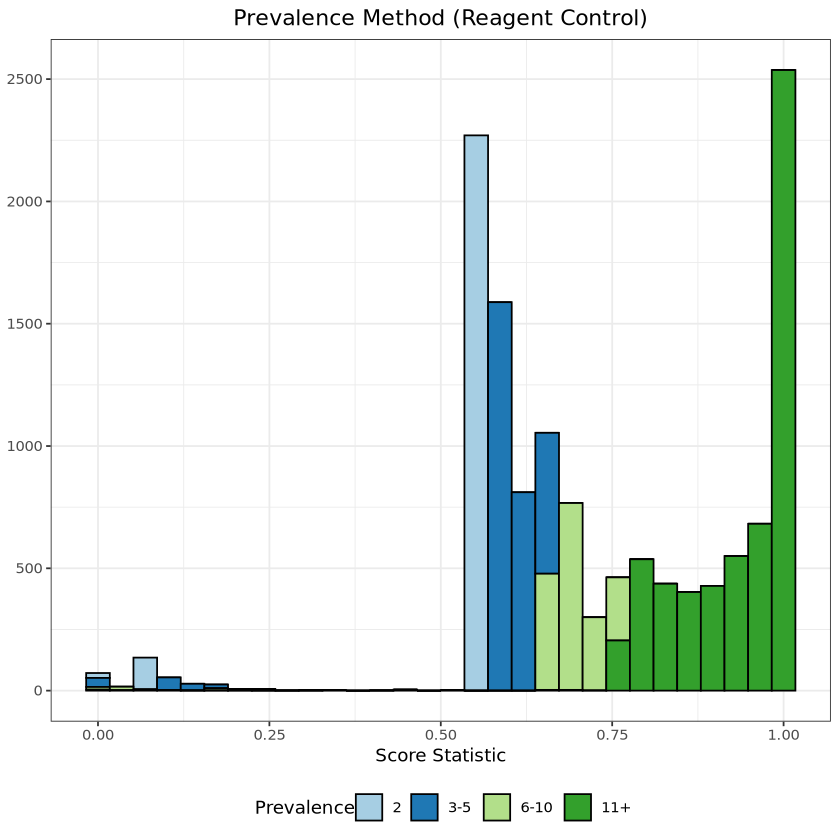

In [274]:
library(dplyr)
library(ggplot2)

# Filter to keep only taxa with prevalence > 1 and categorize prevalence into bins
contamdf.prev.reagent_controlMod <- contamdf.prev.reagent_control %>%
  filter(prev > 1) %>%
  mutate(
    Prevalence = case_when(
      prev == 2 ~ "2",
      prev > 2 & prev <= 5 ~ "3-5",
      prev >= 6 & prev <= 10 ~ "6-10",
      prev > 10 ~ "11+"
    )
  )

# Make sure the prevalence factor has the right order
contamdf.prev.reagent_controlMod$Prevalence <- factor(
  contamdf.prev.reagent_controlMod$Prevalence,
  levels = c("2", "3-5", "6-10", "11+")
)

# Define a fill color palette (modify or reuse your own palette)
scaleColorFillManualFrequency <- scale_fill_manual(
  values = c("2" = "#a6cee3", "3-5" = "#1f78b4", "6-10" = "#b2df8a", "11+" = "#33a02c")
)

# Plot histogram of the score statistic 'p' colored by prevalence category
prev.reagentScorePlot <- ggplot(contamdf.prev.reagent_controlMod, aes(x = p, fill = Prevalence)) +
  geom_histogram(bins = 30, color = "black") +
  scaleColorFillManualFrequency +
  ggtitle("Prevalence Method (Reagent Control)") +
  xlab("Score Statistic") +
  ylab("Frequency") +
  theme(
    plot.title = element_text(hjust = 0.5),
    legend.position = "bottom",
    axis.title.y = element_blank()
  )

# Show plot
prev.reagentScorePlot


In [275]:
# Select sequence names of contaminants identified by prevalence method using Reagent_Control as control
contam_seq_prev_reagent_control <- rownames(contamdf.prev.reagent_control[contamdf.prev.reagent_control$contaminant == TRUE, ])


In [276]:
# Remove Environmental_Control samples
ps.no.environment <- subset_samples(ps, Sample_Type != "Environmental_Control")

# Prune taxa with zero counts after removal
ps.no.environment <- prune_taxa(taxa_sums(ps.no.environment) > 0, ps.no.environment)

# View summary
ps.no.environment


phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 23218 taxa and 159 samples ]
sample_data() Sample Data:       [ 159 samples by 59 sample variables ]
tax_table()   Taxonomy Table:    [ 23218 taxa by 7 taxonomic ranks ]

In [277]:
# Mark negative controls (assuming 'SampleOrControl' column contains labels like "Control", "Sample", "Mock")
sample_data(ps.no.environment)$is.neg <- sample_data(ps.no.environment)$SampleOrControl == "Control"


In [278]:
library(decontam)

contamdf.prev.environment <- isContaminant(
  ps.no.environment,       # phyloseq object
  method = "prevalence",   # prevalence-based method
  neg = "is.neg",          # column indicating which samples are negative controls
  threshold = 0.5          # threshold to call a contaminant (adjust if needed)
)

# View number of contaminants identified
table(contamdf.prev.environment$contaminant)



FALSE  TRUE 
22881   337 

In [279]:
# Indices of contaminant taxa
contam_feature_indices_prev_environment <- which(contamdf.prev.environment$contaminant == TRUE)

# Names of contaminant taxa
contam_taxa_prev_environment <- taxa_names(ps.no.environment)[contam_feature_indices_prev_environment]

# Preview first few contaminant taxa names
head(contam_taxa_prev_environment)


[1] "AAACCCTGATGCAGCGACGCCGCGTGAAGGAAGAAGTATCTCGGTATGTAAACTTCTATCAGCAGGGAAGAAAATGACGGTACCTGACTAAGAAGCCCCGGCTAACTACGTGCCAGCAGCCGCGGTAATACGTAGGGGGCAAGCGTTATCCGGATTTACTGGGTGTAAAGGGAGCGTAGACGGATGGACAAGTCTGATGTGAAAGGCTGGGGCTCAACCCCGGGACTGCATTGGAAACTGCCCGTCTTGAGTGCCGGAGAGGTAAGCGGAATTCCTAGTGTAGCGGTGAAATGCGTAGATATTAGGAGGAACACCAGTGGCGAAGGCGGCTTACTGGACGGTAACTGACGTTGAGGCTCGAAAG"                         
[2] "GCGTTATCCGGAATTATTGGGCGTAAAGGGTGCGTAGGCTGTTAAATAAGTTTATGGTCTAAGTGCAATGCTCAACATTGTGATGCTATAAAAACTGTTTAGCTAGAGTAAGATAGAGGCAAGTGGAATTCCATGTGTAGTGGTAAAATGCGTAAATATATGGAGGAACACCAGTAGCGAAGGCGGCTTGCTGGGTCTTTACTGACGCTGAGGCACGAAAG"                                                                                                                                                                        
[3] "GTGGTCGGGACGATTATTGGGCCTAAAGCATCCGTAGCCGGTTCTACAAGTCTTCCGTTAAATCCACCTGCTTAACAGATGGGCTGCGGAGGATACTATGGAGCTAGGAGGCGGGAGAGGCAAGCGGTACTTAGTGGGTAGGGGTAAAATCCGTTGATCCATTGAAGACCACCAGTGGCGAAGGCGGCTTGCCAGAACGCACTCGACGGTGAGGGATGAAAG"                                                                                                                                                                       
[4] "TTATCCGGAATTATTGGGCGTAAAGGGTGCGTAGGCTGTTAAATAAGTTTATGGTCTAAGTGCAATGCTCAACATTGTGATGCTATAAAAACTGTTTAGCTAGAGTAAGATAGAGGCAAGTGGAATTCCATGTGTAGTGGTAAAATGCGTAAATATATGGAGGAACACCAGTAGCGAAGGCGGCTTGCTGGGTCTTTACTGACGCTGAGGCACGAAAGCG"                                                                                                                                                                         
[5] "AAAGCCTGACGGAGCAACGCCGCGTGAGTGATGAAGGTCTTCGGATCGTAAAACTCTGTTATTAGGGAAGAACAAATGTGTAAGTAACTATGCACGTCTTGACGGTACCTAATCAGAAAGCCACGGCTAACTACGTGCCAGCAGCCGCGGTAATACGTAGGTGGCAAGCGTTATCCGGAATTATTGGGCGTAAAGCGCGCGTAGGCGGTTTTTTAAGTCTGATGTGAAAGCCCACGGCTCAACCGTGGAGGGTCATTGGAAACTGGAAAACTTGAGTGCAGAAGAGGAAAGTGGAATTCCATGTGTAGCGGTGAAATGCGCAGAGATATGGAGGAACACCAGTGGCGAAGGCGACTTTCTGGTCTGTAACTGACGCTGATGTGCGAAAG"
[6] "AAACCCTGACCCAGCAACGCCGCGTGAAGGAAGAAGGCTTTCGGGTTGTAAACTTCTTTTAGCAGGGACGAAGAACGTGACGGTACCTGCAGAAAAAGCAACGGCTAACTACGTGCCAGCAGCCGCGGTAATACGTAGGTTGCAAGCGTTGTCCGGATTTACTGGGTGTAAAGGGCGTGTAGGCGGAGATGCAAGTCAGGAGTGAAATCCCGGGGCTCAACCCCGGAACTGCTTTTGAAACTGTATCCCTTGAGTGTCGGAGAGGCAAGCGGAATTCCTAGTGTAGCGGTGAAATGCGTAGATATTAGGAGGAACACCAGTGGCGAAGGCGGCTTGCTGGACGATAACTGACGCTGAGGCGCGAAAG"

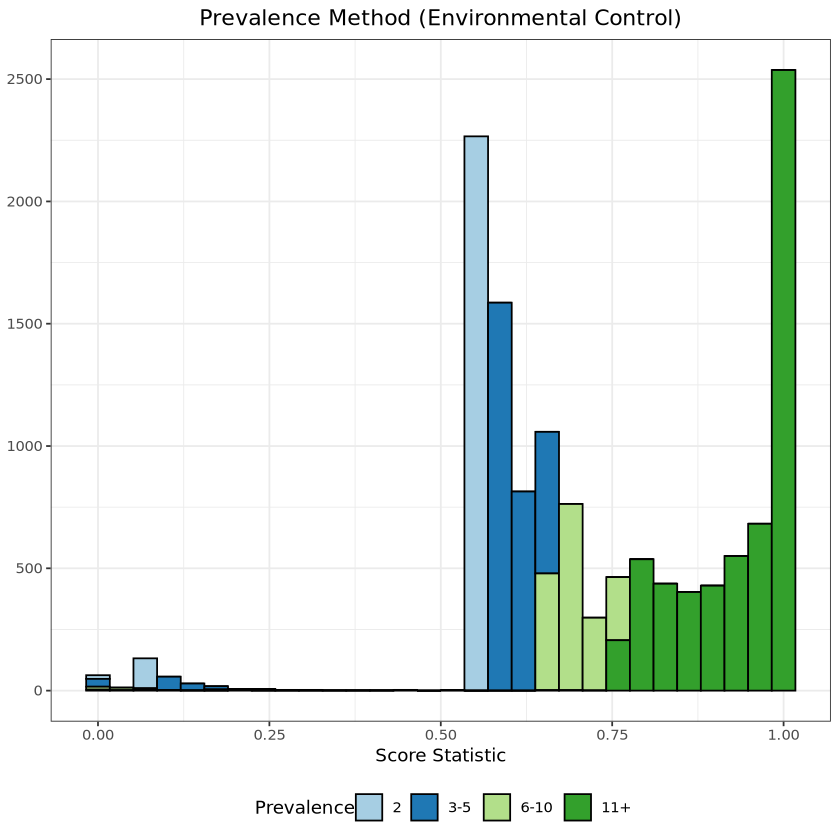

In [285]:
library(dplyr)
library(ggplot2)

contamdf.prev.environmentMod <- contamdf.prev.environment %>%
  filter(prev > 1) %>%
  mutate(
    Prevalence = case_when(
      prev == 2 ~ "2",
      prev > 2 & prev <= 5 ~ "3-5",
      prev >= 6 & prev <= 10 ~ "6-10",
      prev > 10 ~ "11+"
    )
  )

contamdf.prev.environmentMod$Prevalence <- factor(
  contamdf.prev.environmentMod$Prevalence,
  levels = c("2", "3-5", "6-10", "11+")
)

scaleColorFillManualFrequency <- scale_fill_manual(
  values = c("2" = "#a6cee3", "3-5" = "#1f78b4", "6-10" = "#b2df8a", "11+" = "#33a02c")
)

prev.environmentScorePlot <- ggplot(contamdf.prev.environmentMod, aes(x = p, fill = Prevalence)) +
  geom_histogram(bins = 30, color = "black") +
  scaleColorFillManualFrequency +
  ggtitle("Prevalence Method (Environmental Control)") +
  xlab("Score Statistic") +
  ylab("Frequency") +
  theme(
    plot.title = element_text(hjust = 0.5),
    legend.position = "bottom",
    axis.title.y = element_blank()
  )

prev.environmentScorePlot


In [325]:
# Extract contaminant taxa names
contam_taxa <- rownames(contamdf.prev.environment)[contamdf.prev.environment$contaminant == TRUE]

# Subset to Sample + Mock only
ps.sample_mock <- subset_samples(ps.no.environment, SampleOrControl %in% c("Sample", "Mock"))

# Remove contaminants from sample + mock dataset
ps.sample_mock.clean <- prune_taxa(!(taxa_names(ps.sample_mock) %in% contam_taxa), ps.sample_mock)


In [288]:
# Step 1: Remove Environmental_Control samples (so only true samples and other controls remain)
ps.no.environmental <- subset_samples(ps, Sample_Type != "Environmental_Control")

# Step 2: Prune taxa with zero counts after filtering samples
ps.no.environmental <- prune_taxa(taxa_sums(ps.no.environmental) > 0, ps.no.environmental)

# Step 3: Mark control samples (adjust the variable name to match your metadata)
sample_data(ps.no.environmental)$is.neg <- sample_data(ps.no.environmental)$SampleOrControl == "Control"

# Step 4: Run the prevalence method to detect contaminants using the environmental control samples
contamdf.prev.environmental_control <- isContaminant(
  ps.no.environmental,
  method = "prevalence",
  neg = "is.neg",
  threshold = 0.5
)

# Step 5: Now you can select the contaminant taxa sequence names
contam_seq_prev_environmental_control <- rownames(contamdf.prev.environmental_control[contamdf.prev.environmental_control$contaminant == TRUE, ])


In [370]:
path <- "/scratch/negishi/ldas/1_5_25/DADA2_outputs"
list.files(path)

[1] "dadaFs.rds"                          
 [2] "dadaRs.rds"                          
 [3] "errF.rds"                            
 [4] "errR.rds"                            
 [5] "filter_trim_summary.rds"             
 [6] "filtFs.rds"                          
 [7] "filtRs.rds"                          
 [8] "length_table.rds"                    
 [9] "mergers.rds"                         
[10] "phyloseq_true_samples.rds"           
[11] "phyloseq_WO_mock.rds"                
[12] "phyloseq.rds"                        
[13] "physeq_controls.rds"                 
[14] "physeq.rds"                          
[15] "ps_samples_including_mock.rds"       
[16] "ps_true_feces_samples.rds"           
[17] "ps.contam.rds"                       
[18] "ps.decontam.rds"                     
[19] "ps.mock.rds"                         
[20] "ps.pa.neg.rds"                       
[21] "ps.pa.pos.rds"                       
[22] "ps.pa.rds"                           
[23] "ps.sample_mock_cleaned.rds"          
[24] "ps.true_sample_cleaned.rds"          
[25] "seqtab_nochim_dim.rds"               
[26] "seqtab_nochim_ratio.rds"             
[27] "seqtab_nochim.rds"                   
[28] "seqtab.rds"                          
[29] "sink_metadata.csv"                   
[30] "sink_otus.csv"                       
[31] "source_metadata.csv"                 
[32] "source_otus.csv"                     
[33] "taxa_assignments.rds"                
[34] "taxa_species.rds"                    
[35] "taxa_wo_chloroplast_mitochondria.rds"
[36] "track_reads_summary.csv"

In [290]:
# Combine all contaminant taxa names into one unique vector
contam_seq <- unique(c(
  contam_seq_prev_extraction_control,
  contam_seq_prev_reagent_control,
  contam_seq_prev_environmental_control
  # , contam_seq_freq  # uncomment if you have frequency method contaminants
))

# Get all taxa names in the original phyloseq object
allTaxa <- taxa_names(ps)

# Keep only taxa NOT flagged as contaminants
Taxa.decontam <- allTaxa[!(allTaxa %in% contam_seq)]

# Create a cleaned phyloseq object (contaminants removed)
ps.decontam <- prune_taxa(Taxa.decontam, ps)

# Save cleaned phyloseq object
# Optional: create a phyloseq object with only contaminants
ps.contam <- prune_taxa(contam_seq, ps)

saveRDS(ps.decontam, file.path(output_dir, "ps.decontam.rds"))
### ps.decontam is the true sample after decontam (should be used for further analysis)
saveRDS(ps.contam, file.path(output_dir, "ps.contam.rds"))


Attaching package: ‘tibble’


The following object is masked from ‘package:ShortRead’:

    view


`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_cor()`).”
Warning message:
“Removed 2 rows containing non-finite outside the scale range
(`stat_regline_equation()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”


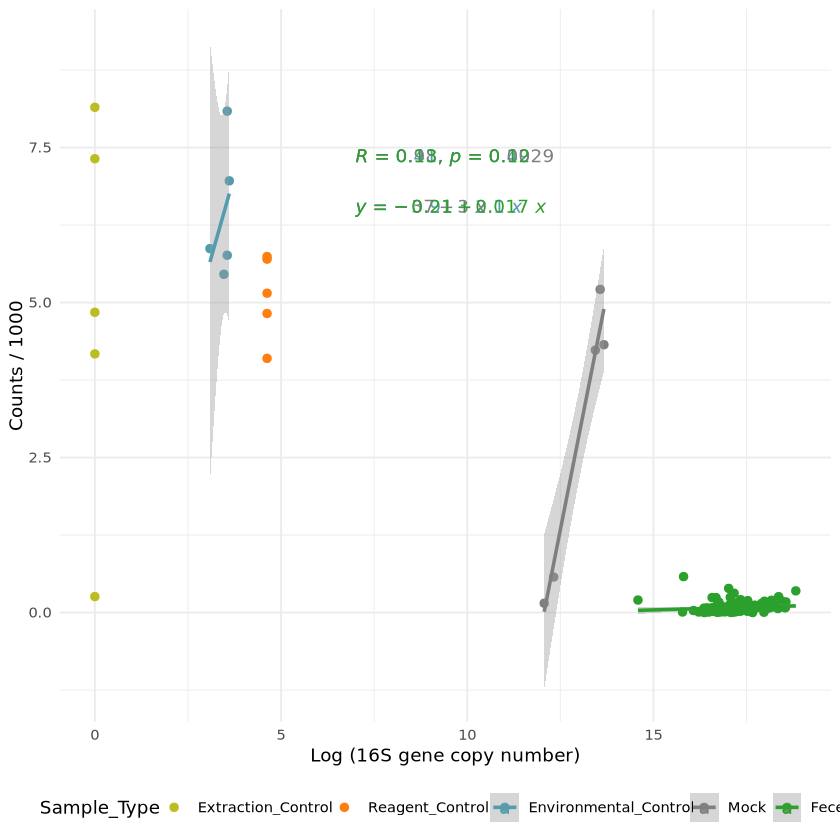

In [292]:
library(dplyr)
library(tibble)

# Extract metadata from phyloseq and add SampleID column from rownames
metadata <- data.frame(sample_data(ps.contam)) %>%
  rownames_to_column(var = "SampleID")

# Get counts (sum of sequences per sample) and add SampleID column
counts <- data.frame(counts = sample_sums(ps.contam)) %>%
  rownames_to_column(var = "SampleID")

# Join counts into metadata by SampleID (the sample names)
metadata <- left_join(metadata, counts, by = "SampleID")

# Now you can filter by Sample_Type (your existing column)
SAMPLE_TYPES <- c("Extraction_Control", "Reagent_Control", "Environmental_Control", "Mock", "Feces")

metadata <- metadata %>% filter(Sample_Type %in% SAMPLE_TYPES)

# Convert Sample_Type to factor for plotting order and colors
metadata$Sample_Type <- factor(metadata$Sample_Type, levels = SAMPLE_TYPES)

# Define your color palette (adjust colors as you like)
my_palette <- c(
  "Extraction_Control" = "#bcbd22",
  "Reagent_Control" = "#ff7f0e",
  "Environmental_Control" = "#539caf",
  "Mock" = "#7f7f7f",
  "Feces" = "#2ca02c"
)

# Plot log 16S gene copy number vs abundance (counts), colored by Sample_Type
library(ggplot2)
library(ggpubr)  # for stat_cor and stat_regline_equation if you want

ggplot(metadata, aes(x = log(CopyNumber), y = counts / 1000, color = Sample_Type)) +
  geom_point(size = 2) +
  geom_smooth(method = "lm", se = TRUE) +
  stat_cor(label.x = 7, label.y = max(metadata$counts / 1000, na.rm = TRUE) * 0.9) +
  stat_regline_equation(label.x = 7, label.y = max(metadata$counts / 1000, na.rm = TRUE) * 0.8) +
  xlab("Log (16S gene copy number)") +
  ylab("Counts / 1000") +
  scale_color_manual(values = my_palette) +
  theme_minimal() +
  theme(legend.position = "bottom")


`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_cor()`).”
Warning message:
“Removed 2 rows containing non-finite outside the scale range
(`stat_regline_equation()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”


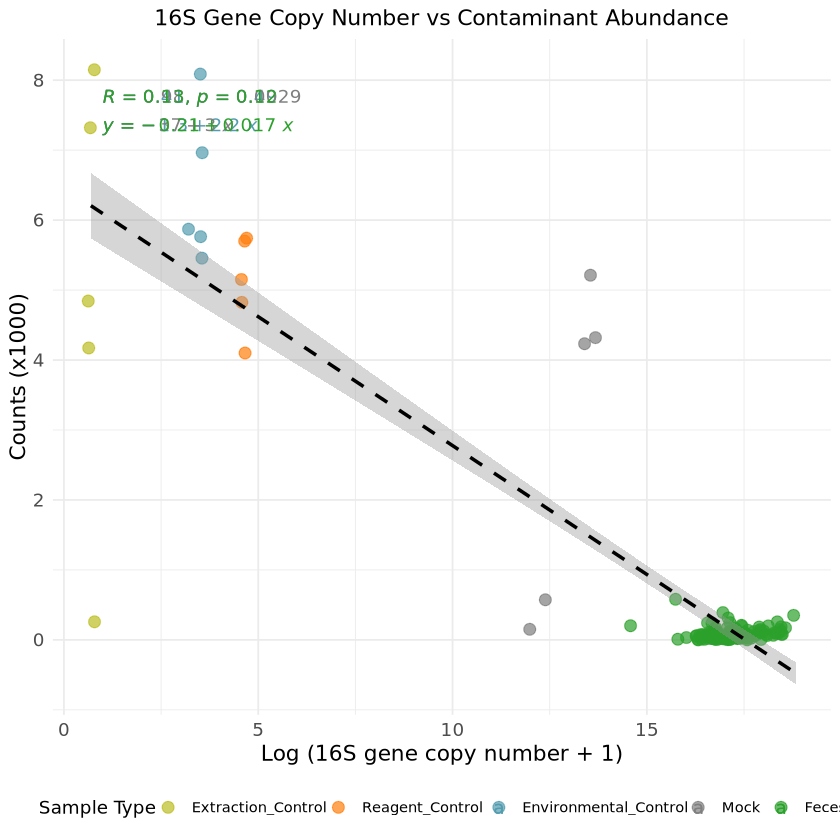

In [293]:
library(ggplot2)
library(ggpubr)

ggplot(metadata, aes(x = log(CopyNumber + 1), y = counts / 1000, color = Sample_Type)) +
  geom_point(size = 3, alpha = 0.7, position = position_jitter(width = 0.1, height = 0)) +
  geom_smooth(method = "lm", se = TRUE, color = "black", linetype = "dashed") +
  stat_cor(label.x = 1, label.y = max(metadata$counts / 1000, na.rm = TRUE) * 0.95) +
  stat_regline_equation(label.x = 1, label.y = max(metadata$counts / 1000, na.rm = TRUE) * 0.9) +
  labs(
    title = "16S Gene Copy Number vs Contaminant Abundance",
    x = "Log (16S gene copy number + 1)",
    y = "Counts (x1000)",
    color = "Sample Type"
  ) +
  scale_color_manual(values = my_palette) +
  theme_minimal() +
  theme(
    legend.position = "bottom",
    plot.title = element_text(hjust = 0.5),
    axis.text = element_text(size = 11),
    axis.title = element_text(size = 13)
  )


In [304]:
library(RColorBrewer)

# Get unique genera in your data
unique_genera <- unique(melt.contam$Genus)

# Create a custom palette with as many colors as unique genera
my_palette <- colorRampPalette(brewer.pal(12, "Paired"))(length(unique_genera))

# Name the palette with the genera names for consistent mapping
names(my_palette) <- unique_genera
p.contam <- ggplot(melt.contam, aes(x = X.SampleID, y = Abundance, fill = Genus)) +
  geom_bar(stat = "identity") +
  facet_wrap(~ Type, nrow = 1, scales = "free_x") +
  theme_bw() +
  theme(
    axis.title.x = element_blank(),
    axis.text.x = element_blank(),
    axis.ticks.x = element_blank(),
    legend.position = "right",
    panel.grid.major.x = element_blank()
  ) +
  scale_fill_manual(values = my_palette)

print(p.contam)


ERROR: [1m[33mError[39m in `combine_vars()`:[22m
[1m[22m[33m![39m At least one layer must contain all faceting variables: `Type`
[31m✖[39m Plot is missing `Type`
[31m✖[39m Layer 1 is missing `Type`


In [371]:
# Keep only true fecal samples
ps.true_samples_only <- subset_samples(ps.true_samples_ctrl, Sample_Type == "Feces")

# Now remove contaminants only from these true samples
ps.true_sample_cleaned <- prune_taxa(
  !(taxa_names(ps.true_samples_only) %in% contam_seq_prev_true_samples),
  ps.true_samples_only
)


In [372]:
saveRDS(ps.true_sample_cleaned, file.path(output_dir, "ps.true_sample_cleaned.rds"))

In [308]:
#### SourceTracker 
library (dplyr)
library (phyloseq)
library (vegan)
library (ggplot2)
library (MicrobiotaProcess)
library (tidyr)
library (data.table)
library (pairwiseAdonis)
library (microbiome)
library (patchwork)

ERROR: Error in library(MicrobiotaProcess): there is no package called ‘MicrobiotaProcess’


In [310]:
path.rds 
path.figures 

[1] "/scratch/negishi/ldas/1_5_25/DADA2_outputs"

[1] "/scratch/negishi/ldas/1_5_25/DADA2_outputs"

In [311]:
ps.decontam <- readRDS(file.path(path.rds,
"ps.decontam.rds"
))

In [312]:
metadata <- sample_data(ps.decontam)
# make metadata files that only have samples.
metadata <- data.frame(metadata)

In [314]:
# Define source types excluding Mock
ps.source <- subset_samples(ps.decontam, Sample_Type %in% c("Reagent_Control", "Extraction_Control", "Environmental_Control"))

# Sinks remain the same
ps.sink <- subset_samples(ps.decontam, Sample_Type == "Feces")


In [333]:
# Extract OTU tables (samples x taxa)
otus.source <- as.matrix(otu_table(ps.source))
otus.sink <- as.matrix(otu_table(ps.sink))

# Extract metadata (make sure rownames are sample IDs)
meta.source <- data.frame(sample_data(ps.source))
meta.sink <- data.frame(sample_data(ps.sink))


In [334]:
stopifnot(all(rownames(otus.source) == rownames(meta.source)))
stopifnot(all(rownames(otus.sink) == rownames(meta.sink)))


In [335]:
common_taxa <- intersect(colnames(otus.source), colnames(otus.sink))
otus.source <- otus.source[, common_taxa, drop = FALSE]
otus.sink <- otus.sink[, common_taxa, drop = FALSE]


In [336]:
write.csv(otus.source, file = file.path(output_dir, "source_otus.csv"), quote = FALSE)
write.csv(otus.sink, file = file.path(output_dir, "sink_otus.csv"), quote = FALSE)
write.csv(meta.source, file = file.path(output_dir, "source_metadata.csv"), quote = FALSE)
write.csv(meta.sink, file = file.path(output_dir, "sink_metadata.csv"), quote = FALSE)


In [340]:
# Extract metadata from phyloseq object
metadata.qm <- data.frame(sample_data(ps.decontam))

# Add SourceSink column
metadata.qm <- metadata.qm %>% 
  mutate(SourceSink = case_when(
    Sample_Type %in% c("Reagent_Control", "Extraction_Control", "Environmental_Control") ~ "source",
    Sample_Type == "Feces" ~ "sink"
  ))

# Extract OTU table
otus.qm <- as.matrix(otu_table(ps.decontam))

# Now get indices
train_qm_ix <- which(metadata.qm$SourceSink == 'source')
test_qm_ix <- which(metadata.qm$SourceSink == 'sink')

# Check sink OTU table dimensions
dim(otus.qm[test_qm_ix, ])


[1]   142 23517

In [353]:
otus_train <- otus.qm[train_qm_samples, , drop = FALSE]
otus_test <- otus.qm[test_qm_samples, , drop = FALSE]

dim(otus_train)
dim(otus_test)


ERROR: Error in as(x, "matrix")[i, j, drop = FALSE]: subscript out of bounds


In [357]:
# Remove samples with NA in SourceSink (NAs are the Mock)
metadata.qm.filtered <- metadata.qm[!is.na(metadata.qm$SourceSink), ]

# Now get train and test samples only from filtered metadata
train_qm_samples <- rownames(metadata.qm.filtered)[metadata.qm.filtered$SourceSink == 'source']
test_qm_samples <- rownames(metadata.qm.filtered)[metadata.qm.filtered$SourceSink == 'sink']
missing_train <- train_qm_samples[!train_qm_samples %in% rownames(otus.qm)]
missing_test <- test_qm_samples[!test_qm_samples %in% rownames(otus.qm)]

print(missing_train)
print(missing_test)


character(0)
character(0)


In [360]:
otus_train <- otus.qm[train_qm_samples, , drop = FALSE]
otus_test <- otus.qm[test_qm_samples, , drop = FALSE]


In [363]:
install.packages("RcppTOML")

Warning message in install.packages("RcppTOML"):
“installation of package ‘RcppTOML’ had non-zero exit status”
Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



In [364]:
install.packages("reticulate")  # Run this only once if not already installed

also installing the dependency ‘RcppTOML’


Warning message in install.packages("reticulate"):
“installation of package ‘RcppTOML’ had non-zero exit status”
Warning message in install.packages("reticulate"):
“installation of package ‘reticulate’ had non-zero exit status”
Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



In [361]:
# Create and train SourceTracker model
source_tracker <- st$SourceTracker(alpha1=0.001, alpha2=0.1, rarefaction_depth=NULL, source_rarefaction=False)
source_tracker$fit(otus_train, metadata.qm.filtered$SourceSink[rownames(otus_train)])
# Predict source proportions for the sink OTUs
results <- source_tracker$predict(otus_test)
# Convert results to a data frame
results_df <- as.data.frame(results)
results_df$SampleID <- rownames(otus_test)

# Melt for ggplot2
library(reshape2)
results_melt <- melt(results_df, id.vars = "SampleID", variable.name = "Source", value.name = "Proportion")

# Plot
library(ggplot2)
ggplot(results_melt, aes(x = SampleID, y = Proportion, fill = Source)) +
  geom_bar(stat = "identity") +
  theme_bw() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1, size = 6)) +
  labs(title = "SourceTracker Results", y = "Source Contribution", x = "Sink Sample")
write.csv(results_df, file = file.path("your_output_dir", "sourcetracker_results.csv"), row.names = FALSE)


ERROR: Error: object 'st' not found


In [ ]:
# ### Source tracker #####
#After training
source_tracker <- st$SourceTracker(alpha1=0.001, alpha2=0.1, source_rarefaction=FALSE)
source_tracker$fit(otus_train, source_labels)

# Predict on sink samples
predictions <- source_tracker$predict(otus_test)
head(rownames(predictions))
head(sample_names(ps.decontam))
#Renaming if needed 
# Convert to data.frame
pred_df <- as.data.frame(predictions)

# Add to sample_data
sample_data(ps.decontam) <- cbind(sample_data(ps.decontam), pred_df)
rownames(predictions) <- test_qm_samples  # if these are your sink sample names
# Create a new phyloseq object with just sink samples and SourceTracker predictions
ps.sink.st <- subset_samples(ps.decontam, Sample_Type == "Feces")
# Visualization
library(ggplot2)
source_names <- colnames(pred_df)

plot_data <- sample_data(ps.sink.st) %>%
  as.data.frame() %>%
  select(all_of(source_names)) %>%
  mutate(SampleID = rownames(.)) %>%
  pivot_longer(cols = -SampleID, names_to = "Source", values_to = "Proportion")

ggplot(plot_data, aes(x = SampleID, y = Proportion, fill = Source)) +
  geom_bar(stat = "identity") +
  theme_bw() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))


In [ ]:
##### Alpha Diversity
# Define the sample types present in your dataset
SAMPLE_TYPES <- c(
  "Feces",
  "Reagent_Control",
  "Extraction_Control",
  "Environmental_Control",
  "Mock"
)

# Define custom fill colors for each sample type
ColorFillManual <- c(
  "Feces" = "#1f77b4",                # Blue
  "Reagent_Control" = "#ff7f0e",      # Orange
  "Extraction_Control" = "#2ca02c",   # Green
  "Environmental_Control" = "#d62728",# Red
  "Mock" = "#7f7f7f"                  # Gray
)


In [ ]:
# Load phyloseq object
ps <- readRDS(file.path(path.rds,
"phyloseq.rds"
))print(ps)

In [ ]:
# Convert sample_data to data frame
metadata <- sample_data(ps) %>% data.frame()

# Ensure 'Type' column is a factor with specified levels
metadata$Type <- factor(metadata$Type, levels = Sample_Type)

# Get sequencing depth (sample sums)
depth <- data.frame(SampleID = names(sample_sums(ps)), 
                    Depth = sample_sums(ps))

# Merge depth into metadata using SampleID
metadata$SampleID <- rownames(metadata)  # Ensure there's a matching ID column
metadata <- left_join(metadata, depth, by = c("SampleID" = "SampleID"))


In [ ]:
# Estimate alpha diversity metrics
tabAlphaDiv <- phyloseq::estimate_richness(ps, measures = c("Observed", "Shannon", "InvSimpson"))

# Add sample ID as a column for merging
tabAlphaDiv$SampleID <- rownames(tabAlphaDiv)

# Ensure metadata has a matching SampleID column
metadata$SampleID <- rownames(metadata)

# Join the alpha diversity metrics with metadata
metadata <- metadata %>% left_join(tabAlphaDiv, by = "SampleID")


In [ ]:
library(ggplot2)
library(gghalves)

p.richness <- metadata %>%
  ggplot(aes(x = Type, y = Observed, fill = Type, color = Type)) +
  
  # Custom fill and color
  scale_color_manual(values = ColorFillManual) +
  scale_fill_manual(values = ColorFillManual) +
  
  # Half violin plot on the right
  geom_half_violin(
    position = position_nudge(x = 0.15, y = 0),
    color = NA,
    alpha = 0.6,
    scale = "width",
    trim = FALSE,
    side = "r"
  ) +
  
  # Half dot plot on the left
  geom_half_point(
    position = position_nudge(x = -0.4),
    size = 2,
    range_scale = 0.4,
    alpha = 0.6
  ) +
  
  # Boxplot in the center
  geom_boxplot(
    width = 0.2,
    outlier.shape = NA,
    alpha = 0.6
  ) +
  
  xlab("Sample Type") +
  ylab("Richness") +
  labs(title = "Before decontam") +
  theme_bw() +
  theme(
    legend.position = "none",
    plot.title = element_text(hjust = 0.5),
    axis.text.x = element_blank(),
    axis.title.x = element_blank(),
    axis.title.y = element_text(size = 10)
  ) +
  ylim(0, 2000)

print(p.richness)


In [ ]:
# Generalized Linear Model for Observed richness by Sample Type
glm.richness <- glm(Observed ~ Type, data = metadata)

# Type III ANOVA (requires car package)
car::Anova(glm.richness, type = "III")

# Post-hoc pairwise comparisons with emmeans
emmeans.richness <- emmeans::emmeans(glm.richness, pairwise ~ Type)

# Extract pairwise contrasts
richness.contra <- as.data.frame(emmeans.richness$contrasts)

# Extract group means with confidence intervals
richness.mean <- as.data.frame(emmeans.richness$emmeans)


In [ ]:
p.shannon <- metadata %>%
  ggplot(aes(x = Type, y = Shannon, fill = Type, color = Type)) +
  scale_color_manual(values = ColorFillManual) +
  scale_fill_manual(values = ColorFillManual) +
  geom_half_violin(
    position = position_nudge(x = 0.15, y = 0),
    color = NA,
    alpha = 0.6,
    scale = "width",
    trim = FALSE,
    side = "R"
  ) +
  geom_half_point(
    position = position_nudge(x = -0.4),
    size = 2,
    range_scale = 0.4,
    alpha = 0.6
  ) +
  geom_boxplot(
    width = 0.2,
    outlier.shape = NA,
    alpha = 0.6
  ) +
  xlab("Sample Type") +
  ylab("Shannon Diversity") +
  theme_bw() +
  theme(
    legend.position = "none",
    axis.text.x = element_text(angle = 45, hjust = 1),
    axis.title.x = element_blank(),
    axis.title.y = element_text(size = 10)
  ) +
  coord_cartesian(ylim = c(0.9, 7.1)) # zoom without cutting points

p.shannon


In [ ]:
# Statistical Analysis
head(metadata)

glm.shannon <- glm(Shannon ~ Type, data = metadata)
summary(glm.shannon)

car::Anova(glm.shannon)  # Type III Anova by default, but can specify if needed

emmeans.shannon <- emmeans::emmeans(glm.shannon, pairwise ~ Type)

# Fix typo: data.frame instead of data.frames
shannon.contra <- emmeans.shannon$contrasts %>% data.frame()
shannon.mean <- emmeans.shannon$emmeans %>% data.frame()


In [365]:
ps.true_sample_cleaned <- readRDS(file.path(output_dir, "ps.true_sample_cleaned.rds"))
### its after decontam step

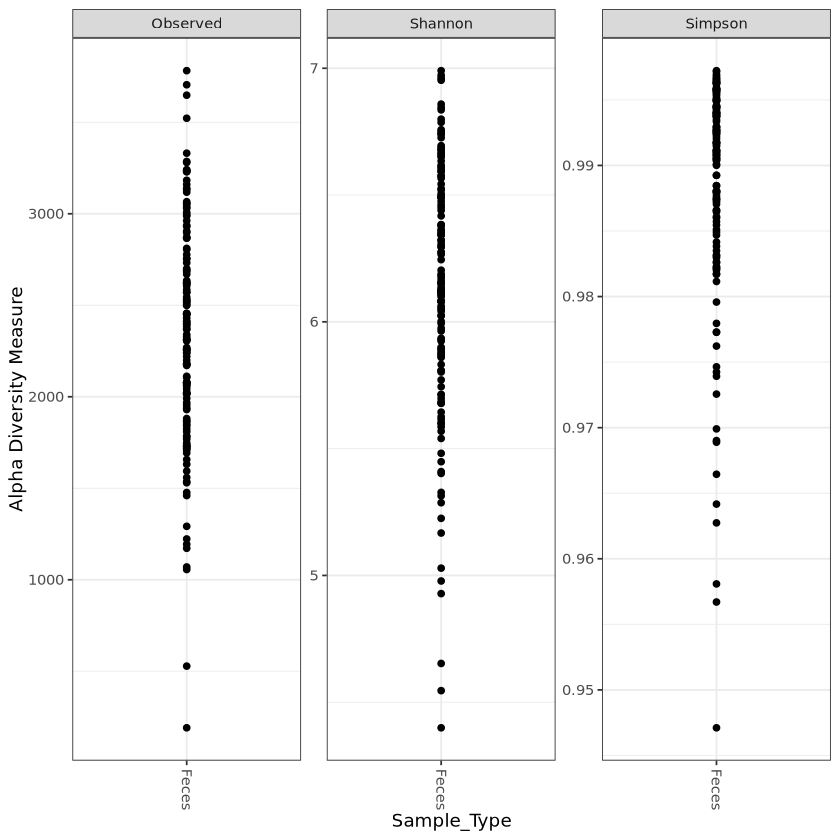

In [375]:
ps.true_sample_cleaned <- readRDS(file.path(output_dir, "ps.true_sample_cleaned.rds"))

# Now you can plot richness:
plot_richness(ps.true_sample_cleaned, x = "Sample_Type", measures = c("Shannon", "Simpson", "Observed"))


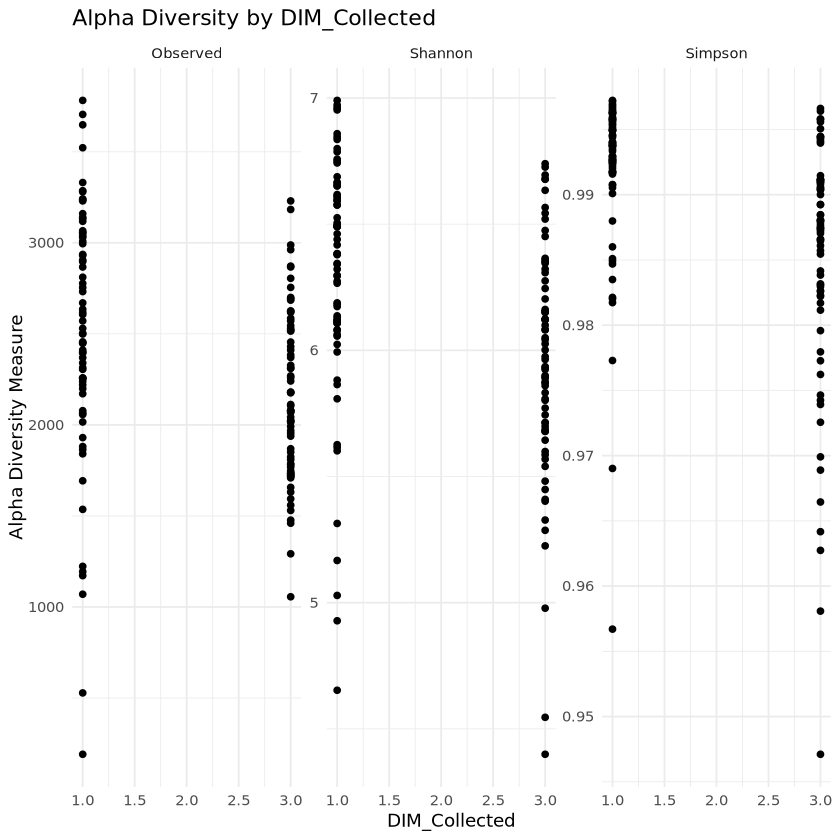

In [376]:
#### Alpha Diversity by DIM_Collected
plot_richness(ps.true_sample_cleaned, x = "DIM_Collected", 
              measures = c("Shannon", "Simpson", "Observed")) +
  theme_minimal() +
  ggtitle("Alpha Diversity by DIM_Collected")


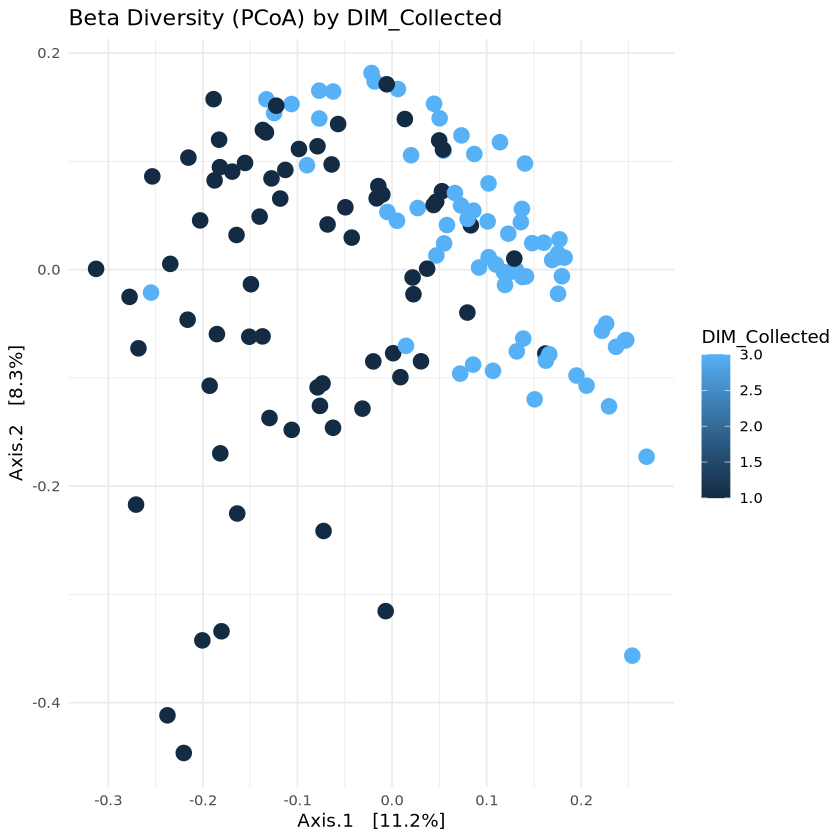

In [381]:
#### Beta Diversity by DIM_Collected
ord <- ordinate(ps.true_sample_cleaned, method = "PCoA", distance = "bray")
plot_ordination(ps.true_sample_cleaned, ord, color = "DIM_Collected") +
  geom_point(size = 4) +
  theme_minimal() +
  ggtitle("Beta Diversity (PCoA) by DIM_Collected")


In [382]:
#### PERMANOVA: Test for Significant Differences
library(vegan)

# Calculate distance matrix
dist <- phyloseq::distance(ps.true_sample_cleaned, method = "bray")

# Extract sample metadata
metadata <- as(sample_data(ps.true_sample_cleaned), "data.frame")

# Run PERMANOVA
adonis2(dist ~ DIM_Collected, data = metadata)


,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Model,1,1.621965,0.06482967,9.705348,0.001
Residual,140,23.396900,0.93517033,NA,NA
Total,141,25.018864,1.00000000,NA,NA


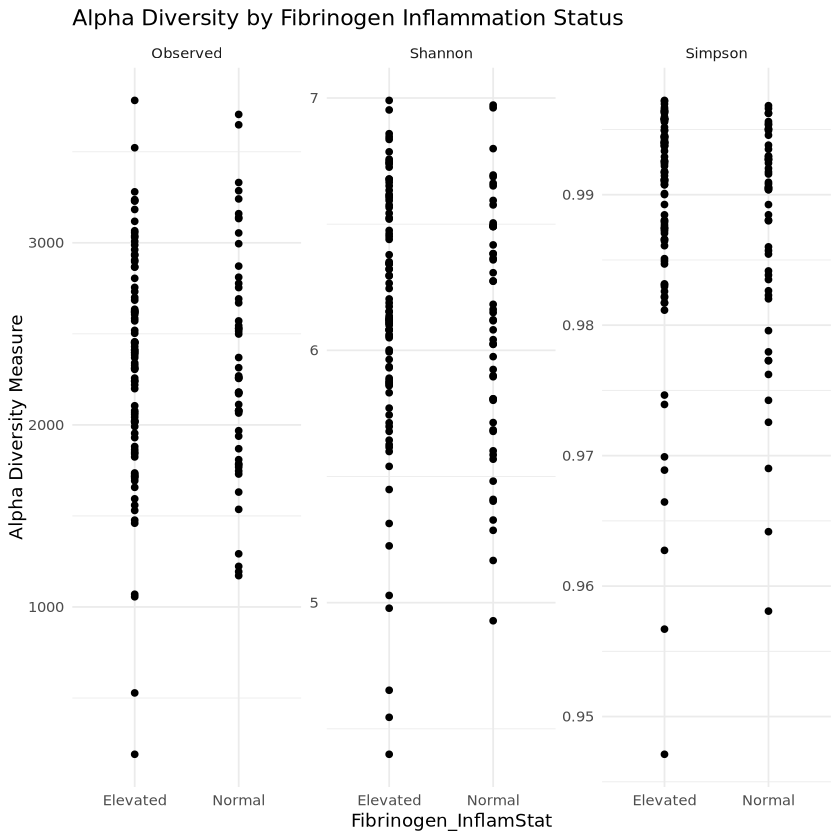

In [377]:
#### Alpha Diversity by Inflammation Status
plot_richness(ps.true_sample_cleaned, 
              x = "Fibrinogen_InflamStat", 
              measures = c("Shannon", "Simpson", "Observed")) +
  theme_minimal() +
  ggtitle("Alpha Diversity by Fibrinogen Inflammation Status")


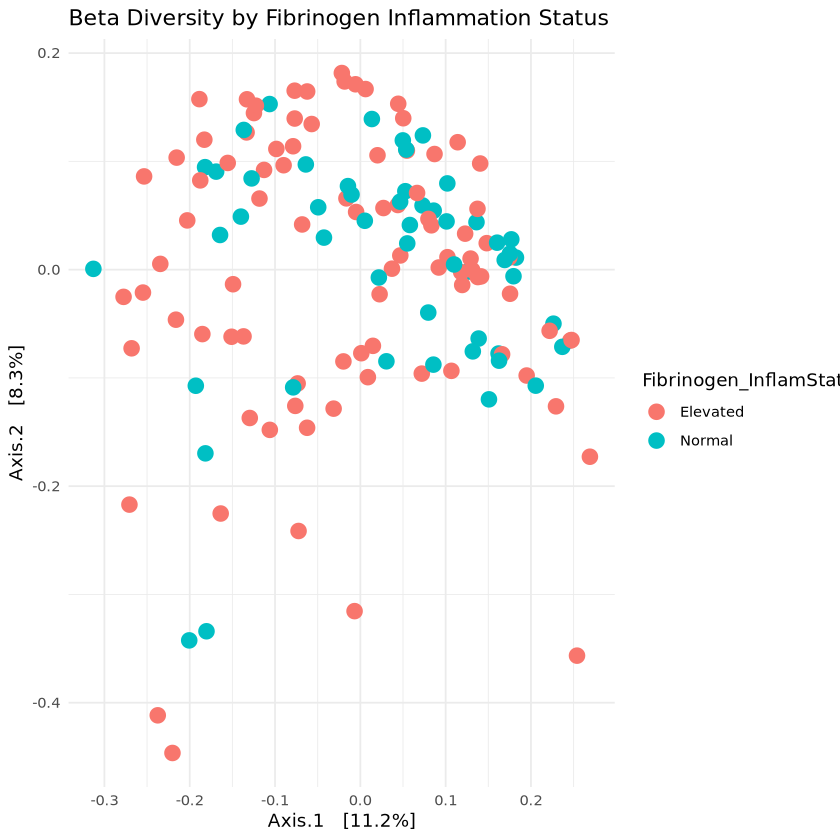

In [378]:
#### Beta Diversity (PCoA) by Inflammation Status
ord <- ordinate(ps.true_sample_cleaned, method = "PCoA", distance = "bray")

plot_ordination(ps.true_sample_cleaned, ord, color = "Fibrinogen_InflamStat") +
  geom_point(size = 4) +
  theme_minimal() +
  ggtitle("Beta Diversity by Fibrinogen Inflammation Status")


In [379]:
#### PERMANOVA: Test for Significant Differences
library(vegan)

# Distance matrix
dist <- phyloseq::distance(ps.true_sample_cleaned, method = "bray")

# Metadata
metadata <- as(sample_data(ps.true_sample_cleaned), "data.frame")

# PERMANOVA
adonis2(dist ~ Fibrinogen_InflamStat, data = metadata)


,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Model,1,0.2315955,0.009256835,1.308065,0.097
Residual,140,24.7872687,0.990743165,NA,NA
Total,141,25.0188642,1.000000000,NA,NA


In [383]:
# Agglomerate at Genus level (or any desired rank)
ps_genus <- tax_glom(ps.true_sample_cleaned, taxrank = "Genus")



Attaching package: ‘reshape2’


The following object is masked from ‘package:tidyr’:

    smiths




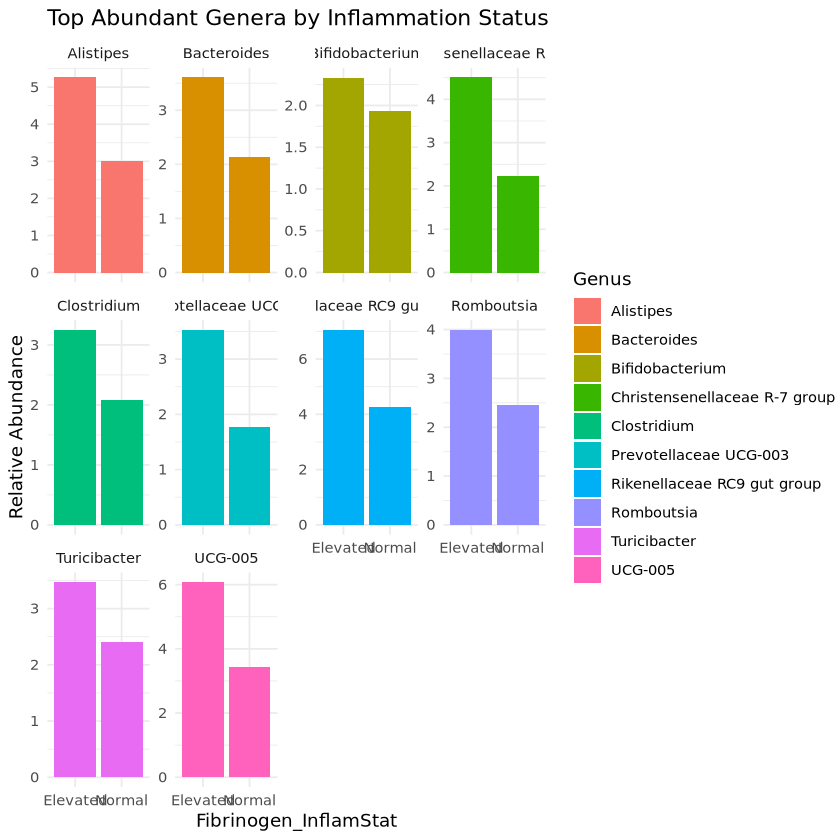

In [386]:
ps_genus_rel <- transform_sample_counts(ps_genus, function(x) x / sum(x))
ps.rel <- transform_sample_counts(ps.true_sample_cleaned, function(x) x / sum(x))
ps.genus <- tax_glom(ps.rel, taxrank = "Genus")  # Use "Family", "Phylum", etc., if needed
library(phyloseq)
library(reshape2)

data.genus <- psmelt(ps.genus)
library(dplyr)

top_taxa <- data.genus %>%
  group_by(Genus) %>%
  summarise(mean_abundance = mean(Abundance)) %>%
  arrange(desc(mean_abundance)) %>%
  slice_head(n = 10) %>%
  pull(Genus)
data.top <- data.genus %>% filter(Genus %in% top_taxa)

ggplot(data.top, aes(x = Fibrinogen_InflamStat, y = Abundance, fill = Genus)) +
  geom_bar(stat = "identity", position = "stack") +
  facet_wrap(~Genus, scales = "free_y") +
  theme_minimal() +
  ylab("Relative Abundance") +
  ggtitle("Top Abundant Genera by Inflammation Status")


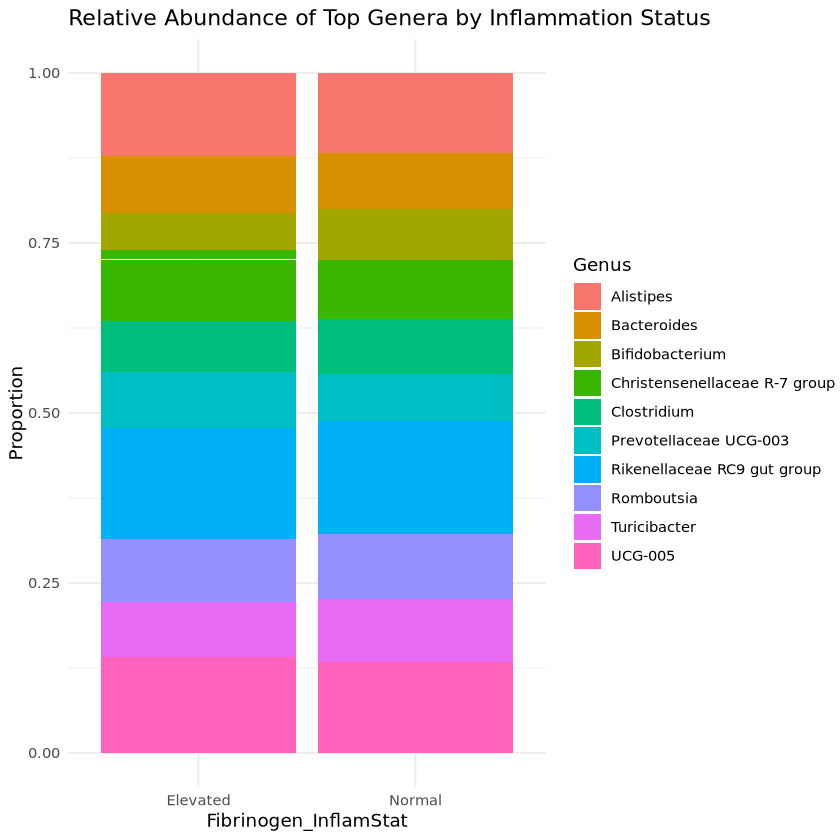

In [387]:
ggplot(data.top, aes(x = Fibrinogen_InflamStat, y = Abundance, fill = Genus)) +
  geom_bar(stat = "identity", position = "fill") +
  theme_minimal() +
  ylab("Proportion") +
  ggtitle("Relative Abundance of Top Genera by Inflammation Status")


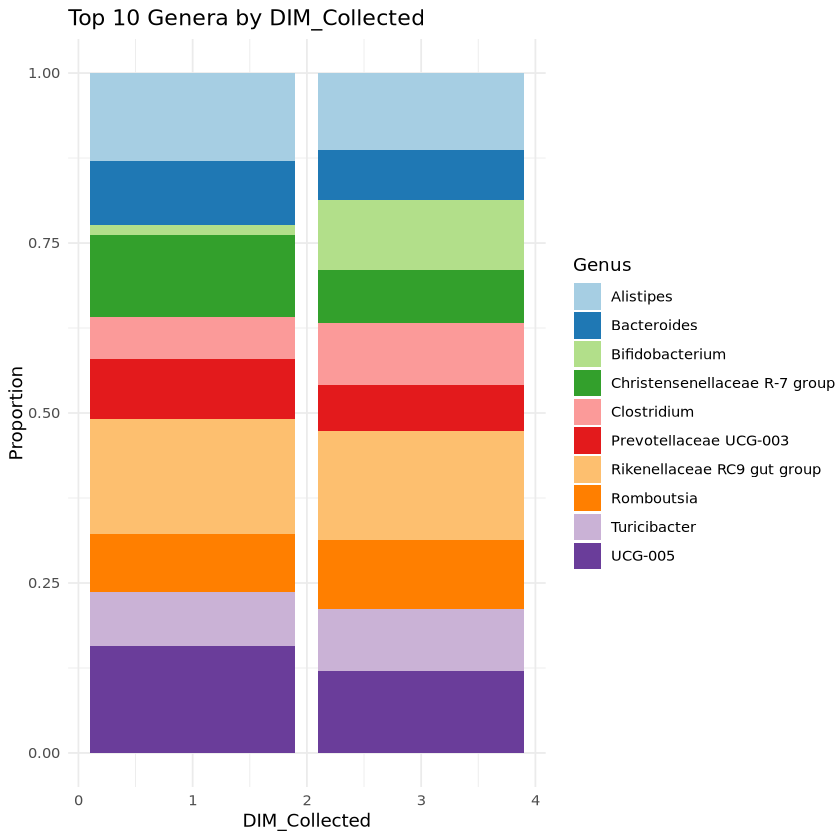

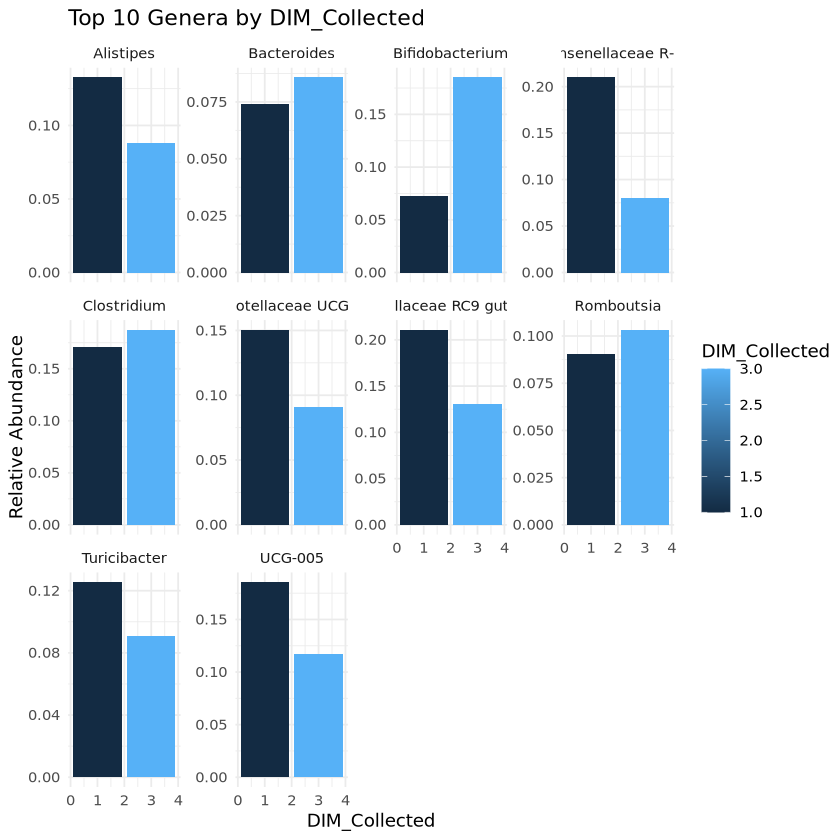

In [388]:
ps.rel <- transform_sample_counts(ps.true_sample_cleaned, function(x) x / sum(x))
ps.genus <- tax_glom(ps.rel, taxrank = "Genus")
data.genus <- psmelt(ps.genus)
library(dplyr)

top_taxa <- data.genus %>%
  group_by(Genus) %>%
  summarise(mean_abundance = mean(Abundance)) %>%
  arrange(desc(mean_abundance)) %>%
  slice_head(n = 10) %>%
  pull(Genus)
data.top <- data.genus %>% filter(Genus %in% top_taxa)

library(ggplot2)

ggplot(data.top, aes(x = DIM_Collected, y = Abundance, fill = Genus)) +
  geom_bar(stat = "identity", position = "fill") +
  theme_minimal() +
  ylab("Proportion") +
  ggtitle("Top 10 Genera by DIM_Collected") +
  scale_fill_brewer(palette = "Paired")

                                  ggplot(data.top, aes(x = DIM_Collected, y = Abundance, fill = DIM_Collected)) +
  geom_bar(stat = "identity", position = "dodge") +
  facet_wrap(~ Genus, scales = "free_y") +
  theme_minimal() +
  ylab("Relative Abundance") +
  ggtitle("Top 10 Genera by DIM_Collected")


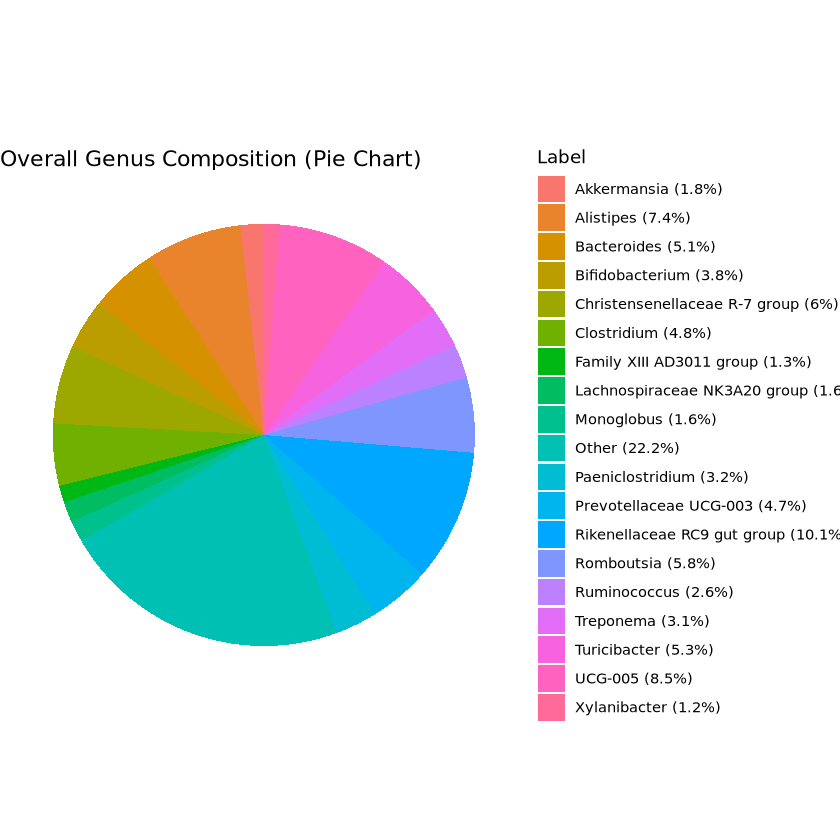

In [391]:
# Aggregate at Genus level
ps.genus <- tax_glom(ps.rel, taxrank = "Genus")
genus_data <- psmelt(ps.genus)

# Summarize total abundance per genus
library(dplyr)

genus_summary <- genus_data %>%
  group_by(Genus) %>%
  summarise(Abundance = sum(Abundance)) %>%
  mutate(Percent = 100 * Abundance / sum(Abundance)) %>%
  mutate(Genus = ifelse(Percent < 1, "Other", as.character(Genus))) %>%
  group_by(Genus) %>%
  summarise(Abundance = sum(Abundance)) %>%
  mutate(Percent = 100 * Abundance / sum(Abundance),
         Label = paste0(Genus, " (", round(Percent, 1), "%)"))

# Pie chart
library(ggplot2)

ggplot(genus_summary, aes(x = "", y = Abundance, fill = Label)) +
  geom_bar(stat = "identity", width = 1) +
  coord_polar(theta = "y") +
  theme_void() +
  ggtitle("Overall Genus Composition (Pie Chart)") +
  theme(legend.position = "right")


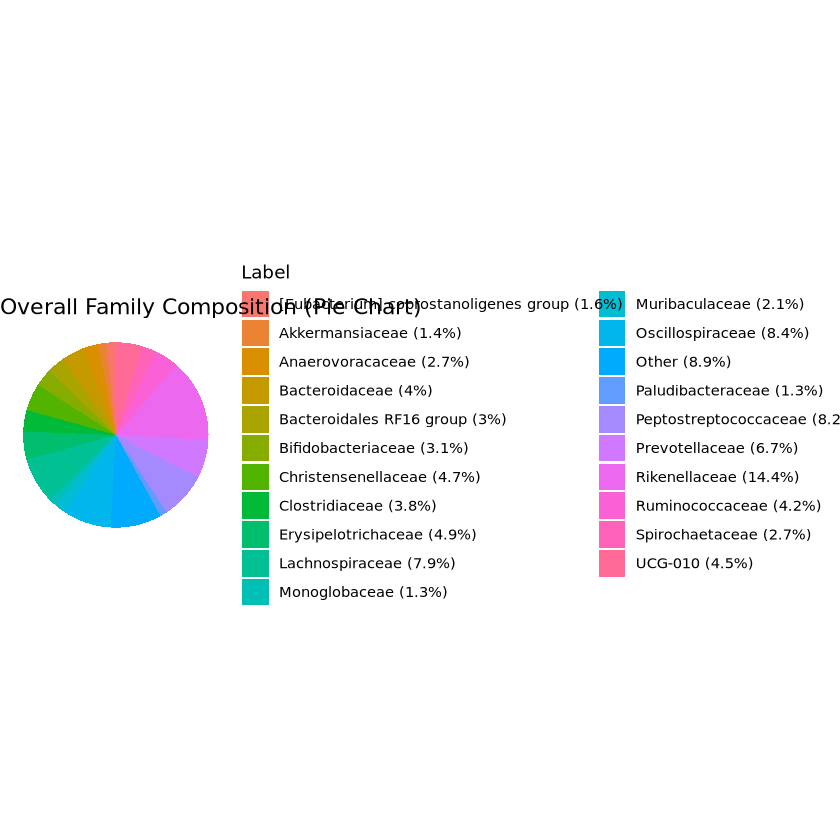

In [392]:
# Aggregate at Family level
ps.family <- tax_glom(ps.rel, taxrank = "Family")
family_data <- psmelt(ps.family)

# Summarize total abundance per family
family_summary <- family_data %>%
  group_by(Family) %>%
  summarise(Abundance = sum(Abundance)) %>%
  mutate(Percent = 100 * Abundance / sum(Abundance)) %>%
  mutate(Family = ifelse(Percent < 1, "Other", as.character(Family))) %>%
  group_by(Family) %>%
  summarise(Abundance = sum(Abundance)) %>%
  mutate(Percent = 100 * Abundance / sum(Abundance),
         Label = paste0(Family, " (", round(Percent, 1), "%)"))

# Pie chart
ggplot(family_summary, aes(x = "", y = Abundance, fill = Label)) +
  geom_bar(stat = "identity", width = 1) +
  coord_polar(theta = "y") +
  theme_void() +
  ggtitle("Overall Family Composition (Pie Chart)") +
  theme(legend.position = "right")


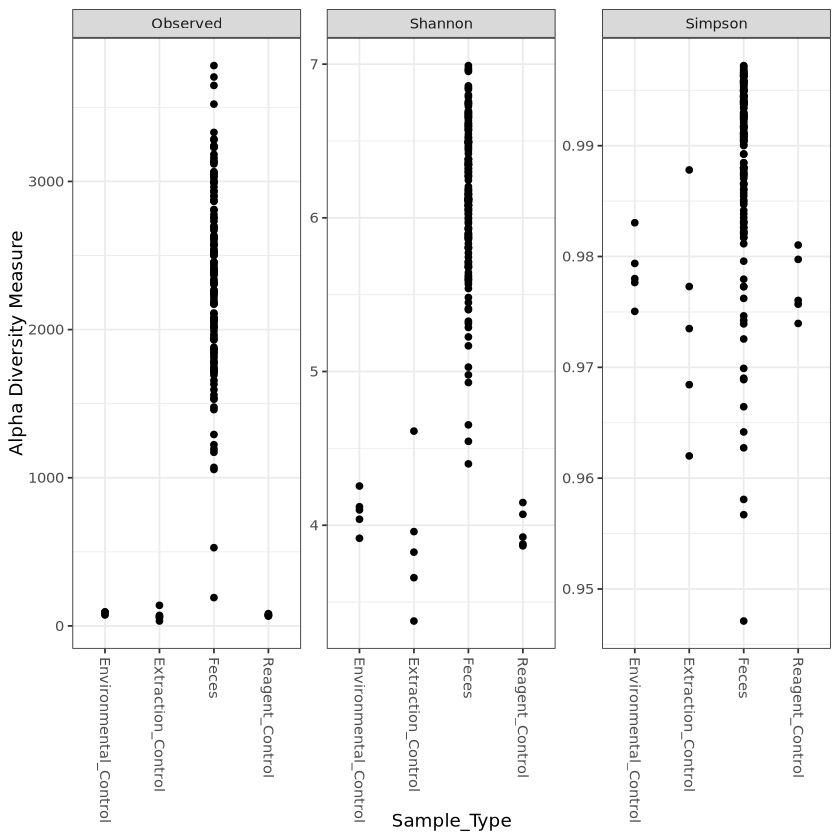

In [366]:
library(phyloseq)
plot_richness(ps.true_sample_cleaned, x = "Sample_Type", measures = c("Shannon", "Simpson", "Observed"))

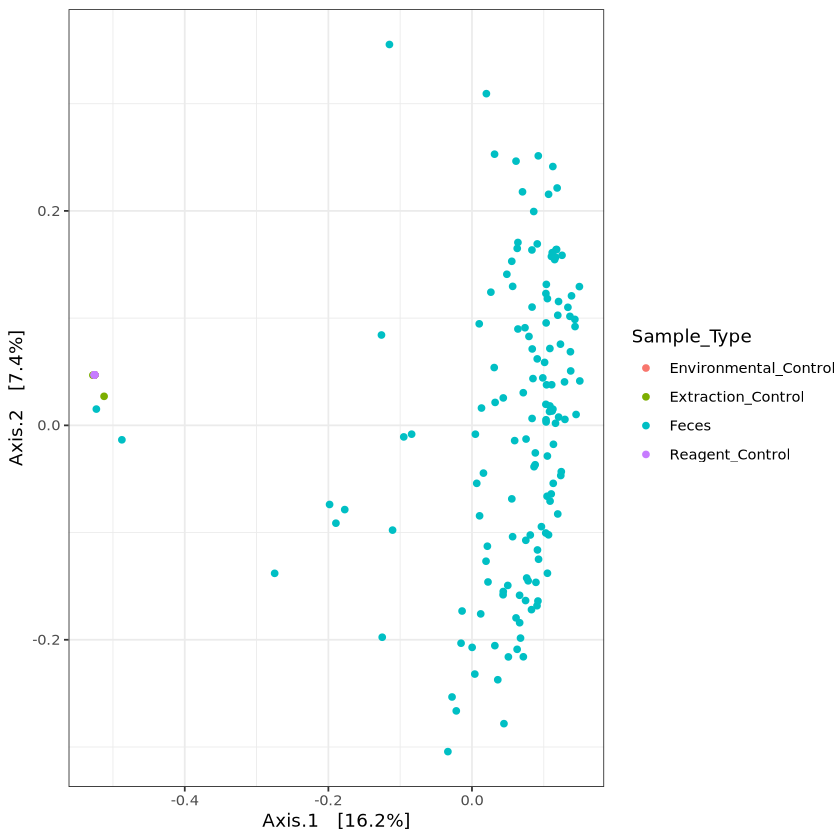

In [367]:
# Ordination (e.g., PCoA using Bray-Curtis)
ord <- ordinate(ps.true_sample_cleaned, method = "PCoA", distance = "bray")
plot_ordination(ps.true_sample_cleaned, ord, color = "Sample_Type")


In [368]:
distance_matrix <- distance(ps.true_sample_cleaned, method = "bray")

ERROR: Error: unable to find an inherited method for function ‘distance’ for signature ‘x = "phyloseq", y = "missing"’


In [51]:
alpha_df <- estimate_richness(ps_no_contam, measures = c("Shannon", "Simpson"))

In [52]:
alpha_df$SampleID <- rownames(alpha_df)
metadata <- data.frame(sample_data(ps_no_contam))
metadata$SampleID <- rownames(metadata)

# Merge metadata with richness
alpha_df <- merge(alpha_df, metadata, by = "SampleID")


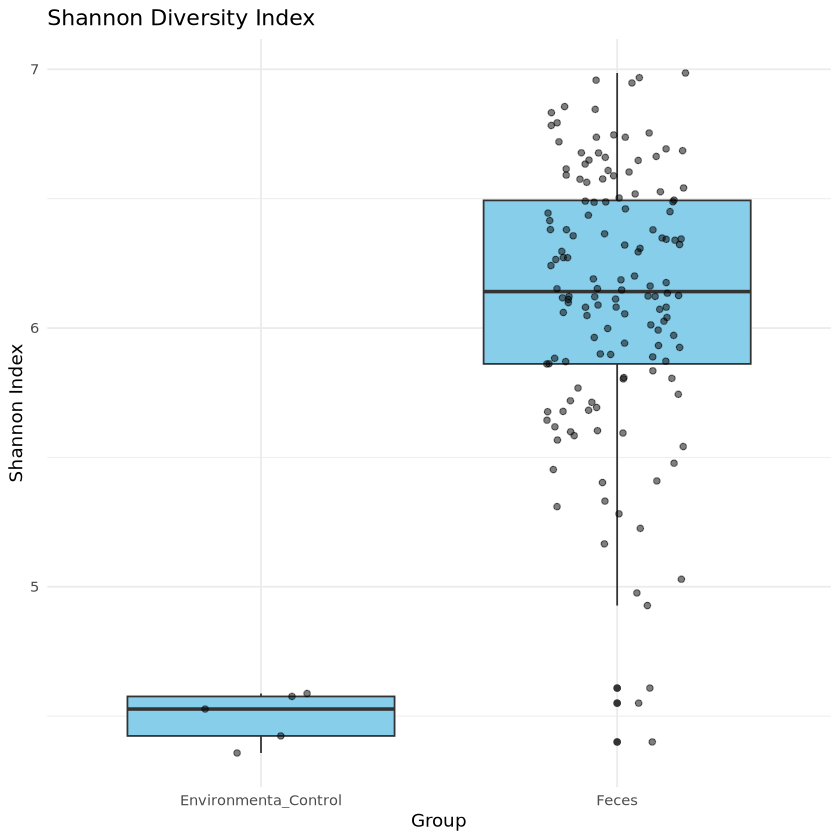

In [53]:
ggplot(alpha_df, aes(x = Sample_Type, y = Shannon)) +  # change Sample_Type to your grouping variable
  geom_boxplot(fill = "skyblue") +
  geom_jitter(width = 0.2, alpha = 0.5) +
  theme_minimal() +
  labs(title = "Shannon Diversity Index", x = "Group", y = "Shannon Index")


In [39]:
# Ensure your metadata has the correct Sample_ID column
# and CopyNumber column with DNA concentration values

# Set rownames to Sample_ID so it matches sample_names in phyloseq object
rownames(metadata) <- metadata$Sample_ID

# Optional: Check sample name overlap
all(sample_names(ps.samples) %in% rownames(metadata))  # Should return TRUE

# Align metadata with phyloseq sample order
metadata <- metadata[sample_names(ps.samples), ]

# Add CopyNumber to phyloseq sample_data
sample_data(ps.samples)$CopyNumber <- metadata$CopyNumber

ERROR: Error in metadata$Sample_ID: object of type 'closure' is not subsettable


In [36]:
# Run frequency-based contaminant detection using DNA concentration (CopyNumber)
contamdf.freq <- isContaminant(ps.samples, method = "frequency", conc = "CopyNumber", threshold = 0.5)

# Show how many taxa were classified as contaminants (TRUE) and non-contaminants (FALSE)
table(contamdf.freq$contaminant)

# Get the indices (positions) of taxa identified as contaminants (TRUE)
contam_feature_indices <- which(contamdf.freq$contaminant == TRUE)

# Show the first few contaminant taxa indices
head(contam_feature_indices)

# Optional: print the taxon names classified as contaminants (first few)
head(taxa_names(ps.samples)[contam_feature_indices])


ERROR: Error in getFromPS(ps, conc): CopyNumber is not a valid sample-variable in the provided phyloseq object.


In [32]:
# Run frequency method
# Run frequency method contaminant detection
# ps.samples: phyloseq object with true samples only (no controls)
# 'CopyNumber' is the column in sample_data containing DNA concentration values
contamdf.freq <- isContaminant(ps.samples, method = "frequency", conc = "CopyNumber", threshold = 0.5)

# Show the count of taxa classified as contaminants (TRUE) and non-contaminants (FALSE)
table(contamdf.freq$contaminant)

# Get the indices of taxa identified as contaminants
contam_feature_indices <- which(contamdf.freq$contaminant == TRUE)

# Display the first few contaminant indices
head(contam_feature_indices)

# Optional: print some taxon names classified as contaminants
head(taxa_names(ps.samples)[contam_feature_indices])


ERROR: Error in h(simpleError(msg, call)): error in evaluating the argument 'seqtab' in selecting a method for function 'isContaminant': object 'ps.samples' not found


In [ ]:
# Select contaminants from otu table
contam_seq_freq <- rownames(contamdf.freq[contamdf.freq$contaminant == "TRUE",])

contamdf.freqMod <- contamdf.freq %>%
  filter(prev > 1) %>%
  mutate(Prevalence = ifelse(prev == 2, "2",
                             ifelse(prev > 2 & prev <= 5, "3-5",
                                    ifelse(prev >= 6 & prev <= 10, "6-10", "11+")))  )

contamdf.freqMod$Prevalence <- factor(contamdf.freqMod$Prevalence, levels = c("2", "3-5", "6-10", "11+"))

In [ ]:
# Plot score statistics output from 'frequency' method

# Set up:
theme_set(theme_bw())
          # Part of the Area Green Tableau color palette (Version 9.x)
          # Similar to Davis et al., (2018)
scaleColorFillManualFrequency <-
  scale_fill_manual(
    values = 
      c(
        "2"    = "#dbe8b4",
        "3-5"  = "#9ad26d",
        "6-10" = "#6cae59",
        "11+"  = "#4a8c1c"
      )
  )

# Plot score statistics output 
freqScorePlot <- ggplot(contamdf.freqMod, aes(x = p, fill = Prevalence)) +
  geom_histogram(bins = 30)                                      +
  scaleColorFillManualFrequency                                  + 
  ggtitle("Frequency Method")                                    +
  xlab("Score Statistic")                                        + 
  ylab("Frequency")                                              +
  theme(
    plot.title = element_text(hjust = 0.5),
    legend.position = "none")

freqScorePlot

In [ ]:
### 6. Prevalence-Based Contaminant Detection

```{r}
# Prepare data for 'prevalence' method
sample_data(ps)$is.neg <- sample_data(ps)$SampleOrControl == "Control"

# Run 'prevalence' method
# Information about whether the sample ir a control or true sample is stored in 'is.neg' variable
contamdf.prev <- isContaminant(ps, method="prevalence", neg="is.neg", threshold=0.5)
table(contamdf.prev$contaminant)
# Display the number of sequence features classified as contaminants
# FALSE: Number of sequence features not classified as contaminants 
# TRUE:  Number of sequence features classified as contaminants 


contam_feature_indices_prev <- which(contamdf.prev$contaminant == TRUE)
head(contam_feature_indices_prev)
# Vector of sequence feature indices in otu table that are contaminants
# Note: Some of the most abundant sequence features were classified as contaminants

In [ ]:
# Make phyloseq object of presence-absence in negative controls and true samples
ps.pa <- transform_sample_counts(ps, function(abund) 1*(abund>0))
ps.pa.neg <- prune_samples(sample_data(ps.pa)$SampleOrControl == "Control", ps.pa)
ps.pa.pos <- prune_samples(sample_data(ps.pa)$SampleOrControl == "Sample", ps.pa)

In [ ]:
# Make data.frame of prevalence in positive and negative samples
df.pa <- data.frame(pa.pos=taxa_sums(ps.pa.pos), pa.neg=taxa_sums(ps.pa.neg),
                    contaminant=contamdf.prev$contaminant)
pa.plot <- ggplot(data=df.pa, aes(x=pa.neg, y=pa.pos, color=contaminant)) + 
  geom_point() +
  theme(legend.position = "bottom")+
  xlab("Prevalence (Negative Controls)") + 
  ylab("Prevalence (True Samples)")
pa.plot

In [ ]:
### 8. Prevalence-Based Detection: Extraction Controls

# Prepare data for 'prevalence' method, Extraction is control
ps.no.library <- subset_samples(ps, !Type %in% "Library") # remove library samples
ps.no.library <- prune_taxa(taxa_sums(ps.no.library) > 0, ps.no.library) # remove taxa with no counts
ps.no.library


sample_data(ps.no.library)$is.neg <- sample_data(ps.no.library)$SampleOrControl == "Control"

# Run 'prevalence' method
# Information about whether the sample ir a control or true sample is stored in 'is.neg' variable

contamdf.prev.extraction <- isContaminant(ps.no.library, method="prevalence", neg="is.neg", threshold=0.5)
table(contamdf.prev.extraction$contaminant)
# Show number of sequence features classified as contaminants
# FALSE: No. of sequence features that were not classified as contaminants
# TRUE:  No. of sequence features that were classified as contaminants


contam_feature_indices_prev_extraction <- which(contamdf.prev.extraction$contaminant == TRUE)
head(contam_feature_indices_prev_extraction)
# Vector of sequece feature indices in otu table that are contaminants
# Note: Some of the most abundant sequence features were classified as contaminants
#Plot Extraction Score 
contamdf.prev.extractionMod <- contamdf.prev.extraction %>%
  filter(prev > 1) %>%
  mutate(Prevalence = ifelse(prev == 2, "2",
                             ifelse(prev > 2 & prev <= 5, "3-5",
                                    ifelse(prev >= 6 & prev <= 10, "6-10", "11+")))
  )
contamdf.prev.extractionMod$Prevalence <- factor(contamdf.prev.extractionMod$Prevalence, levels = c("2", "3-5", "6-10", "11+"))


prev.extractionScorePlot <- ggplot(contamdf.prev.extractionMod, aes(x = p, fill = Prevalence)) +
  geom_histogram(bins = 30)                                      +
  scaleColorFillManualFrequency                                  + 
  ggtitle("Prevalence Method (extraction)")                      +
  xlab("Score Statistic")                                        + 
  ylab("Frequency")                                              +
  theme(
    plot.title = element_text(hjust = 0.5),
    legend.position = "right",
    axis.title.y = element_blank()
  )
prev.extractionScorePlot

#select seq names of contaminants identified by prevalence method using extraction as control
contam_seq_prev_extraction <- rownames(contamdf.prev.extraction[contamdf.prev.extraction$contaminant == "TRUE",])

In [ ]:
### 9. Phyloseq object after Decontam

# Create noncontam ps project
# Select unique seq names of contaminants identified by both frequency and prevalence methods separately 
contam_seq <- c(contam_seq_freq, contam_seq_prev_extraction, contam_seq_prev_water)
contam_seq <- unique(contam_seq)

# Create ps project after removing contaminants
allTaxa = taxa_names(ps)
Taxa.decontam <- allTaxa[!(allTaxa %in% contam_seq)]
ps.decontam <- prune_taxa(Taxa.decontam, ps)
saveRDS(ps.decontam, file.path(path.rds, "ps.decontam.rds"))

ps.contam <- prune_taxa(contam_seq, ps)
saveRDS(ps.contam, file.path(path.rds, "ps.contam.rds"))

In [ ]:
#### 9.1 Plot 16S Gene Copy vs Abundance of Contaminants

SAMPLE_TYPES <- c(
  "Teat apex",
  "Teat canal",
  "Stripped milk",
  "Cisternal milk",
  "Air",
  "Blank",
  "Extraction",
  "Library"
)


my_palette<- c(
  "Teat apex" = "#1f77b4",
  "Teat canal" = "#ff7f0e",
  "Stripped milk" = "#2ca02c",
  "Cisternal milk" = "#d62728",
  "Library" = "#7f7f7f",
  "Extraction" = "#bcbd22",
  "Air" = "#539caf",
  "Blank" = "#ebc850"
)

metadata <- sample_data(ps.contam) %>% data.frame
counts <- sample_sums(ps.contam) %>% data.frame
colnames(counts) <- "counts"
counts$X.SampleID <- rownames(counts)
metadata <- left_join(metadata, counts, by = "X.SampleID")
metadata <- metadata[metadata$Type != "Library",]
metadata$Type <- factor(metadata$Type, levels = SAMPLE_TYPES)

p.contam.counts <- ggplot(data=metadata, aes(x=log(CopyNumber), y=counts/1000))+
  geom_point(aes(color = Type), size = 2)+
  geom_smooth(aes(group =1), method = "lm", se = TRUE) +
  stat_cor(label.x = 7, label.y = 110) +
  stat_regline_equation(label.x = 7, label.y = 100)+
  xlab("Log (16S gene copy number)")+
  ylab("Counts / 1000")+
  scale_color_manual(values = my_palette)
p.contam.counts # 16S gene copy number vs abundance of contaminants


In [118]:
#### 15.2 Load the positive mock sample
# Define sample names for each mock group
mockA_samples <- c("mock-synthetic-ZYMO-1", "mock-synthetic-ZYMO-2", "mock-synthetic-ZYMO-3")
mockB_samples <- c("mock-synthetic-ZYMO-4", "mock-synthetic-ZYMO-5")
# Subset phyloseq object by sample names
mockA_ps <- subset_samples(ps.positive, Sample_ID %in% mockA_samples)
mockB_ps <- subset_samples(ps.positive, Sample_ID %in% mockB_samples)
# Reference phyla for Mock A
mock_phyla_ref <- c("Actinobacteria", "Bacteroidetes", "Cyanobacteria", "Euryarchaeota",
                    "Firmicutes", "Lentisphaerae", "Patescibacteria", "Proteobacteria",
                    "Synergistetes", "Tenericutes", "Verrucomicrobia")
# Reference genera for Mock B
mock_genera_ref <- c("Pseudomonas", "Escherichia", "Salmonella",
                     "Lactobacillus", "Enterococcus", "Staphylococcus", 
                     "Listeria", "Bacillus", "Saccharomyces", "Cryptococcus")

ERROR: Error in h(simpleError(msg, call)): error in evaluating the argument 'object' in selecting a method for function 'sample_data': object 'ps.positive' not found


In [ ]:
# Convert metadata to sample_data
meta_samples <- sample_data(meta)
# Merge the sample_data (meta_samples) with the existing phyloseq object
physeq <- merge_phyloseq(seq, meta_samples)
# Identify mock samples
mock_ids <- meta$Corrected_Sample_ID[grepl("mock", meta$Corrected_Sample_ID, ignore.case = TRUE)]

# Prune mock samples from physeq
physeq <- prune_samples(!(sample_names(physeq) %in% mock_ids), physeq)
# Save the phyloseq object without mock samples
saveRDS(physeq, file = file.path(output_dir, "phyloseq_WO_mock.rds"))


In [ ]:
# 1. Subset Mock A (Phylum-level)
# ----------------------
mockA_melt <- psmelt(mockA_ps)

# Convert Phylum to character and filter based on reference
mockA_melt$Phylum <- as.character(mockA_melt$Phylum)
mockA_filtered <- mockA_melt %>%
  filter(Phylum %in% mock_phyla_ref)

# Optional: sort phyla factor for consistent plotting
mockA_filtered$Phylum <- factor(mockA_filtered$Phylum, levels = mock_phyla_ref)

In [ ]:
mockB_melt <- psmelt(mockB_ps)

# Standardize genus names (e.g., Escherichia/Shigella to Escherichia)
mockB_melt$Genus <- as.character(mockB_melt$Genus)
mockB_melt$Genus <- ifelse(mockB_melt$Genus == "Escherichia/Shigella", "Escherichia", mockB_melt$Genus)

# Filter to reference mock genera
mockB_filtered <- mockB_melt %>%
  filter(Genus %in% mock_genera_ref)

# Optional: sort genera factor for consistent plotting
mockB_filtered$Genus <- factor(mockB_filtered$Genus, levels = mock_genera_ref)
# Unique taxa recovered
recovered_phyla <- unique(mockA_filtered$Phylum)
recovered_genera <- unique(mockB_filtered$Genus)

# Recovery counts
cat("Mock A - Recovered Phyla:\n")
print(recovered_phyla)
cat(sprintf("Recovered: %d / %d\n", length(recovered_phyla), length(mock_phyla_ref)))

cat("\nMock B - Recovered Genera:\n")
print(recovered_genera)
cat(sprintf("Recovered: %d / %d\n", length(recovered_genera), length(mock_genera_ref)))

In [ ]:
# Mock B Genus bar plot
ggplot(mockB_filtered, aes(x = Genus, y = Abundance, fill = Sample)) +
  geom_bar(stat = "identity", position = "stack") +
  theme_minimal() +
  labs(title = "Mock B (Genus-level) - Detected Genera", y = "Abundance")

# Mock A Phylum bar plot
ggplot(mockA_filtered, aes(x = Phylum, y = Abundance, fill = Sample)) +
  geom_bar(stat = "identity", position = "stack") +
  theme_minimal() +
  labs(title = "Mock A (Phylum-level) - Detected Phyla", y = "Abundance")


In [ ]:
###Plot the composition of positive control against mock community
# Make sure abundance column is numeric
mockB_filtered$Abundance <- as.numeric(mockB_filtered$Abundance)
mockA_filtered$Abundance <- as.numeric(mockA_filtered$Abundance)

# Set factor levels to control order of bars (optional)
mockB_filtered$Genus <- factor(mockB_filtered$Genus, levels = unique(mockB_filtered$Genus))
mockA_filtered$Phylum <- factor(mockA_filtered$Phylum, levels = unique(mockA_filtered$Phylum))

# ---- Mock B Genus-level stacked bar plot ----
p_mockB <- ggplot(mockB_filtered, aes(x = Sample, y = Abundance, fill = Genus)) +
  geom_bar(stat = "identity", position = "stack", color = "black", alpha=0.8) +
  theme_minimal() +
  labs(title = "Mock B (Genus-level) - Detected Genera", y = "Abundance", x = "Sample") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1),
        legend.position = "bottom") +
  guides(fill = guide_legend(nrow = 2, byrow = TRUE))

# Print Mock B plot
print(p_mockB)

# ---- Mock A Phylum-level stacked bar plot ----
p_mockA <- ggplot(mockA_filtered, aes(x = Sample, y = Abundance, fill = Phylum)) +
  geom_bar(stat = "identity", position = "stack", color = "black", alpha=0.8) +
  theme_minimal() +
  labs(title = "Mock A (Phylum-level) - Detected Phyla", y = "Abundance", x = "Sample") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1),
        legend.position = "bottom") +
  guides(fill = guide_legend(nrow = 2, byrow = TRUE))

# Print Mock A plot
print(p_mockA)


In [ ]:
## Phyloseq for true samples
# Keep only rows where Sample_Type is "Feces"
meta_true_sample <- meta[meta$Sample_Type == "Feces", ]
# If sample names are rownames of seqtab
seqtab.true_sample <- seqtab.samples[rownames(seqtab.samples) %in% rownames(meta_true_sample), ]
# OR, if sample names are columns
# seqtab.true_sample <- seqtab.samples[, colnames(seqtab.samples) %in% rownames(meta_true_sample)]
# Remove all control samples based on the correct 'Sample_Type' column
meta_true_sample <- meta_true_sample[!meta_true_sample$Sample_Type %in% c("Reagent_Control", "Environmental_Control", "Extraction_Control"), ]

In [ ]:
# Subset seqtab.samples to keep only true samples
seqtab.true_sample <- seqtab.samples[rownames(seqtab.samples) %in% rownames(meta_true_sample), ]
# Create OTU table with the true samples
otu_true_sample <- otu_table(seqtab.true_sample, taxa_are_rows = FALSE)
# Ensure meta_true_sample is in the correct format for sample_data
sample_data_true_sample <- sample_data(meta_true_sample)
# Create phyloseq object for true feces samples
physeq_true_sample <- phyloseq(otu_true_sample, tax, sample_data_true_sample)
# Save the phyloseq object
saveRDS(physeq_true_sample, file = file.path(output_dir, "phyloseq_true_samples.rds"))


In [ ]:
# Generate phyloseq object without positive control. The phyloseq object, allows the following component data classes: otu_table-class, sample_data-class, taxonomyTable-class, and phylo-class.
ps <- phyloseq(seq, tax, meta_samples)
ps

# Generate phyloseq object
meta_samples <- sample_data(meta_samples)
ps <- phyloseq(seq, tax, meta_samples)
ps

# Save phyloseq object
saveRDS(ps, file.path(path.rds, 'phyloseq.rds'))



In [ ]:
# Phyloseq for positive samples
metadata$SourceType <- case_when(
  grepl("control-extraction", metadata$SampleID, ignore.case = TRUE) ~ "Extraction Control",
  grepl("control-te", metadata$SampleID, ignore.case = TRUE) ~ "Reagent Control",
  grepl("PBS", metadata$SampleID, ignore.case = TRUE) ~ "Environmental Control",
  grepl("mock-synthetic", metadata$SampleID, ignore.case = TRUE) ~ "Mock Community",
  metadata$SampleType == "feces" ~ "Sample",
  TRUE ~ "Other"
)
#Spiltig of dataset
ps.neg <- subset_samples(ps, SourceType %in% c("Extraction Control", "Reagent Control", "Environmental Control"))
ps.pos <- subset_samples(ps, SourceType == "Mock Community")
ps.samples <- subset_samples(ps, SourceType == "Sample")

#Confirm 
sample_data(ps.samples)$SampleType %>% table()
sample_names(ps.neg)  # Should show only negative controls




# Subset only 'true' sample rows from the metadata
meta_true <- subset(meta_positive, SourceType == "Sample")  # assuming SourceType is correctly defined
sample_names_true <- rownames(meta_true)

# Subset the sequence table for those true samples
seqtab_true <- seqtab.nochim[sample_names_true, ]
dim(seqtab_true)

# Convert to otu_table object
seq_true <- otu_table(seqtab_true, taxa_are_rows = FALSE)
class(seq_true)  # Should return "otu_table"

# Subset the taxonomy to match ASVs present in the filtered sequence table
taxa_true <- tax_table(taxa)[rownames(taxa) %in% colnames(seqtab_true), ]  # assuming `taxa` is already assigned
class(taxa_true)  # Should return "taxonomyTable"

# Prepare the metadata in correct format
meta_true <- sample_data(meta_true)
class(meta_true)  # Should return "sample_data"

# Create phyloseq object
ps_true <- phyloseq(seq_true, taxa_true, meta_true)
ps_true

# Save the phyloseq object
saveRDS(ps_true, file.path(path.rds, "ps.true_samples.rds"))

```

In [ ]:
library(dada2)
library(ggplot2)
library(ggpubr)
library(patchwork)
library(dplyr)
library(gghalves)
library(phyloseq)
library(introdataviz)
library(decontam)
library(dplyr)
library(pairwiseAdonis)
library(microbiome)

path.rds
path.figures

In [ ]:
# 15.4 Plot sequencing depth and 16S gene copy numbers by sample types

```{r}
ps_seq_quality <- readRDS(file.path(path.rds, "phyloseq.rds"))

SAMPLE_TYPES <- c(
  "Teat apex",
  "Teat canal",
  "Stripped milk",
  "Cisternal milk",
  "Air",
  "Blank",
  "Extraction",
  "Library"
)

theme_set(theme_bw())

ColorFillManual <- c(
  "Teat apex" = "#1f77b4",
  "Teat canal" = "#ff7f0e",
  "Stripped milk" = "#2ca02c",
  "Cisternal milk" = "#d62728",
  "Library" = "#7f7f7f",
  "Extraction" = "#bcbd22",
  "Air" = "#539caf",
  "Blank" = "#ebc850"
)


sdata_df <- as(sample_data(ps), "data.frame")
sdata_df$Type <- factor(sdata_df$Type, levels = SAMPLE_TYPES)
sdata_df$PF_Clusters <- as.numeric(sdata_df$PF_Clusters)

In [ ]:
# 15.5 Plot No. Reads by Sample Type

```{r}
p.reads <- sdata_df %>% 
  ggplot(aes(x = Type, y = PF_Clusters/1000, fill = Type, color=Type))+
  scale_color_manual (values = ColorFillManual)+
  scale_fill_manual (values = ColorFillManual)+
  geom_half_violin(position = position_nudge(x = 0.15, y = 0),
                   color=NA, 
                   alpha = 0.6, 
                   scale = "width", 
                   trim = F, 
                   side = "R")+
  geom_boxplot(width = 0.2, outlier.shape = NA, alpha=0.6) +
  geom_half_point(position = position_nudge(x=-0.4), 
                  size=2, 
                  range_scale=0.4, 
                  alpha = 0.6) +
  ylab("Number of Reads / 1000") +
  ylim(0,320)+
  theme(legend.position = "none",
        axis.text.x = element_text(angle = -45, size = 10),
        axis.title.x = element_blank(),
        axis.title.y = element_text(size = 10))
p.reads 

## statistical analysis suing glm, ANOVA and emmeans
glm.sample.depth <- glm(PF_Clusters/1000 ~ Type, data = sdata_df)
summary(glm.sample.depth)
car::Anova(glm.sample.depth)
emmeans::emmeans(glm.sample.depth, pairwise~Type)

In [ ]:
# 15.6 Plot copy No. by Sample Type

```{r}
p.copy<- sdata_df %>% 
  ggplot(aes(x = Type, y = log(CopyNumber), fill = Type, color=Type))+
  scale_color_manual (values = ColorFillManual)+
  scale_fill_manual (values = ColorFillManual)+
  geom_flat_violin(position = position_nudge(x = 0.15, y = 0),
                   color=NA, alpha = 0.6, scale = "width", trim = F)+
  geom_boxplot(width = 0.2, outlier.shape = NA, alpha=0.6) +
  geom_half_point(position = position_nudge(x=-0.4), 
                  size=2, range_scale=0.4, alpha = 0.6) +
  ylab("Log (16S copy number)") +
  ylim(0,16)+
  theme(legend.position = "none",
        axis.text.x = element_text(angle = -45, size = 10),
        axis.title.x = element_blank(),
        axis.title.y = element_text(size = 10))
p.copy <- print(p.copy)

# statistical analysis using glm, ANOVA and emmeans
glm.sample.CopyN <- glm(log(CopyNumber) ~ Type, data = sdata_df)
summary(glm.sample.CopyN)
car::Anova(glm.sample.CopyN)
emmeans::emmeans(glm.sample.CopyN, pairwise~Type)

In [ ]:
# 15.7 Combine the plots

```{r}
p.quality <- ((p.reads | p.copy) / (p.positive)) + plot_annotation(tag_levels = "A") + plot_layout(height=c(2,1))
ggsave(file.path(path.figures,"Figure 2. Depth_16S copy_Positive.png"), width=10, height=8, p.quality, dpi=600)

In [28]:
mock_samples <- grep("mock-synthetic", rownames(seqtab.nochim), value = TRUE)
mock_seqtab <- seqtab.nochim[mock_samples, ]

unqs.mock <- colSums(seqtab.nochim[mock_samples, , drop=FALSE])
unqs.mock <- sort(unqs.mock[unqs.mock > 0], decreasing = TRUE)
cat("DADA2 inferred", length(unqs.mock), "sample sequences present in the Mock community.\n")

DADA2 inferred 1940 sample sequences present in the Mock community.


In [29]:
# Load reference sequences from all mock files
mock_files <- c("mock1_asvs.fasta", "mock2_asvs.fasta", "mock3_asvs.fasta")
mock_paths <- file.path("/scratch/negishi/ldas/1_5_25/Mock/Mock_paired", mock_files)

# Read all sequences and combine into one vector
mock_refs <- unlist(lapply(mock_paths, Biostrings::readDNAStringSet))
mock_seqs <- as.character(mock_refs)

# Count exact matches to unique sequences in your dataset
match.ref <- sum(sapply(names(unqs.mock), function(x) any(grepl(x, mock_seqs))))
cat("Of those,", match.ref, "were exact matches to the expected reference sequences.\n")

Of those, 0 were exact matches to the expected reference sequences.


In [38]:
# to compare ASV in mock and sequenced mock
library(Biostrings)


Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, saveRDS, setdiff,
    table, tapply, union, unique, unsplit, which.max, which.min


Loading required package: S4Vectors

Loading required package: stats4


Attaching package: ‘S4Vectors’


The following objects are masked from ‘package:dplyr’:

    first, rename


The following object is masked from ‘package:utils’:

    findMatches


The following objects are m

In [39]:
# Load the ASV sequences you inferred from DADA2
asv_seqs <- DNAStringSet(names(unqs.mock))

In [41]:
mock_files <- c("mock1_asvs.fasta", "mock2_asvs.fasta", "mock3_asvs.fasta")
mock_paths <- file.path("/scratch/negishi/ldas/1_5_25/Mock/Mock_paired", mock_files)

# Read all reference mock sequences into one DNAStringSet object
refs <- do.call(c, lapply(mock_paths, readDNAStringSet))
compare_asvs_to_reference <- function(asvs, refs, min_identity = 100) {
  results <- data.frame(
    ASV = names(asvs),
    BestMatch = NA,
    Identity = NA,
    stringsAsFactors = FALSE
  )

  for (i in seq_along(asvs)) {
    alignments <- pairwiseAlignment(asvs[[i]], refs, type = "global")
    pids <- pid(alignments)  # percent identity
    best_idx <- which.max(pids)

    results$BestMatch[i] <- names(refs)[best_idx]
    results$Identity[i] <- pids[best_idx]
  }

  results$Match <- results$Identity >= min_identity
  return(results)
}

alignment_results <- compare_asvs_to_reference(asv_seqs, refs)


ERROR: Error in data.frame(ASV = names(asvs), BestMatch = NA, Identity = NA, : arguments imply differing number of rows: 0, 1


In [31]:
mock_asvs_only <- getSequences(seqtab.nochim[grep("mock", rownames(seqtab.nochim), ignore.case = TRUE), ])
mock_asvs_only <- colnames(seqtab.nochim)[colSums(seqtab.nochim[grep("mock", rownames(seqtab.nochim), ignore.case = TRUE), ]) > 0]


In [33]:
mock_samples <- grep("mock-synthetic", rownames(seqtab.nochim), ignore.case = TRUE, value = TRUE)
mock_seqtab <- seqtab.nochim[mock_samples, ]

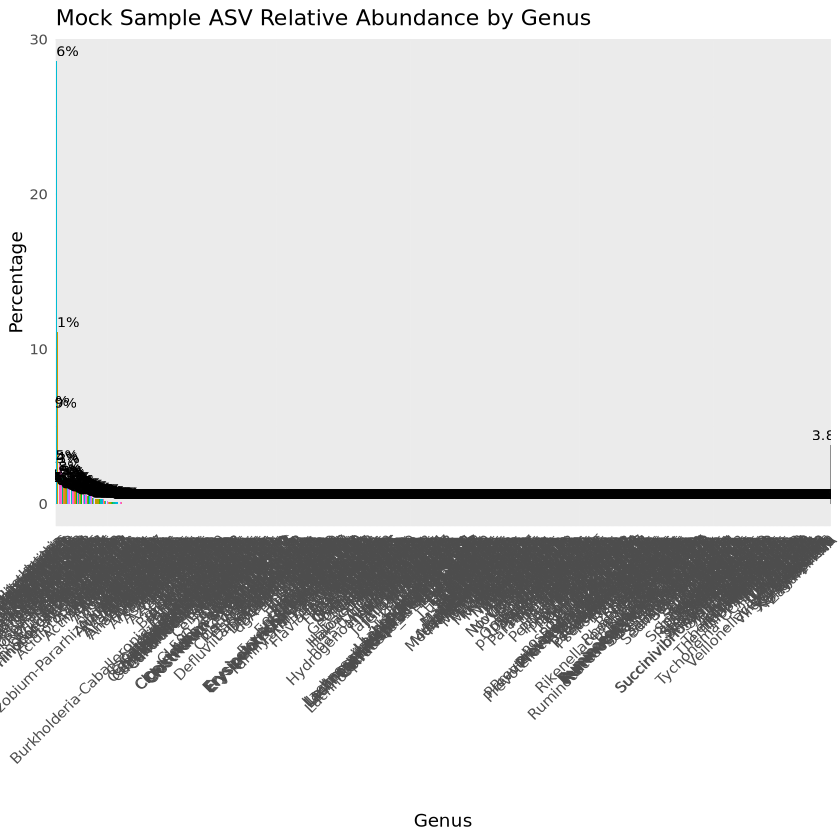

In [36]:
# Extract ASV table for mock samples only, Sum ASV counts across all mock samples, attach taxonomy info and summuraize phylum and genus
asv_abundance <- colSums(mock_seqtab)
asv_abundance_df <- data.frame(
  ASV = names(asv_abundance),
  Abundance = asv_abundance
)
asv_abundance_df$Genus <- taxa[asv_abundance_df$ASV, "Genus"]
asv_abundance_df$Phylum <- taxa[asv_abundance_df$ASV, "Phylum"]
library(dplyr)
genus_abundance <- asv_abundance_df %>%
  group_by(Genus) %>%
  summarise(Total = sum(Abundance)) %>%
  mutate(Percentage = round(100 * Total / sum(Total), 1)) %>%
  arrange(desc(Percentage))
library(ggplot2)
ggplot(genus_abundance, aes(x = reorder(Genus, -Percentage), y = Percentage, fill = Genus)) +
  geom_bar(stat = "identity") +
  labs(title = "Mock Sample ASV Relative Abundance by Genus",
       x = "Genus",
       y = "Percentage") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1),
        legend.position = "none") +
  geom_text(aes(label = paste0(Percentage, "%")), vjust = -0.5, size = 3)


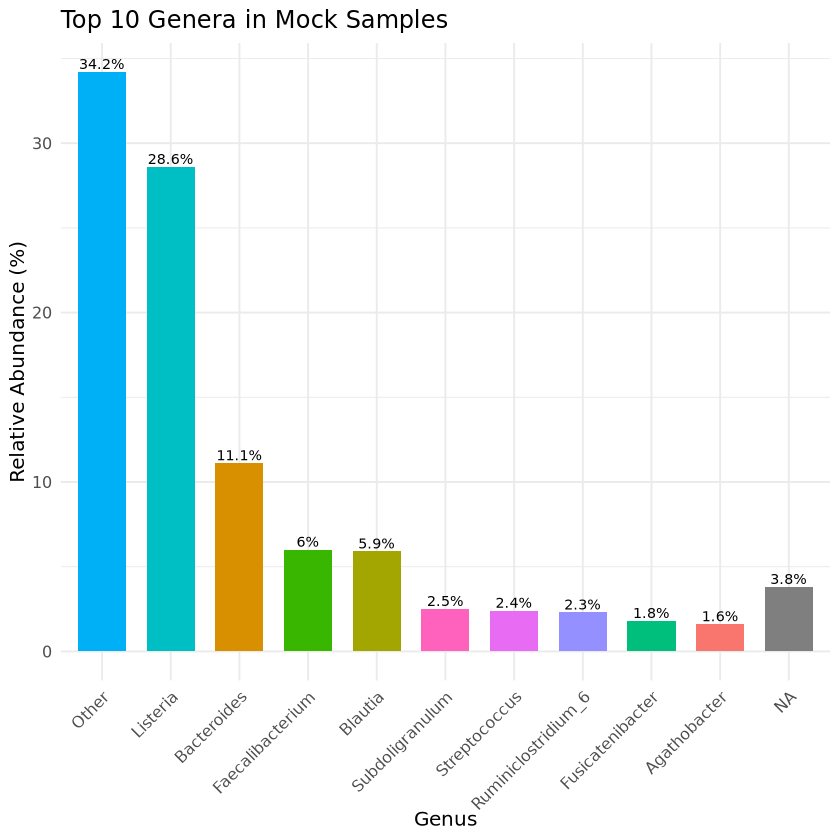

In [37]:
top_genus_abundance <- genus_abundance %>%
  top_n(10, Total) %>%
  arrange(desc(Total))
other_total <- sum(genus_abundance$Total) - sum(top_genus_abundance$Total)
other_row <- data.frame(Genus = "Other",
                        Total = other_total,
                        Percentage = round(100 * other_total / sum(genus_abundance$Total), 1))

genus_plot_data <- bind_rows(top_genus_abundance, other_row)
ggplot(genus_plot_data, aes(x = reorder(Genus, -Percentage), y = Percentage, fill = Genus)) +
  geom_bar(stat = "identity", width = 0.7) +
  labs(title = "Top 10 Genera in Mock Samples", x = "Genus", y = "Relative Abundance (%)") +
  theme_minimal(base_size = 12) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1),
        legend.position = "none") +
  geom_text(aes(label = paste0(Percentage, "%")), vjust = -0.3, size = 3)


In [25]:
unqs.mock <- seqtab.nochim["Mock",]
unqs.mock <- sort(unqs.mock[unqs.mock>0], decreasing=TRUE) # Drop ASVs absent in the Mock
cat("DADA2 inferred", length(unqs.mock), "sample sequences present in the Mock community.\n")

ERROR: Error in seqtab.nochim["Mock", ]: subscript out of bounds


In [83]:
mock_asvs <- readDNAStringSet("/scratch/negishi/ldas/1_5_25/DADA2_inputs/Mock_all_asvs_clean.fasta") 

In [24]:
names(mock_asvs) <- make.unique(names(mock_asvs))

ERROR: Error: object 'mock_asvs' not found


In [38]:
taxa <- assignTaxonomy(mock_asvs, "/scratch/negishi/ldas/1_5_25/DADA2_inputs/silva_nr_v132_train_set.fa.gz", multithread = TRUE)

In [39]:
taxa_with_species <- addSpecies(taxa, "/scratch/negishi/ldas/1_5_25/DADA2_inputs/silva_species_assignment_v132.fa.gz")

In [40]:
write.csv(taxa_with_species, "Mock_all_asvs_taxonomy.csv", quote = FALSE)

In [41]:
head(taxa_with_species)

,Kingdom,Phylum,Class,Order,Family,Genus,Species
AGAGTTTGATCATGGCTCAGATTGAACGCTGGCGGCAGGCTTAACACATGCAAGTCGAGCGGGGGAAGGTAGCTTGCTACTGGACCTAGCGGCGGACGGGTGAGTAATGCTTAGGAATCTGCCTATTAGTGGGGGACAACATCTCGAAAGGGATGCTAATACCGCATACGTCCTACGGGAGAAAGCAGGGGATCTTCGGACCTTGCGCTAATAGATGAGCCTAAGTCGGATTAGCTAGTTGGTGGGGTAAAGGCCTACCAAGGCGACGATCTGTAGCGGGTCTGAGAGGATGATCCGCCACACTGGGACTGAGACACGGCCCAGACTCCTACGGGAGGCAGCAGTGGGGAATATTGGACAATTAGGGGGGGAACCCTGATCCAGCCATGCCGCGTGTGTGAAGAAGGCCTTATGGTTGTAAAGCACTTTAAGCGAGGAGGAGGCTACTTTAGTTAATACCTAGAGATAGTGGACGTTACTCGCAGAATAAGCACCGGCTAACTCTGTGCCAGCAGCCGCGGTAATACAGAGGGTGCGAGCGTTAATCGGATTTACTGGGCGTAAATCTGCGTGCGTAGGCGGCTTATTAAGTCGGATGTGAAATCCCCGAGCTTAACTTGGGAATTGCATTCGATACTGGTGAGCTAGAGTATGGGAGAGGATGGTAGAATTCCAGGTGTAGCGGTGAAATGCGTAGAGATCTGGAGGAATACCGATGGCGAAGGCAGCCATCTGGCCTAATACTGACGCTGAGGTACGAAAGCATGGGGAGCAAACAGGATTAGATACCCTGGTAGTCCATGCCGTAAACGATGTCTACTAGCCGTTGGGGCCTTTGAGGCTTTAGTGGCGCAGCTAACGCGATAAGTAGACCGCCTGGCATGGAGTACGGTCGCAAGACTAAAACTCAAATGAATTGACGGGGGCCCGCACAAGCGGTGGAGCATGTGGTTTAATTCGATGCAACGCGAAGAACCTTACCTGGCCTTGACATACTAGAAACTTTCCAGAGATGGATTGGTGCCTTCGGGAATCTAGATACAGGTGCTGCATGGCTGTCGTCAGCTCGTGTCGTGAGATGTTGGGTTAAGTCCCGCAACGAGCGCAACCCTTTTCCTTACTTGCCAGCATTTCGGATGGGAACTTTAAGGATACTGCCAGTGACAAACTGGAGGAAGGCGGGGACGACGTCAAGTCATCATGGCCCTTACGGCCAGGGCTACACACGTGCTACAATGGTCGGTACAAAGGGTTGCTACACAGCGATGTGATGCTAATCTCAAAAAGCCGATCGTAGTCCGGATTGGAGTCTGCAACTCGACTCCATGAAGTCGGAATCGCTAGTAATCGCGGATCAGAATGCCGCGGTGAATACGTTCCCGGGCCTTGTACACACCGCCCGTCACACCATGGGAGTTTGTTGCACCAGAAGTAGCTAGCCTAACTGCAAAGAGGGCGGTTACCACGGTGTGGCCGATGACTGGGGTGAAGTCGTAACAAGGTAGCCGTAGGGGAACCTGCGGCTGGATCACCTCCTT,Bacteria,Proteobacteria,Gammaproteobacteria,Pseudomonadales,Moraxellaceae,Acinetobacter,NA
GATGAACGCTGGCGGCGTGCCTAATACATGCAAGTCGAGCGAATGGATTAAGAGCTTGCTCTTATGAAGTTAGCGGCGGACGGGTGAGTAACACGTGGGTAACCTGCCCATAAGACTGGGATAACTCCGGGAAACCGGGGCTAATACCGGATAACATTTTGAACCGCATGGTTCGAAATTGAAAGGCGGCTTCGGCTGTCACTTATGGATGGACCCGCGTCGCATTAGCTAGTTGGTGAGGTAACGGCTCACCAAGGCAACGATGCGTAGCCGACCTGAGAGGGTGATCGGCCACACTGGGACTGAGACACGGCCCAGACTCCTACGGGAGGCAGCAGTAGGGAATCTTCCGCAATTAGGGACGAAAGTCTGACGGAGCAACGCCGCGTGAGTGATGAAGGCTTTCGGGTCGTAAAACTCTGTTGTTAGGGAAGAACAAGTGCTAGTTGAATAAGCTGGCACCTTGACGGTACCTAACCAGAAAGCCACGGCTAACTACGTGCCAGCAGCCGCGGTAATACGTAGGTGGCAAGCGTTATCCGGAATTATTGGGCGTAAATCTGCGCGCGCAGGTGGTTTCTTAAGTCTGATGTGAAAGCCCACGGCTCAACCGTGGAGGGTCATTGGAAACTGGGAGACTTGAGTGCAGAAGAGGAAAGTGGAATTCCATGTGTAGCGGTGAAATGCGTAGAGATATGGAGGAACACCAGTGGCGAAGGCGACTTTCTGGTCTGTAACTGACACTGAGGCGCGAAAGCGTGGGGAGCAAACAGGATTAGATACCCTGGTAGTCCACGCCGTAAACGATGAGTGCTAAGTGTTAGAGGGTTTCCGCCCTTTAGTGCTGAAGTTAACGCATTAAGCACTCCGCCTGGCATGGAGTACGGCCGCAAGGCTGAAACTCAAAGGAATTGACGGGGGCCCGCACAAGCGGTGGAGCATGTGGTTTAATTCGAAGCAACGCGAAGAACCTTACCAGGTCTTGACATCCTCTGACAACCCTAGAGATAGGGCTTCTCCTTCGGGAGCAGAGTGACAGGTGGTGCATGGTTGTCGTCAGCTCGTGTCGTGAGATGTTGGGTTAAGTCCCGCAACGAGCGCAACCCTTGATCTTAGTTGCCATCATTCAGTTGGGCACTCTAAGGTGACTGCCGGTGACAAACCGGAGGAAGGTGGGGATGACGTCAAATCATCATGCCCCTTATGACCTGGGCTACACACGTGCTACAATGGACGGTACAAAGAGCTGCAAGACCGCGAGGTGGAGCTAATCTCATAAAACCGTTCTCAGTTCGGATTGTAGGCTGCAACTCGCCTACATGAAGCTGGAATCGCTAGTAATCGCGGATCAGCATGCCGCGGTGAATACGTTCCCGGGCCTTGTACACACCGCCCGTCACACCACGAGAGTTTGTAACACCCGAAGTCGGTGGGGTAACCTTTTGGAGCCAGCCGCCTAAGGTGGGACAGATGATTGGGGTGAAGTCGTAACAAGGTAGCCGTATCGGAAGGTGCGG,Bacteria,Firmicutes,Bacilli,Bacillales,Bacillaceae,Bacillus,NA
TATTACAATGAAGAGTTTGATCCTGGCTCAGGATGAACGCTAGCTACAGGCTTAACACATGCAAGTCGAGGGGCAGCATGGTCTTAGCTTGCTAAGGCCGATGGCGACCGGCGCACGGGTGAGTAACACGTATCCAACCTGCCGTCTACTCTTGGACAGCCTTCTGAAAGGAAGATTAATACAAGATGGCATCATGAGTCCGCATGTTCACATGATTAAAGGTATTCCGGTAGACGATGGGGATGCGTTCCATTAGATAGTAGGCGGGGTAACGGCCCACCTAGTCTTCGATGGATAGGGGTTCTGAGAGGAAGGTCCCCCACATTGGAACTGAGACACGGTCCAAACTCCTACGGGAGGCAGCAGTGAGGAATATTGGTCAATTAGGGGCGAGAGCCTGAACCAGCCAAGTAGCGTGAAGGATGACTGCCCTATGGGTTGTAAACTTCTTTTATAAAGGAATAAAGTCGGGTATGGATACCCGTTTGCATGTACTTTATGAATAAGGATCGGCTAACTCCGTGCCAGCAGCCGCGGTAATACGGAGGATCCGAGCGTTATCCGGATTTATTGGGTTTAAATCTGGGAGCGTAGATGGATGTTTAAGTCAGTTGTGAAAGTTTGCGGCTCAACCGTAAAATTGCAGTTGATACTGGATATCTTGAGTGCAGTTGAGGCAGGCGGAATTCGTGGTGTAGCGGTGAAATGCTTAGATATCACGAAGAACTCCGATTGCGAAG

In [ ]:
taxa.print <- taxa # Removing sequence rownames for display only
rownames(taxa.print) <- NULL
head(taxa.print)

,Genus,Abundance
,<fct>,<int>
1,Acetanaerobacterium,1
2,Acinetobacter,1
3,Actinomyces,1
4,Agathobacter,3
5,Akkermansia,3
6,Alistipes,10


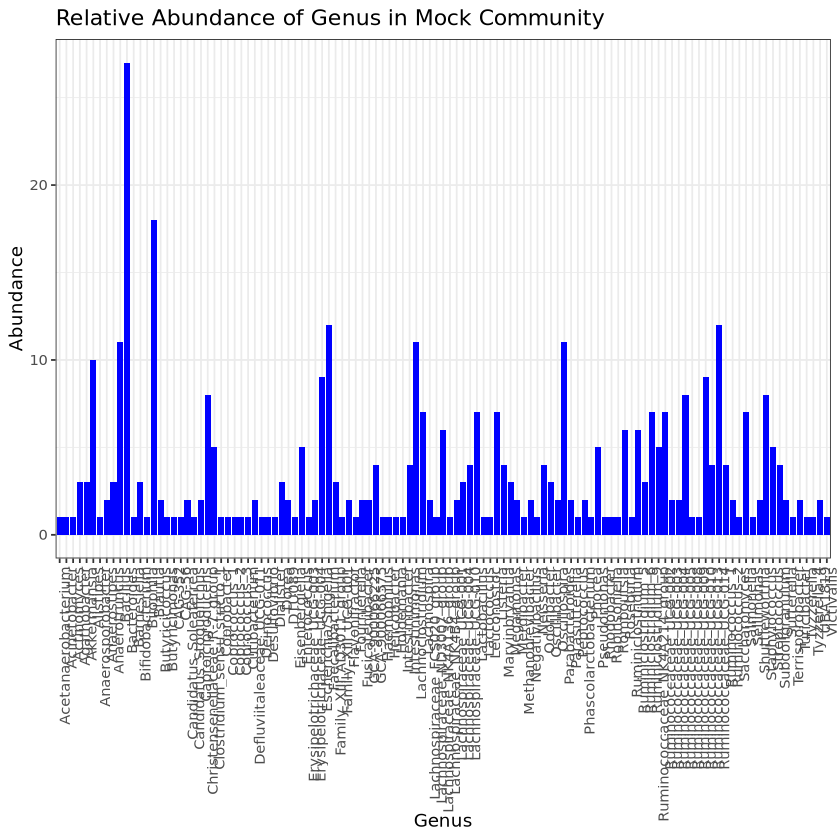

In [46]:
genus_taxa <- taxa_with_species[, "Genus"]
genus_df <- as.data.frame(table(genus_taxa))
colnames(genus_df) <- c("Genus", "Abundance")

head(genus_df)

library(ggplot2)
ggplot(genus_df, aes(x = Genus, y = Abundance)) +
  geom_bar(stat = "identity", fill = "blue") +
  theme(axis.text.x = element_text(angle = 90, hjust = 1)) +
  labs(title = "Relative Abundance of Genus in Mock Community", x = "Genus", y = "Abundance")

In [85]:
asv_abundance <- colSums(seqtab.nochim)

sorted_asvs <- sort(asv_abundance, decreasing = TRUE)

head(sorted_asvs, 10)


GGAATATTGCACAATGGGCGAAAGCCTGATGCAGCAACGCCGCGTGAGCGATGAAGGCCTTCGGGTCGTAAAGCTCTGTCCTCAAGGAAGATAATGACGGTACTTGAGGAGGAAGCCCCGGCTAACTACGTGCCAGCAGCCGCGGTAATACGTAGGGGGCTAGCGTTATCCGGAATTACTGGGCGTAAAGGGTGCGTAGGTGGTTTCTTAAGTCAGAGGTGAAAGGCTACGGCTCAACCGTAGTAAGCCTTTGAAACTGGGAAACTTGAGTGCAGGAGAGGAGAGTGGAATTCCTAGTGTAGCGGTGAAATGCGTAGATATTAGGAGGAACACCAGTTGCGAAGGCGGCTCTCTGGACTGTAACTGACACTGAGGCACGAAAGCGTGGGGAGCAAACAGG 
                                                                                                                                                                                                                                                                                                                                                                                                                                   1961495 
GGAATCTTCGGCAATGGGCGAAAGCCTGACCGAGCAACGCCGCGTGAATGATGAAGGCCTTCGGGTTGTAAAATTCTGTTATAAGGGAAGAACGACTTTAGTAGGAAATGGCTAAAGTGTGACGGTACCTTATGAGAAAGCCACGGCTAACTACGTGCCAGCAGCCGCGGTAATACGTAGGTGGCAAGCGTTATCCGGAATTATTGGGCGTAAAGAGCGCGCAGGTGGTTGATTAAGTCTGATGTGAAAGCCCACGGCTTAACCGTGGAGGGTCATTGGAAACTGGTCGACTTGAGTGCAGAAGAGGGAAGTGGAATTCCATGTGTAGCGGTGAAATGCGTAGAGATATGGAGGAACACCAGTGGCGAAGGCGGCTTCCTGGTCTGTAACTGACACTGAGGCGCGAAAGCGTGGGGAGCAAACAGG 
                                                                                                                                                                                                                                                                                                                                                                                                                                   1588255 
                         GGAATATTGCACAATGGGGGAAACCCTGATGCAGCAACGCCGCGTGAGTGATGACGGCCTTCGGGTTGTAAAGCTCTGTCTTCAGGGACGATAATGACGGTACCTGAGGAGGAAGCCACGGCTAACTACGTGCCAGCAGCCGCGGTAATACGTAGGTGGCGAGCGTTGTCCGGATTTACTGGGCGTAAAGGGAGCGTAGGCGGACTTTTAAGTGAGATGTGAAATACCCGGGCTCAACTTGGGTGCTGCATTTCAAACTGGAAGTCTAGAGTGCAGGAGAGGAGAATGGAATTCCTAGTGTAGCGGTGAAATGCGTAGAGATTAGGAAGAACACCAGTGGCGAAGGCGATTCTCTGGACTGTAACTGACGCTGAGGCTCGAAAGCGTGGGGAGCAAACAGG 
                                                                                                                                                                                                                                                                                                                                                                                                                                   1490106 
        GGAATATTGCACAATGGGCGCAAGCCTGATGCAGCGACGCCGCGTGCGGGATGGAGGCCTTCGGGTTGTAAACCGCTTTTGTTCAAGGGCAAGGCACGGTTTCGGCCGTGTTGAGTGGATTGTTCGAATAAGCACCGGCTAACTACGTGCCAGCAGCCGCGGTAATACGTAGGGTGCAAGCGTTATCCGGATTTATTGGGCGTAAAGGGCTCGTAGGCGGTTCGTCGCGTCCGGTGTGAAAGTCCATCGCTTAACGGTGGATCCGCGCCGGGTACGGGCGGGCTTGAGTGCGGTAGGGGAGACTGGAATTCCCGGTGTAACGGTGGAATGTGTAGATATCGGGAAGAACACCAATGGCGAAGGCAGGTCTCTGGGCCGTTACTGACGCTGAGGAGCGAAAGCGTGGGGAGCGAACAGG 
                                                                                                                                                                                                                                                                                                                                                                                                                                   1429177 
                          GGAATATTGCACAATGGGCGAAAGCCTGATGCAGCAACGCCGCGTGAGCGATGAAGGCCTTCGGGTCGTAAAGCTCTGTCCTCAAGGAAGATAATGACGGTACTTGAGGAGGAAGCCCCGGCTAACTACGTGCCAGCAGCCGCGGTAATACGTAGGGGGCTAGCGTTATCCGGAATTACTGGGCGTAAAGGGTGCGTAGGCGGTCTTTCAAGCCAGAAGTGAAAGGCTACGGCTCAACCGTAGTAAGCTTTTGGAACTGTAAGACTTGAGTGCAGGAGAGGAGAGTGGAATTCCTAGTGTAGCGGTGAAATGCGTAGATATTAGGAGGAACACCAGTAGCGAAGGCGGCTCTCTGGACTGTAACTGACGCTGAGGCACGAAAGCGTGGGGAGCAAACAGG 
                                                                                                                                                                              

In [87]:
library(phyloseq)

In [93]:
mock_rows <- grep("Mock", rownames(seqtab.nochim), value = TRUE)

if (length(mock_rows) > 0) {
    # Assume you want to work with the first match, or modify as needed
    unqs.mock <- seqtab.nochim[mock_rows[1], ]
    unqs.mock <- sort(unqs.mock[unqs.mock > 0], decreasing = TRUE)
    cat("DADA2 inferred", length(unqs.mock), "sample sequences present in the Mock community.\n")
} else {
    cat("No rows containing 'Mock' found in seqtab.nochim.\n")
}

DADA2 inferred 140 sample sequences present in the Mock community.


In [95]:
mock.ref <- getSequences(file.path(path, "Mock_all_asvs_clean.fasta"))

# Compare each ASV sequence to the reference sequences
match.ref <- sapply(names(unqs.mock), function(x) any(grepl(x, mock.ref, fixed = TRUE)))

# Summarize the number of matches
cat("Of those,", sum(match.ref), "were exact matches to the expected reference sequences.\n")

Of those, 20 were exact matches to the expected reference sequences.


In [100]:
mock_rows <- grep("mock", rownames(seqtab.nochim), value = TRUE, ignore.case = TRUE)
print(mock_rows)

[1] "SynMock1" "SynMock2"


In [13]:
library(phyloseq); packageVersion("phyloseq")

[1] ‘1.50.0’

In [14]:
library(Biostrings); packageVersion("Biostrings")

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, saveRDS, setdiff,
    table, tapply, union, unique, unsplit, which.max, which.min


Loading required package: S4Vectors

Loading required package: stats4


Attaching package: ‘S4Vectors’


The following object is masked from ‘package:utils’:

    findMatches


The following objects are masked from ‘package:base’:

    expand.grid, I, unname


Loading required package: IRanges


Attaching package: ‘IRanges’


The following object is masked from ‘package:phyl

[1] ‘2.74.0’

In [15]:
library(ggplot2); packageVersion("ggplot2")

[1] ‘3.5.2’

In [16]:
theme_set(theme_bw())

In [17]:
samples.out <- rownames(seqtab.nochim)
subject <- sapply(strsplit(samples.out, "D"), `[`, 1)
gender <- substr(subject,1,1)
subject <- substr(subject,2,999)
day <- as.integer(sapply(strsplit(samples.out, "D"), `[`, 2))
samdf <- data.frame(Subject=subject, Gender=gender, Day=day)
samdf$When <- "Early"
samdf$When[samdf$Day>100] <- "Late"
rownames(samdf) <- samples.out

ERROR: Error in h(simpleError(msg, call)): error in evaluating the argument 'x' in selecting a method for function 'rownames': object 'seqtab.nochim' not found


In [ ]:
ps <- phyloseq(otu_table(seqtab.nochim, taxa_are_rows = FALSE),
               sample_data(metadata)), 
               tax_table(taxa))
ps <- prune_samples(sample_names(ps) != "Mock", ps)

In [ ]:
dna <- Biostrings::DNAStringSet(taxa_names(ps))
names(dna) <- taxa_names(ps)
ps <- merge_phyloseq(ps, dna)
taxa_names(ps) <- paste0("ASV", seq(ntaxa(ps)))
ps

In [ ]:
plot_richness(ps, x="Day", measures=c("Shannon", "Simpson"), color="When")

In [ ]:
ps.prop <- transform_sample_counts(ps, function(otu) otu/sum(otu))
ord.nmds.bray <- ordinate(ps.prop, method="NMDS", distance="bray")

In [ ]:
plot_ordination(ps.prop, ord.nmds.bray, color="When", title="Bray NMDS")

In [ ]:
top20 <- names(sort(taxa_sums(ps), decreasing=TRUE))[1:20]
ps.top20 <- transform_sample_counts(ps, function(OTU) OTU/sum(OTU))
ps.top20 <- prune_taxa(top20, ps.top20)
plot_bar(ps.top20, x="Day", fill="Family") + facet_wrap(~When, scales="free_x")

In [ ]:
##Decontam and Sourcetracker

In [ ]:
# Contaminant Identification with *Decontam*

R package ‘decontam’ version 1.26.0

### 1. Load Required Libraries

```{r message=FALSE}
library(decontam)
library(dplyr)
library(ggplot2)
library(phyloseq)
library(ggpubr)
library(pairwiseAdonis)
library(patchwork)
library(microbiome)

In [ ]:
### 2. Define Sample Types and Paths
TYPE <- c("Cisternal milk", "Teat canal", "Teat apex", "Stripped milk")
path.rds
path.figures

In [ ]:
### 3. Load Phyloseq Object

```{r}
ps <- readRDS(file.path(path.rds, "phyloseq.rds"))
ps

In [ ]:
### 4. Prepare Metadata

```{r}
sample_data(ps)
sample_data(ps)$SampleOrControl[sample_data(ps)$SampleOrControl == "Neither"] <- "Sample"
sample_data(ps)$CopyNumber <- as.numeric(sample_data(ps)$CopyNumber)

In [ ]:
### 5. Frequency-Based Contaminant Detection
# Prepare data for 'frequency' method
exclude_controls <- c("Water", "Extraction")


ps.samples <- subset_samples(ps, !Matrix %in% exclude_controls) # remove control samples
ps.samples <- prune_taxa(taxa_sums(ps.samples) > 0, ps.samples) # remove taxa with no counts
ps.samples

In [ ]:
# Run frequency method
contamdf.freq <- isContaminant(ps.samples, method="frequency", conc="CopyNumber", threshold = 0.5) # DNA contrentration is stored in the CopyNumber column
table(contamdf.freq$contaminant)

# Display the number of sequence features classified as contaminants
# FALSE: Number of sequence features not classified as contaminants 
# TRUE:  Number of sequence features classified as contaminants 
# Note: The majority of features identified as contaminants are typically low-prevalence ASVs.

contam_feature_indices <- which(contamdf.freq$contaminant == TRUE)
head(contam_feature_indices)
# Vector of sequence feature indices in otu table that are contaminants
# Note: Some of the most abundant sequence features were classified as contaminants

In [ ]:
# Select contaminants from otu table
contam_seq_freq <- rownames(contamdf.freq[contamdf.freq$contaminant == "TRUE",])

contamdf.freqMod <- contamdf.freq %>%
  filter(prev > 1) %>%
  mutate(Prevalence = ifelse(prev == 2, "2",
                             ifelse(prev > 2 & prev <= 5, "3-5",
                                    ifelse(prev >= 6 & prev <= 10, "6-10", "11+")))  )

contamdf.freqMod$Prevalence <- factor(contamdf.freqMod$Prevalence, levels = c("2", "3-5", "6-10", "11+"))

In [ ]:
# Plot score statistics output from 'frequency' method

# Set up:
theme_set(theme_bw())
          # Part of the Area Green Tableau color palette (Version 9.x)
          # Similar to Davis et al., (2018)
scaleColorFillManualFrequency <-
  scale_fill_manual(
    values = 
      c(
        "2"    = "#dbe8b4",
        "3-5"  = "#9ad26d",
        "6-10" = "#6cae59",
        "11+"  = "#4a8c1c"
      )
  )

# Plot score statistics output 
freqScorePlot <- ggplot(contamdf.freqMod, aes(x = p, fill = Prevalence)) +
  geom_histogram(bins = 30)                                      +
  scaleColorFillManualFrequency                                  + 
  ggtitle("Frequency Method")                                    +
  xlab("Score Statistic")                                        + 
  ylab("Frequency")                                              +
  theme(
    plot.title = element_text(hjust = 0.5),
    legend.position = "none")

freqScorePlot

In [ ]:
### 6. Prevalence-Based Contaminant Detection
# Prepare data for 'prevalence' method
sample_data(ps)$is.neg <- sample_data(ps)$SampleOrControl == "Control"

# Run 'prevalence' method
# Information about whether the sample ir a control or true sample is stored in 'is.neg' variable
contamdf.prev <- isContaminant(ps, method="prevalence", neg="is.neg", threshold=0.5)
table(contamdf.prev$contaminant)
# Display the number of sequence features classified as contaminants
# FALSE: Number of sequence features not classified as contaminants 
# TRUE:  Number of sequence features classified as contaminants 


contam_feature_indices_prev <- which(contamdf.prev$contaminant == TRUE)
head(contam_feature_indices_prev)
# Vector of sequence feature indices in otu table that are contaminants
# Note: Some of the most abundant sequence features were classified as contaminants


In [ ]:
# Make phyloseq object of presence-absence in negative controls and true samples
ps.pa <- transform_sample_counts(ps, function(abund) 1*(abund>0))
ps.pa.neg <- prune_samples(sample_data(ps.pa)$SampleOrControl == "Control", ps.pa)
ps.pa.pos <- prune_samples(sample_data(ps.pa)$SampleOrControl == "Sample", ps.pa)

# Make data.frame of prevalence in positive and negative samples
df.pa <- data.frame(pa.pos=taxa_sums(ps.pa.pos), pa.neg=taxa_sums(ps.pa.neg),
                    contaminant=contamdf.prev$contaminant)
pa.plot <- ggplot(data=df.pa, aes(x=pa.neg, y=pa.pos, color=contaminant)) + 
  geom_point() +
  theme(legend.position = "bottom")+
  xlab("Prevalence (Negative Controls)") + 
  ylab("Prevalence (True Samples)")
pa.plot

In [ ]:
### 7. Prevalence-Based Detection: Water Controls
#Prepare data for 'prevalence' method, H2O is control
ps.no.extraction <- subset_samples(ps, !Type %in% "Extraction") # remove extraction samples
ps.no.extraction <- prune_taxa(taxa_sums(ps.no.extraction) > 0, ps.no.extraction) # remove taxa with no counts
ps.no.extraction
sample_data(ps.no.extraction)$is.neg <- sample_data(ps.no.extraction)$SampleOrControl == "Control"

In [ ]:
# Run 'prevalence' method
# Information about whether the sample ir a control or true sample is stored in 'is.neg' variable

contamdf.prev.water <- isContaminant(ps.no.extraction, method="prevalence", neg="is.neg", threshold=0.5)
table(contamdf.prev.water$contaminant)
# FALSE: Number of sequence features not classified as contaminants 
# TRUE:  Number of sequence features classified as contaminants 


contam_feature_indices_prev_water <- which(contamdf.prev.water$contaminant == TRUE)
head(contam_feature_indices_prev_water) 
# Vector of sequece feature indices in otu table that are contaminants
# Note: Some of the most abundant sequence features were classified as contaminants


In [ ]:

# Plot Water Score 

contamdf.prev.waterMod <- contamdf.prev.water %>%
  filter(prev > 1) %>%
  mutate(Prevalence = ifelse(prev == 2, "2",
                             ifelse(prev > 2 & prev <= 5, "3-5",
                                    ifelse(prev >= 6 & prev <= 10, "6-10", "11+")))
  )
contamdf.prev.waterMod$Prevalence <- factor(contamdf.prev.waterMod$Prevalence, levels = c("2", "3-5", "6-10", "11+"))


prev.waterScorePlot <- ggplot(contamdf.prev.waterMod, aes(x = p, fill = Prevalence)) +
  geom_histogram(bins = 30)                                      +
  scaleColorFillManualFrequency                                  + 
  ggtitle("Prevalence Method (library)")                         +
  xlab("Score Statistic")                                        + 
  ylab("Frequency")                                              +
  theme(
    plot.title = element_text(hjust = 0.5),
    legend.position = "none",
    axis.title.y = element_blank()
  )
prev.waterScorePlot 

# Select seq name of contaminants identified by prevalence method using water as control
contam_seq_prev_water <- rownames(contamdf.prev.water[contamdf.prev.water$contaminant == "TRUE",])

In [ ]:
### 8. Prevalence-Based Detection: Extraction Controls

```{r}
# Prepare data for 'prevalence' method, Extraction is control
ps.no.library <- subset_samples(ps, !Type %in% "Library") # remove library samples
ps.no.library <- prune_taxa(taxa_sums(ps.no.library) > 0, ps.no.library) # remove taxa with no counts
ps.no.library


sample_data(ps.no.library)$is.neg <- sample_data(ps.no.library)$SampleOrControl == "Control"
```

```{r}
# Run 'prevalence' method
# Information about whether the sample ir a control or true sample is stored in 'is.neg' variable

contamdf.prev.extraction <- isContaminant(ps.no.library, method="prevalence", neg="is.neg", threshold=0.5)
table(contamdf.prev.extraction$contaminant)
# Show number of sequence features classified as contaminants
# FALSE: No. of sequence features that were not classified as contaminants
# TRUE:  No. of sequence features that were classified as contaminants


contam_feature_indices_prev_extraction <- which(contamdf.prev.extraction$contaminant == TRUE)
head(contam_feature_indices_prev_extraction)
# Vector of sequece feature indices in otu table that are contaminants
# Note: Some of the most abundant sequence features were classified as contaminants
```

```{r}
#Plot Extraction Score 
contamdf.prev.extractionMod <- contamdf.prev.extraction %>%
  filter(prev > 1) %>%
  mutate(Prevalence = ifelse(prev == 2, "2",
                             ifelse(prev > 2 & prev <= 5, "3-5",
                                    ifelse(prev >= 6 & prev <= 10, "6-10", "11+")))
  )
contamdf.prev.extractionMod$Prevalence <- factor(contamdf.prev.extractionMod$Prevalence, levels = c("2", "3-5", "6-10", "11+"))


prev.extractionScorePlot <- ggplot(contamdf.prev.extractionMod, aes(x = p, fill = Prevalence)) +
  geom_histogram(bins = 30)                                      +
  scaleColorFillManualFrequency                                  + 
  ggtitle("Prevalence Method (extraction)")                      +
  xlab("Score Statistic")                                        + 
  ylab("Frequency")                                              +
  theme(
    plot.title = element_text(hjust = 0.5),
    legend.position = "right",
    axis.title.y = element_blank()
  )
prev.extractionScorePlot

```

```{r}
#select seq names of contaminants identified by prevalence method using extraction as control
contam_seq_prev_extraction <- rownames(contamdf.prev.extraction[contamdf.prev.extraction$contaminant == "TRUE",])

In [ ]:
### 9. Phyloseq object after Decontam

```{r}
# Create noncontam ps project
# Select unique seq names of contaminants identified by both frequency and prevalence methods separately 
contam_seq <- c(contam_seq_freq, contam_seq_prev_extraction, contam_seq_prev_water)
contam_seq <- unique(contam_seq)

# Create ps project after removing contaminants
allTaxa = taxa_names(ps)
Taxa.decontam <- allTaxa[!(allTaxa %in% contam_seq)]
ps.decontam <- prune_taxa(Taxa.decontam, ps)
saveRDS(ps.decontam, file.path(path.rds, "ps.decontam.rds"))

ps.contam <- prune_taxa(contam_seq, ps)
saveRDS(ps.contam, file.path(path.rds, "ps.contam.rds"))

In [ ]:
#### 9.1 Plot 16S Gene Copy vs Abundance of Contaminants

```{r}
SAMPLE_TYPES <- c(
  "Teat apex",
  "Teat canal",
  "Stripped milk",
  "Cisternal milk",
  "Air",
  "Blank",
  "Extraction",
  "Library"
)


my_palette<- c(
  "Teat apex" = "#1f77b4",
  "Teat canal" = "#ff7f0e",
  "Stripped milk" = "#2ca02c",
  "Cisternal milk" = "#d62728",
  "Library" = "#7f7f7f",
  "Extraction" = "#bcbd22",
  "Air" = "#539caf",
  "Blank" = "#ebc850"
)

metadata <- sample_data(ps.contam) %>% data.frame
counts <- sample_sums(ps.contam) %>% data.frame
colnames(counts) <- "counts"
counts$X.SampleID <- rownames(counts)
metadata <- left_join(metadata, counts, by = "X.SampleID")
metadata <- metadata[metadata$Type != "Library",]
metadata$Type <- factor(metadata$Type, levels = SAMPLE_TYPES)

p.contam.counts <- ggplot(data=metadata, aes(x=log(CopyNumber), y=counts/1000))+
  geom_point(aes(color = Type), size = 2)+
  geom_smooth(aes(group =1), method = "lm", se = TRUE) +
  stat_cor(label.x = 7, label.y = 110) +
  stat_regline_equation(label.x = 7, label.y = 100)+
  xlab("Log (16S gene copy number)")+
  ylab("Counts / 1000")+
  scale_color_manual(values = my_palette)
p.contam.counts # 16S gene copy number vs abundance of contaminants

In [ ]:
#### 9.2 Plot the Abundance of Contaminants

```{r}
detection <- sum(taxa_sums(ps.contam))/70*0.05
pseq.contam <- aggregate_rare(ps.contam, level="Genus", detection = detection, prevalence = 0.2)

melt.contam <- psmelt(pseq.contam)
melt.contam$Type <- factor(melt.contam$Type, levels = SAMPLE_TYPES)

p.contam <- ggplot(melt.contam, aes(x=X.SampleID, y=Abundance, fill=Genus)) +
  geom_bar(stat="identity") +
  facet_wrap(~Type, nrow = 1, scales = "free_x") +
  theme_bw()+
  theme(
    axis.title.x = element_blank(),
    axis.text.x = element_blank(),
    axis.ticks = element_blank(),
    legend.key.size = unit(10, "pt"),
    panel.grid.major.x = element_blank() )+
  scale_fill_brewer("Genus", palette = "Paired")
p.contam # abundance of contaminants

In [ ]:
#### 9.2 NMDS of Contaminants

```{r}
ps.contam.sample <- subset_samples(ps.contam, Type %in% c("Cisternal milk", "Stripped milk", "Teat apex", "Teat canal"))
ps.contam.sample <- prune_taxa(taxa_sums(ps.contam)>0, ps.contam.sample)

type_colors <- c(
  "Teat apex" = "#1f77b4",
  "Teat canal" = "#ff7f0e",
  "Stripped milk" = "#2ca02c",
  "Cisternal milk" = "#d62728"
)

ord.bray.nmds.contam <- ordinate(ps.contam.sample, "NMDS", "bray", k=3, trymax = 1000)
ord.pnmds.contam <- plot_ordination(ps.contam.sample, ord.bray.nmds.contam, color = "Type") +
  geom_point(size = 3.0) +   
  theme_bw() +  
  scale_color_manual(values = type_colors) +
  theme(axis.text = element_text(size = 12), 
        axis.title = element_text(size = 14),
        plot.title = element_text(hjust=0.5))+
  annotate("text", x = -1.5, y = -1.5, label = "Stress = 0.124\nPERMANOVA P = 0.001",
           hjust = 0)
print(ord.pnmds.contam) # NMDS of contaminants

In [ ]:
#### 9.3 PERMANOVA

```{r}
bray.dist.contam<-vegdist(otu_table(ps.contam.sample), method='bray') 
bray.dist.contam

metadata.sample <- sample_data(ps.contam.sample) %>% data.frame()

beta_div.contam <-pairwise.adonis2(bray.dist.contam ~ Type, data=metadata.sample, permutations=999)
beta_div.contam

In [ ]:
#### 9.4 Combine the Plots

```{r}
fig.decontam <- (freqScorePlot + prev.waterScorePlot + prev.extractionScorePlot) / (pa.plot + p.contam.counts + ord.pnmds.contam) / (p.contam ) + 
  plot_annotation(tag_levels = c("A"))

ggsave(file.path (path.fig, "Figure 3. Decontam_Contaminants.png"), fig.decontam, width = 16, height = 12, dpi=600)

In [ ]:
# Load your ASV table (make sure it includes all samples)
seqtab <- readRDS("output/seqtab.rds")  # Adjust path if needed
metadata <- read.csv("sample_metadata.csv", row.names = 1)
sample_names <- rownames(seqtab)
metadata <- metadata[rownames(seqtab.nochim), ] 

is.neg <- grepl("control-te-|control-extraction-N-CONTROL|PBS", sample_names)

table(is.neg)

contam_results <- isContaminant(t(seqtab), neg = is.neg, method = "prevalence")

seqtab_decontaminated <- seqtab[, !contam_results$contaminant]

saveRDS(seqtab_decontaminated, "output/seqtab_decontaminated.rds")


In [ ]:
# Install if needed
if (!requireNamespace("SourceTracker", quietly = TRUE)) {
  devtools::install_github("biota/sourcetracker")
}
library(SourceTracker)

# Load your ASV table (samples as rows, ASVs as columns)
asv_table <- readRDS("output/seqtab_decontaminated.rds")

# Create metadata with sample IDs
metadata <- data.frame(SampleID = rownames(asv_table))

# Label source and sink samples
metadata$SourceSink <- ifelse(grepl("mock|control|PBS", metadata$SampleID, ignore.case = TRUE), "Source", "Sink")

# Transpose: SourceTracker expects ASVs as rows, samples as columns
asv_table_t <- t(asv_table)

# Match metadata order with transposed table
metadata <- metadata[match(colnames(asv_table_t), metadata$SampleID), ]

# Separate sources and sinks
sources <- asv_table_t[, metadata$SourceSink == "Source", drop = FALSE]
sinks   <- asv_table_t[, metadata$SourceSink == "Sink", drop = FALSE]

# Create environment vector for source samples
envs <- rep("environmental_source", ncol(sources))  # Can adjust if you want specific source labels

# Fit SourceTracker model
st <- sourcetracker(taxa_count_matrix = sources, envs = envs)

# Predict source proportions for sink samples
pred <- predict(st, newdata = sinks)

# Preview results
head(pred)

# Save output
write.csv(pred, "output/sourcetracker_predictions.csv", quote = FALSE)


In [ ]:
# Label specific source types for later identification (important for SourceTracker)
metadata$SourceType <- ifelse(grepl("control-extraction", metadata$SampleID, ignore.case = TRUE), "Extraction Control",
                               ifelse(grepl("control-te", metadata$SampleID, ignore.case = TRUE), "Reagent Control",
                                      ifelse(grepl("PBS", metadata$SampleID, ignore.case = TRUE), "Environmental Control", "Mock Community")))

# Transpose: SourceTracker expects ASVs as rows, samples as columns
asv_table_t <- t(asv_table)

# Match metadata order with transposed table
metadata <- metadata[match(colnames(asv_table_t), metadata$SampleID), ]

# Separate sources and sinks
sources <- asv_table_t[, metadata$SourceSink == "Source", drop = FALSE]
sinks   <- asv_table_t[, metadata$SourceSink == "Sink", drop = FALSE]

# Create environment vector for source samples with their specific labels
envs <- metadata$SourceType[metadata$SourceSink == "Source"]

# Fit SourceTracker model
st <- sourcetracker(taxa_count_matrix = sources, envs = envs)

# Predict source proportions for sink samples
pred <- predict(st, newdata = sinks)

# Preview results
head(pred)

# Save output
write.csv(pred, "output/sourcetracker_predictions.csv", quote = FALSE)

In [42]:
# Identify control samples
extraction_controls <- metadata %>% filter(SourceType == "Extraction Control") %>% pull(SampleID)

# Subset the ASV table for extraction controls
extraction_control_asvs <- seqtab.nochim[extraction_controls, , drop = FALSE]

# Convert to long format
extraction_control_long <- as.data.frame(extraction_control_asvs) %>%
  rownames_to_column("Sample") %>%
  pivot_longer(-Sample, names_to = "ASV", values_to = "Count") %>%
  filter(Count > 0)

# Optionally add taxonomic information for context
extraction_control_long <- extraction_control_long %>%
  left_join(as.data.frame(taxa_filtered)[, c("Phylum", "Genus"), drop = FALSE] %>%
              rownames_to_column("ASV"), by = "ASV")

# View ASVs in extraction control
head(extraction_control_long)


ERROR: Error in UseMethod("filter"): no applicable method for 'filter' applied to an object of class "c('standardGeneric', 'genericFunction', 'function', 'OptionalFunction', 'PossibleMethod', 'functionOrNULL', 'expression_OR_function', 'optionalMethod')"
